# Baselines-only MRI FFT low-pass square posterior sampling with saved prior

This notebook runs the spatial identity/projection observation model for the baseline methods only. It loads the trained unconditional prior checkpoint from the prior-training output directory by default.


### Compatibility/speed note

This version keeps the CT angle handling fixed, but restores the faster DPS defaults from the earlier notebook (`DPS_CHUNK_SIZE=16`, `CT_ANGLE_CHUNK=20`) and removes two avoidable extra computations in DPS: the reward is not recomputed after the loss, and the prior proposal reuses the score already computed for Tweedie guidance. Lower `DPS_CHUNK_SIZE` or `CT_ANGLE_CHUNK` only if GPU memory becomes tight.

## 0. Environment notes

On Tuolumne, use a PyTorch ROCm kernel/module. Do not run package installs from inside the notebook unless your allocation explicitly allows it.

Typical required Python packages are `torch`, `numpy`, `h5py`, `matplotlib`, and optionally `tqdm`.


In [1]:
# No pip installs here. Use the Tuolumne/ROCm PyTorch environment or your own prebuilt conda/venv.
# Required packages: torch, numpy, h5py, matplotlib, tqdm(optional).


## 1. Imports and Tuolumne/AMD configuration

Most settings can be overridden without editing the notebook by setting environment variables before launching Jupyter or running the `.py` export, e.g.

```bash
export FASTMRI_TRAIN_ROOT=/path/to/knee_singlecoil_train
export FASTMRI_VAL_ROOT=/path/to/knee_singlecoil_val
export OUTPUT_DIR=$PWD/dps_dolce_outputs
export IMG_SIZE=64
export NUM_TRAIN_STEPS=0                 # load pretrained unconditional prior by default
export DPS_NUM_SAMPLES=3000
export DOLCE_NUM_SAMPLES=3000
```


### Correction: limited-angle coverage vs. ray-mask fraction

For `CT_MASK_TYPE=limited_angle`, the mask is angular: it keeps all detector bins for a contiguous angular sector.  Therefore `CT_ANGULAR_COVERAGE_DEGREES=120` means 120 degrees of the full `CT_ANGLE_MAX_DEGREES` range, and `CT_MASK_FRACTION` is not used.  For a full 180-degree scan, this gives an observed fraction of 120/180 = 2/3.

For `CT_MASK_TYPE=vd_poisson` or `random`, `CT_MASK_FRACTION=0.8` means keeping 80% of the ray-angle entries in the full sinogram grid.


In [2]:
# Optional: set environment variables here before running the configuration cell.
# Usually it is cleaner to export these in the batch script instead.
#
# import os
# os.environ["FASTMRI_TRAIN_ROOT"] = "/path/to/knee_singlecoil_train"
# os.environ["FASTMRI_VAL_ROOT"] = "/path/to/knee_singlecoil_val"
# os.environ["OUTPUT_DIR"] = str(pathlib.Path.cwd() / "dps_dolce_outputs")
#
# DOLCE-style Gaussian Radon default:
# os.environ["OBS_MODE"] = "ct_gaussian"
# os.environ["LIKELIHOOD_TYPE"] = "gaussian"
# os.environ["DELTA_OBS"] = "0.1"
# os.environ["CT_MASK_TYPE"] = "limited_angle"
# os.environ["CT_ANGULAR_COVERAGE_DEGREES"] = "120"
#
# LoDoPaB-style Poisson CT alternative:
# os.environ["OBS_MODE"] = "ct_poisson"
# os.environ["LIKELIHOOD_TYPE"] = "poisson_direct"
# os.environ["CT_MASK_TYPE"] = "vd_poisson"
# os.environ["CT_MASK_FRACTION"] = "0.8"


In [3]:
import os
import gc
import math
import time
import pathlib
import random
from typing import List, Tuple, Optional

# Set matplotlib backend before importing pyplot. In batch jobs with no display, use Agg.
import matplotlib
if os.environ.get("DISPLAY", "") == "" and os.environ.get("MPLBACKEND", "") == "":
    matplotlib.use("Agg")
import numpy as np
import matplotlib.pyplot as plt

try:
    import h5py
except Exception as e:
    h5py = None
    print("WARNING: h5py is not available; fastMRI HDF5 loading will fail unless synthetic fallback is enabled.")
    print("h5py import error:", repr(e))

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

# -----------------------------
# Environment helpers
# -----------------------------
def env_bool(name: str, default: bool) -> bool:
    val = os.environ.get(name, None)
    if val is None:
        return bool(default)
    return str(val).strip().lower() in {"1", "true", "yes", "y", "on"}


def env_int(name: str, default: int) -> int:
    return int(os.environ.get(name, str(default)))


def env_float(name: str, default: float) -> float:
    return float(os.environ.get(name, str(default)))


def env_str(name: str, default: str) -> str:
    return os.environ.get(name, default)


def env_float_list(name: str, default):
    val = os.environ.get(name, None)
    if val is None or str(val).strip() == "":
        return list(default)
    return [float(x) for x in str(val).replace(";", ",").split(",") if x.strip()]


def env_int_list(name: str, default):
    val = os.environ.get(name, None)
    if val is None or str(val).strip() == "":
        return list(default)
    return [int(x) for x in str(val).replace(";", ",").split(",") if x.strip()]

# -----------------------------
# Tuolumne / ROCm execution hygiene
# -----------------------------
SEED = env_int("SEED", 2026)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.set_default_dtype(torch.float32)
NUM_CPU_THREADS = env_int("NUM_CPU_THREADS", min(8, os.cpu_count() or 1))
try:
    torch.set_num_threads(NUM_CPU_THREADS)
except Exception:
    pass

# PyTorch ROCm intentionally exposes AMD GPUs through the torch.cuda API.
DEVICE = torch.device(env_str("TORCH_DEVICE", "cuda" if torch.cuda.is_available() else "cpu"))
PIN_MEMORY = env_bool("PIN_MEMORY", False)  # False is safer on ROCm/shared HPC nodes.
DATALOADER_NUM_WORKERS = env_int("DATALOADER_NUM_WORKERS", 0)
SHOW_PLOTS = env_bool("SHOW_PLOTS", True)
SAVE_FIGURES = env_bool("SAVE_FIGURES", True)
OUTPUT_DIR = pathlib.Path(env_str("OUTPUT_DIR", "./singlecoil_mri_tuolumne_outputs")).expanduser()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

try:
    # On ROCm this may still be routed through MIOpen/cudnn compatibility layers.
    torch.backends.cudnn.benchmark = env_bool("CUDNN_BENCHMARK", True)
except Exception:
    pass

print("Torch version:", torch.__version__)
print("Torch HIP/ROCm version:", getattr(torch.version, "hip", None))
print("CUDA API available (ROCm uses this name too):", torch.cuda.is_available())
print("Device:", DEVICE)
print("CPU threads:", NUM_CPU_THREADS)
print("ROCR_VISIBLE_DEVICES:", os.environ.get("ROCR_VISIBLE_DEVICES"))
print("HIP_VISIBLE_DEVICES:", os.environ.get("HIP_VISIBLE_DEVICES"))
if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())
    print("GPU 0:", torch.cuda.get_device_name(0))
    try:
        props = torch.cuda.get_device_properties(0)
        print("GPU 0 memory GB:", round(props.total_memory / 1024**3, 2))
    except Exception:
        pass


def clear_device_cache():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def sync_device():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

# -----------------------------
# Dataset configuration
# -----------------------------
DATA_MODE = env_str("DATA_MODE", "fastmri_h5")   # "fastmri_h5" or "synthetic"

FASTMRI_TRAIN_ROOT = env_str("FASTMRI_TRAIN_ROOT", "./knee_singlecoil_train")
FASTMRI_VAL_ROOT = env_str("FASTMRI_VAL_ROOT", "./knee_singlecoil_val")

ALLOW_SYNTHETIC_FALLBACK = env_bool("ALLOW_SYNTHETIC_FALLBACK", True)
MAX_FASTMRI_FILES = env_int("MAX_FASTMRI_FILES", 12)
MAX_SLICES_PER_FILE = env_int("MAX_SLICES_PER_FILE", 24)
IMG_SIZE = env_int("IMG_SIZE", 64)

# -----------------------------
# Score training configuration
# -----------------------------
BATCH_SIZE = env_int("BATCH_SIZE", 4)  # smaller default prevents CT/RLS memory spikes
NUM_TRAIN_STEPS = env_int("NUM_TRAIN_STEPS", 0)  # load pretrained prior by default; set >0 only to fine-tune
LR = env_float("LR", 2e-4)
BASE_CHANNELS = env_int("BASE_CHANNELS", 32)
TIME_EMB_DIM = env_int("TIME_EMB_DIM", 128)
DSM_T_MIN = env_float("DSM_T_MIN", 1e-3)
DSM_T_MAX = env_float("DSM_T_MAX", 0.98)
DSM_WEIGHT_BY_SIGMA2 = env_bool("DSM_WEIGHT_BY_SIGMA2", True)
# Pretrained prior location from the prior-training/tail-stats run.
# Environment override precedence:
#   CHECKPOINT_PATH > SAVED_CHECKPOINT_PATH > PRIOR_CHECKPOINT_PATH > auto-discovered latest file in PRIOR_OUTPUT_DIR > fixed default.
DEFAULT_PRIOR_OUTPUT_DIR = pathlib.Path(env_str("DEFAULT_PRIOR_OUTPUT_DIR", "/p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_outputs")).expanduser()
PRIOR_OUTPUT_DIR = pathlib.Path(env_str("PRIOR_OUTPUT_DIR", str(DEFAULT_PRIOR_OUTPUT_DIR))).expanduser()
DEFAULT_PRIOR_CHECKPOINT_PATH = pathlib.Path(env_str("DEFAULT_PRIOR_CHECKPOINT_PATH", "/p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_outputs/score_prior_singlecoil_mri_64_trained.pt")).expanduser()
AUTO_DISCOVER_LATEST_PRIOR_CHECKPOINT = env_bool("AUTO_DISCOVER_LATEST_PRIOR_CHECKPOINT", True)
REQUIRE_PRETRAINED_PRIOR = env_bool("REQUIRE_PRETRAINED_PRIOR", True)

def _latest_existing_file(directory: pathlib.Path, patterns):
    directory = pathlib.Path(directory).expanduser()
    candidates = []
    if directory.exists():
        for pat in patterns:
            candidates.extend(directory.glob(pat))
    # de-duplicate and keep files only
    uniq = []
    seen = set()
    for p in candidates:
        try:
            rp = p.resolve()
        except Exception:
            rp = p
        if str(rp) not in seen and p.is_file():
            seen.add(str(rp))
            uniq.append(p)
    if not uniq:
        return None
    return max(uniq, key=lambda p: p.stat().st_mtime)

_explicit_prior_ckpt = (
    os.environ.get("CHECKPOINT_PATH")
    or os.environ.get("SAVED_CHECKPOINT_PATH")
    or os.environ.get("PRIOR_CHECKPOINT_PATH")
)
if _explicit_prior_ckpt:
    CHECKPOINT_PATH = pathlib.Path(_explicit_prior_ckpt).expanduser()
elif AUTO_DISCOVER_LATEST_PRIOR_CHECKPOINT:
    CHECKPOINT_PATH = _latest_existing_file(
        PRIOR_OUTPUT_DIR,
        [
            "score_prior*_trained.pt",
            "score_prior_singlecoil_mri_*.pt",
            "score_prior*.pt",
        ],
    ) or DEFAULT_PRIOR_CHECKPOINT_PATH
else:
    CHECKPOINT_PATH = DEFAULT_PRIOR_CHECKPOINT_PATH

LOAD_CHECKPOINT_IF_EXISTS = env_bool("LOAD_CHECKPOINT_IF_EXISTS", True)
SAVE_CHECKPOINT = env_bool("SAVE_CHECKPOINT", False)  # do not overwrite the pretrained prior by default

# -----------------------------
# Observation / likelihood configuration
# -----------------------------
# Default phase-retrieval experiment:
#   OBS_MODE=phase_retrieval
#   LIKELIHOOD_TYPE=gaussian
#
# Other supported modes:
#   OBS_MODE=mri_fft             LIKELIHOOD_TYPE=gaussian
#   OBS_MODE=spatial_projection  LIKELIHOOD_TYPE=gaussian  # identity + spatial projection mask
#   OBS_MODE=random_inpainting   LIKELIHOOD_TYPE=poisson_direct
#   OBS_MODE=ct_gaussian         LIKELIHOOD_TYPE=gaussian        # DOLCE-style limited-angle Radon/RLS setup
#   OBS_MODE=ct_poisson          LIKELIHOOD_TYPE=poisson_direct  # LoDoPaB-style Poisson transmission setup
OBS_MODE = env_str("OBS_MODE", "mri_fft").strip().lower()
LIKELIHOOD_TYPE = env_str("LIKELIHOOD_TYPE", "gaussian").strip().lower()

# Original MRI FFT mask options. Used for OBS_MODE=mri_fft and optionally for
# masked phase retrieval.
#
# New MRI FFT option:
#   MASK_TYPE="lowpass_square" observes only a centered low-frequency k-space
#   square and masks out everything else.  The centered square size is controlled
#   by LOWPASS_SQUARE_SIZE, with typical choices 4, 8, or 16.
MASK_TYPE = env_str("MASK_TYPE", "lowpass_square").strip().lower()      # "cartesian", "vd_poisson", "block", or "lowpass_square"
ACCEL = env_int("ACCEL", 8)
CENTER_FRACTION = env_float("CENTER_FRACTION", 0.8)
MRI_MASK_SEED = env_int("MRI_MASK_SEED", 123)

# Block Fourier mask options. A True entry means that k-space coordinate is observed.
# Blocks are BLOCK_MASK_BLOCK_SIZE x BLOCK_MASK_BLOCK_SIZE. Neighboring blocks are
# separated by BLOCK_MASK_GAP pixels; the default gap equals the block size.
BLOCK_MASK_BLOCK_SIZE = env_int("BLOCK_MASK_BLOCK_SIZE", 4)
BLOCK_MASK_NUM_BLOCKS = env_int("BLOCK_MASK_NUM_BLOCKS", 4)
BLOCK_MASK_GAP = env_int("BLOCK_MASK_GAP", BLOCK_MASK_BLOCK_SIZE)

# Low-pass square Fourier mask options for OBS_MODE=mri_fft.
# True/1 entries are observed k-space coefficients. The FFT routines in this
# notebook use centered k-space, so the DC / (ky,kx)=(0,0) frequency is at the
# center of the array after fftshift.
#
# MASK_TYPE="lowpass_square" observes only the centered LOWPASS_SQUARE_SIZE x
# LOWPASS_SQUARE_SIZE square. Typical choices: 4, 8, 16.
LOWPASS_SQUARE_SIZE = env_int("LOWPASS_SQUARE_SIZE", 4)
LOWPASS_SQUARE_SIZES = env_int_list("LOWPASS_SQUARE_SIZES", [4, 8, 16])

# Number of MAP-like particles to show for each baseline sample cloud.
NUM_MAP_PARTICLES = env_int("NUM_MAP_PARTICLES", 5)

# 2D phase retrieval options.
# PHASE_RETRIEVAL_MASK_TYPE:
#   "full"        observe every 2D Fourier magnitude;
#   "cartesian"   observe complete Fourier columns;
#   "vd_poisson"  observe a variable-density point mask.
#   "block"       observe compact 4x4 Fourier blocks by default.
PHASE_RETRIEVAL_MASK_TYPE = env_str("PHASE_RETRIEVAL_MASK_TYPE", "block").strip().lower()
PHASE_RETRIEVAL_ACCEL = env_int("PHASE_RETRIEVAL_ACCEL", ACCEL)
PHASE_RETRIEVAL_CENTER_FRACTION = env_float("PHASE_RETRIEVAL_CENTER_FRACTION", CENTER_FRACTION)
PHASE_RETRIEVAL_MASK_SEED = env_int("PHASE_RETRIEVAL_MASK_SEED", MRI_MASK_SEED)
PHASE_RETRIEVAL_EPS = env_float("PHASE_RETRIEVAL_EPS", 1e-6)
# "amplitude" uses sqrt(|F x|^2+eps^2); "intensity" uses |F x|^2.
PHASE_RETRIEVAL_MEASUREMENT = env_str("PHASE_RETRIEVAL_MEASUREMENT", "amplitude").strip().lower()


# Defaults are controlled by environment variables above.
# Example:
#   export PHASE_RETRIEVAL_MASK_TYPE=vd_poisson
#   export PHASE_RETRIEVAL_ACCEL=4
#   export PHASE_RETRIEVAL_CENTER_FRACTION=0.08
#   export PHASE_RETRIEVAL_MASK_SEED=123



# Random inpainting options. REMAIN/KEEP fraction is the observed-pixel fraction.
INPAINT_REMAIN_FRACTION = env_float("INPAINT_REMAIN_FRACTION", 0.2)
INPAINT_KEEP_FRACTION = env_float("INPAINT_KEEP_FRACTION", INPAINT_REMAIN_FRACTION)
INPAINT_MASK_SEED = env_int("INPAINT_MASK_SEED", MRI_MASK_SEED)

# Spatial identity-projection options.  This OBS_MODE uses the operator
#     h(x) = P_Omega x,
# where P_Omega selects entries of x on a purely spatial pixel mask.
# Recommended use: OBS_MODE=spatial_projection and LIKELIHOOD_TYPE=gaussian.
SPATIAL_MASK_TYPE = env_str("SPATIAL_MASK_TYPE", "random").strip().lower()  # random, center_square, block, or full
SPATIAL_KEEP_FRACTION = env_float("SPATIAL_KEEP_FRACTION", INPAINT_KEEP_FRACTION)
SPATIAL_MASK_SEED = env_int("SPATIAL_MASK_SEED", INPAINT_MASK_SEED)
SPATIAL_CENTER_FRACTION = env_float("SPATIAL_CENTER_FRACTION", SPATIAL_KEEP_FRACTION)
SPATIAL_BLOCK_SIZE = env_int("SPATIAL_BLOCK_SIZE", BLOCK_MASK_BLOCK_SIZE)
SPATIAL_NUM_BLOCKS = env_int("SPATIAL_NUM_BLOCKS", BLOCK_MASK_NUM_BLOCKS)
SPATIAL_BLOCK_GAP = env_int("SPATIAL_BLOCK_GAP", SPATIAL_BLOCK_SIZE)


# LoDoPaB-style parallel-beam CT / Poisson transmission options.
# Section 3.1.2 of the CT paper uses 362x362 images, 513 detector pixels,
# 1000 projection angles, and N0=4096.  Here the image prior remains 64x64,
# but the observation grid can still use CT_NUM_ANGLES x CT_NUM_DETECTORS rays.
CT_NUM_ANGLES = env_int("CT_NUM_ANGLES", 1000)
CT_NUM_DETECTORS = env_int("CT_NUM_DETECTORS", 512)
CT_ANGLE_MAX_DEGREES = env_float("CT_ANGLE_MAX_DEGREES", 180.0)
CT_N0_PHOTONS = env_float("CT_N0_PHOTONS", 4096.0)
CT_BACKGROUND_COUNTS = env_float("CT_BACKGROUND_COUNTS", 0.0)

# Mask on the sinogram/ray-angle grid.
# Realistic CT masks are angle-structured rather than pixelwise random:
#   full          : all angles and detector bins are observed;
#   limited_angle : contiguous angular coverage, all detector bins per observed angle;
#   sparse_view   : a subset of projection angles, all detector bins per observed angle.
# A synthetic vd_poisson/random ray mask is still available for ablations.
CT_MASK_TYPE = env_str("CT_MASK_TYPE", "limited_angle").strip().lower()  # full, limited_angle, sparse_view, vd_poisson, random
CT_MASK_FRACTION = env_float("CT_MASK_FRACTION", 0.8)  # used only by vd_poisson/random ray masks, not by limited_angle
CT_ANGULAR_COVERAGE_DEGREES = env_float("CT_ANGULAR_COVERAGE_DEGREES", 120.0)  # DOLCE-style default: 120 degrees out of CT_ANGLE_MAX_DEGREES
CT_ANGULAR_START_DEGREES = env_float("CT_ANGULAR_START_DEGREES", 0.0)
CT_SPARSE_VIEW_FRACTION = env_float("CT_SPARSE_VIEW_FRACTION", CT_MASK_FRACTION)
CT_SPARSE_VIEW_OFFSET = env_int("CT_SPARSE_VIEW_OFFSET", 0)
CT_MASK_CENTER_FRACTION = env_float("CT_MASK_CENTER_FRACTION", 0.12)
CT_MASK_SEED = env_int("CT_MASK_SEED", MRI_MASK_SEED)

# Differentiable projector settings.
CT_ANGLE_CHUNK = env_int("CT_ANGLE_CHUNK", 20)  # match the faster baseline; lower if memory is tight
CT_PIXEL_SIZE = env_float("CT_PIXEL_SIZE", 2.0 / float(IMG_SIZE))

# The synthetic prior lives near [-1,1].  CT attenuation must be nonnegative, so
# we map image values to attenuation before the Radon transform.
# attenuation = CT_ATTENUATION_SCALE * softplus(x + CT_ATTENUATION_OFFSET)
CT_ATTENUATION_LINK = env_str("CT_ATTENUATION_LINK", "softplus").strip().lower()  # softplus, sigmoid, positive_shift
CT_ATTENUATION_SCALE = env_float("CT_ATTENUATION_SCALE", 0.05)
CT_ATTENUATION_OFFSET = env_float("CT_ATTENUATION_OFFSET", 2.0)
CT_ATTENUATION_GAIN = env_float("CT_ATTENUATION_GAIN", 1.0)

# Gaussian likelihood options.
DELTA_OBS = env_float("DELTA_OBS", 0.2)
OBS_NOISE_VAR = float(DELTA_OBS ** 2)
ADD_OBS_NOISE = env_bool("ADD_OBS_NOISE", True)

# Poisson likelihood options for random inpainting / linear observation modes.
POISSON_RATE_LINK = env_str("POISSON_RATE_LINK", "softplus").strip().lower()
POISSON_RATE_SCALE = env_float("POISSON_RATE_SCALE", 20.0)
POISSON_RATE_OFFSET = env_float("POISSON_RATE_OFFSET", 3.0)
POISSON_EPS = env_float("POISSON_EPS", 1e-6)
POISSON_SAMPLE_COUNTS = env_bool("POISSON_SAMPLE_COUNTS", True)

# If True, uses mean over observation coordinates instead of sum.
# Keep False for the exact iid product likelihood. DPS has a separate numerical
# guidance normalization option.
NORMALIZE_LIKELIHOOD_BY_OBS_DIM = env_bool("NORMALIZE_LIKELIHOOD_BY_OBS_DIM", False)


# ============================================================
# Likelihood-surrogate correction mode
# ============================================================
# This controls ONLY the first-order Taylor tail correction in
#     L_m(x) = r(x) + c_m * eta_m * <grad r(x), mu_tail_m>.
# It does NOT divide the base likelihood r(x).
#
# Three supported modes:
#   "none"       : c_m = 1,              L_m(x) = r(x)
#   "inv_m"      : c_m = 1 / m,          L_m(x) = r(x) + eta_m/m       * <grad r, mu_tail>
#   "inv_sqrt_m" : c_m = 1 / sqrt(m),    L_m(x) = r(x) + eta_m/sqrt(m) * <grad r, mu_tail>
# where m = OBS_DIM, defined later after the observation mask is built.
#
# Backward-compatible environment aliases:
#   TAIL_CORRECTION_NORM_MODE=obs_dim       -> inv_m
#   TAIL_CORRECTION_NORM_MODE=sqrt_obs_dim  -> inv_sqrt_m

LIKELIHOOD_SURROGATE_MODE = env_str("LIKELIHOOD_SURROGATE_MODE", "none").strip().lower()
if "LIKELIHOOD_SURROGATE_MODE" not in os.environ and "TAIL_CORRECTION_NORM_MODE" in os.environ:
    _legacy_mode = env_str("TAIL_CORRECTION_NORM_MODE", "none").strip().lower()
    if _legacy_mode in {"obs_dim", "m", "1/m", "dim"}:
        LIKELIHOOD_SURROGATE_MODE = "inv_m"
    elif _legacy_mode in {"sqrt_obs_dim", "sqrt_m", "1/sqrt_m", "1/sqrt(m)"}:
        LIKELIHOOD_SURROGATE_MODE = "inv_sqrt_m"
    elif _legacy_mode in {"none", "no", "off", "likelihood", "current"}:
        LIKELIHOOD_SURROGATE_MODE = "none"
    else:
        LIKELIHOOD_SURROGATE_MODE = _legacy_mode

TAIL_CORRECTION_EXTRA_SCALE = env_float("TAIL_CORRECTION_EXTRA_SCALE", 1.0)
# Legacy alias used only for old saved-config fields. Do not use for logic.
TAIL_CORRECTION_NORM_MODE = LIKELIHOOD_SURROGATE_MODE

# -----------------------------
# Legacy multiscale variables retained only for checkpoint/file-name compatibility
# -----------------------------
# IMPORTANT: These are not intermediate reverse-time checkpoints.
# Each multiscale level integrates an increment process over the full terminal interval [T0,T1],
# then selects/branches at terminal time t=T1, matching the manuscript.
SAMPLER_TYPE = env_str("SAMPLER_TYPE", "sde")  # terminal multiscale decomposition uses stochastic increment noise
REVERSE_T_START = env_float("REVERSE_T_START", 0.03)
T0 = env_float("T0", REVERSE_T_START)
T1 = env_float("T1", 1.0)
BASE_NOISE_MODE = env_str("BASE_NOISE_MODE", "notebook_constant")  # "notebook_constant" or "sqrt_2_over_t"
SAMPLE_CLAMP = None if env_str("SAMPLE_CLAMP", "4.0").lower() == "none" else env_float("SAMPLE_CLAMP", 4.0)

NUM_SMC_LEVELS = env_int("NUM_SMC_LEVELS", 5)
NUM_REF_LEVELS = env_int("NUM_REF_LEVELS", 8)
N_STEPS_REF_BY_LEVEL = env_int_list("STEPS_BY_LEVEL", [100, 120, 140, 160, 180, 200, 220, 240])
if len(N_STEPS_REF_BY_LEVEL) != NUM_REF_LEVELS:
    raise ValueError(f"STEPS_BY_LEVEL must have length NUM_REF_LEVELS={NUM_REF_LEVELS}, got {len(N_STEPS_REF_BY_LEVEL)}")
N_STEPS_SMC_BY_LEVEL = env_int_list("SMC_STEPS_BY_LEVEL", N_STEPS_REF_BY_LEVEL[:NUM_SMC_LEVELS])
if len(N_STEPS_SMC_BY_LEVEL) != NUM_SMC_LEVELS:
    raise ValueError(f"SMC_STEPS_BY_LEVEL must have length NUM_SMC_LEVELS={NUM_SMC_LEVELS}, got {len(N_STEPS_SMC_BY_LEVEL)}")
N_STEPS_BASELINE_BY_LEVEL = env_int_list("BASELINE_STEPS_BY_LEVEL", N_STEPS_REF_BY_LEVEL)
if len(N_STEPS_BASELINE_BY_LEVEL) != NUM_REF_LEVELS:
    raise ValueError(f"BASELINE_STEPS_BY_LEVEL must have length NUM_REF_LEVELS={NUM_REF_LEVELS}, got {len(N_STEPS_BASELINE_BY_LEVEL)}")

USE_MONOTONE_GAP = env_bool("USE_MONOTONE_GAP", True)
# LIKELIHOOD_SURROGATE_MODE and TAIL_CORRECTION_EXTRA_SCALE are defined above.
# TAIL_CORRECTION_NORM_MODE is kept only as a backward-compatible alias.
TAIL_CORRECTION_NORM_MODE = LIKELIHOOD_SURROGATE_MODE

N_REF_TAIL = env_int("N_REF_TAIL", 256)
N_PARTICLES = env_int("N_PARTICLES", 256)
N_BASELINE = env_int("N_BASELINE", 256)
TARGET_POPULATION = env_int("TARGET_POPULATION", N_PARTICLES)
LIKELIHOOD_STRENGTH = env_float("LIKELIHOOD_STRENGTH", 1.0)

# Chunk sizes prevent memory spikes on AMD GPUs. Increase if your allocation has plenty of memory.
SAMPLE_CHUNK_SIZE = env_int("SAMPLE_CHUNK_SIZE", 64)
L_SURROGATE_CHUNK_SIZE = env_int("L_SURROGATE_CHUNK_SIZE", 32)
REWARD_EVAL_CHUNK_SIZE = env_int("REWARD_EVAL_CHUNK_SIZE", 8)


# -----------------------------
# Score-training diagnostics
# -----------------------------
PLOT_SCORE_TRAINING_LOSS = env_bool("PLOT_SCORE_TRAINING_LOSS", True)
TRAIN_LOSS_SMOOTH_WINDOW = env_int("TRAIN_LOSS_SMOOTH_WINDOW", 100)
TRAIN_LOSS_TIME_BINS = env_int("TRAIN_LOSS_TIME_BINS", 16)
TRAIN_LOSS_EVAL_BATCHES = env_int("TRAIN_LOSS_EVAL_BATCHES", 2)

# -----------------------------
# Diffusion Posterior Sampling baseline
# -----------------------------
RUN_DPS = env_bool("RUN_DPS", True)
# A compute-matched paper run may set DPS_NUM_SAMPLES=N_PARTICLES.
# The smaller default keeps the notebook practical for interactive Tuolumne tests.
DPS_NUM_SAMPLES = env_int("DPS_NUM_SAMPLES", min(N_PARTICLES, 256))
DPS_N_STEPS = env_int("DPS_N_STEPS", max(N_STEPS_REF_BY_LEVEL))
DPS_SEED = env_int("DPS_SEED", SEED + 8801)
DPS_OBJECTIVE = env_str("DPS_OBJECTIVE", "exact_loglik").strip().lower()  # exact_loglik or repo_l2
DPS_GUIDANCE_SCALE = env_float("DPS_GUIDANCE_SCALE", 0.5)
DPS_GUIDANCE_START_T = env_float("DPS_GUIDANCE_START_T", 0.05)
DPS_SCALE_WITH_DT = env_bool("DPS_SCALE_WITH_DT", True)
# Dividing the guidance loss by OBS_DIM changes only the numerical DPS step scale;
# it does not change the gradient direction and makes one scale usable across masks.
DPS_NORMALIZE_GUIDANCE_BY_OBS_DIM = env_bool("DPS_NORMALIZE_GUIDANCE_BY_OBS_DIM", True)
DPS_GRAD_CLIP_NORM = None if env_str("DPS_GRAD_CLIP_NORM", "25.0").lower() == "none" else env_float("DPS_GRAD_CLIP_NORM", 25.0)
DPS_X0_CLIP = None if env_str("DPS_X0_CLIP", "4.0").lower() == "none" else env_float("DPS_X0_CLIP", 4.0)
DPS_SAMPLE_CLIP = None if env_str("DPS_SAMPLE_CLIP", "4.0").lower() == "none" else env_float("DPS_SAMPLE_CLIP", 4.0)
_dps_chunk_text = env_str("DPS_CHUNK_SIZE", "16").strip().lower()  # faster CT default; lower if memory is tight
DPS_CHUNK_SIZE = None if _dps_chunk_text == "none" else int(_dps_chunk_text)
DPS_EPS = env_float("DPS_EPS", 1e-8)


# -----------------------------
# Stage/checkpoint controls for large Tuolumne runs
# -----------------------------
# Stage/checkpoint controls for DPS/DOLCE-only runs.
# Load the unconditional prior checkpoint, then train/load DOLCE and run DPS.
RUN_SMC = env_bool("RUN_SMC", False)  # disabled in this standalone DPS/DOLCE notebook
RUN_ONE_SHOT_BASELINE = env_bool("RUN_ONE_SHOT_BASELINE", False)
RUN_PRIOR_BASELINE = env_bool("RUN_PRIOR_BASELINE", False)  # optional unconditional prior samples for metrics

RUN_TAIL_STATS_ONLY = env_bool("RUN_TAIL_STATS_ONLY", False)
LOAD_TAIL_STATS_IF_EXISTS = env_bool("LOAD_TAIL_STATS_IF_EXISTS", True)
SAVE_TAIL_STATS = env_bool("SAVE_TAIL_STATS", True)
FORCE_RECOMPUTE_TAIL_STATS = env_bool("FORCE_RECOMPUTE_TAIL_STATS", False)
# Prior-only tail statistics are reusable across OBS_MODE as long as the
# unconditional prior checkpoint and the multiscale/reference step schedules match.
PRIOR_TAIL_CACHE_TAG = (
    f"img{IMG_SIZE}"
    f"_base{BASE_CHANNELS}"
    f"_emb{TIME_EMB_DIM}"
    f"_smc{NUM_SMC_LEVELS}"
    f"_ref{NUM_REF_LEVELS}"
    f"_nref{N_REF_TAIL}"
    f"_t0{T0:g}_t1{T1:g}"
    f"_refsteps{'-'.join(map(str, N_STEPS_REF_BY_LEVEL))}"
)

TAIL_STATS_PATH = pathlib.Path(env_str(
    "TAIL_STATS_PATH",
    str(OUTPUT_DIR / f"tail_stats_PRIOR_ONLY_{PRIOR_TAIL_CACHE_TAG}.pt"),
)).expanduser()

# Train the conditional DOLCE score and stop before sampling/evaluation.
# This is useful for running DOLCE training as a separate GPU job.
DOLCE_TRAIN_ONLY = env_bool("DOLCE_TRAIN_ONLY", False)
DOLCE_SAMPLE_ONLY = env_bool("DOLCE_SAMPLE_ONLY", False)

# If True, move the unconditional prior score to CPU before DOLCE training.
# Use this only in a DOLCE-only stage, because SMC/DPS need the prior score on GPU.
UNLOAD_PRIOR_BEFORE_DOLCE = env_bool("UNLOAD_PRIOR_BEFORE_DOLCE", False)

print("OUTPUT_DIR:", OUTPUT_DIR.resolve())
print("DATA_MODE:", DATA_MODE)
print("FASTMRI_TRAIN_ROOT:", FASTMRI_TRAIN_ROOT)
print("FASTMRI_VAL_ROOT:", FASTMRI_VAL_ROOT)
print("IMG_SIZE:", IMG_SIZE, "BATCH_SIZE:", BATCH_SIZE, "NUM_TRAIN_STEPS:", NUM_TRAIN_STEPS)
print("PRIOR_OUTPUT_DIR:", PRIOR_OUTPUT_DIR.resolve() if PRIOR_OUTPUT_DIR.exists() else PRIOR_OUTPUT_DIR)
print("CHECKPOINT_PATH:", CHECKPOINT_PATH)
print("REQUIRE_PRETRAINED_PRIOR:", REQUIRE_PRETRAINED_PRIOR)
print("N_PARTICLES/DPS default samples:", N_PARTICLES, "N_BASELINE:", N_BASELINE)
print("Reverse-SDE T0/T1:", T0, T1)
print("DPS/prior baseline reverse steps:", DPS_N_STEPS)
print("OBS_MODE:", OBS_MODE)
print("LIKELIHOOD_TYPE:", LIKELIHOOD_TYPE)
print("INPAINT_KEEP_FRACTION:", INPAINT_KEEP_FRACTION)
print("SPATIAL_MASK_TYPE:", SPATIAL_MASK_TYPE)
print("SPATIAL_KEEP_FRACTION/SPATIAL_MASK_SEED:", SPATIAL_KEEP_FRACTION, SPATIAL_MASK_SEED)
print("SPATIAL_BLOCK_SIZE/NUM_BLOCKS/GAP:", SPATIAL_BLOCK_SIZE, SPATIAL_NUM_BLOCKS, SPATIAL_BLOCK_GAP)
print("DELTA_OBS:", DELTA_OBS)
print("POISSON_RATE_SCALE/OFFSET/EPS:", POISSON_RATE_SCALE, POISSON_RATE_OFFSET, POISSON_EPS)
print("PHASE_RETRIEVAL_MASK_TYPE:", PHASE_RETRIEVAL_MASK_TYPE)
print("PHASE_RETRIEVAL_ACCEL:", PHASE_RETRIEVAL_ACCEL)
print("BLOCK_MASK_BLOCK_SIZE/NUM_BLOCKS/GAP:", BLOCK_MASK_BLOCK_SIZE, BLOCK_MASK_NUM_BLOCKS, BLOCK_MASK_GAP)
print("LOWPASS_SQUARE_SIZE/SIZES:", LOWPASS_SQUARE_SIZE, LOWPASS_SQUARE_SIZES)
print("NUM_MAP_PARTICLES:", NUM_MAP_PARTICLES)
print("PHASE_RETRIEVAL_MEASUREMENT/EPS:", PHASE_RETRIEVAL_MEASUREMENT, PHASE_RETRIEVAL_EPS)

print("PLOT_SCORE_TRAINING_LOSS:", PLOT_SCORE_TRAINING_LOSS)
print("RUN_DPS:", RUN_DPS, "DPS_NUM_SAMPLES:", DPS_NUM_SAMPLES, "DPS_N_STEPS:", DPS_N_STEPS)
print("DPS_OBJECTIVE:", DPS_OBJECTIVE, "DPS_GUIDANCE_SCALE:", DPS_GUIDANCE_SCALE)
print("DPS_NORMALIZE_GUIDANCE_BY_OBS_DIM:", DPS_NORMALIZE_GUIDANCE_BY_OBS_DIM)
print("RUN_SMC:", RUN_SMC, "RUN_ONE_SHOT_BASELINE:", RUN_ONE_SHOT_BASELINE, "RUN_PRIOR_BASELINE:", RUN_PRIOR_BASELINE)
print("DOLCE_TRAIN_ONLY:", DOLCE_TRAIN_ONLY, "DOLCE_SAMPLE_ONLY:", DOLCE_SAMPLE_ONLY, "UNLOAD_PRIOR_BEFORE_DOLCE:", UNLOAD_PRIOR_BEFORE_DOLCE)


/p/lustre5/wang161/smc_swissroll_tuolumne/venvs/torch-rocm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch version: 2.9.1+rocm6.3
Torch HIP/ROCm version: 6.3.42134-a9a80e791
CUDA API available (ROCm uses this name too): True
Device: cuda
CPU threads: 8
ROCR_VISIBLE_DEVICES: 0,1,2,3
HIP_VISIBLE_DEVICES: None
GPU count: 4
GPU 0: AMD Instinct MI300A
GPU 0 memory GB: 128.0
OUTPUT_DIR: /p/lustre5/wang161/smc_swissroll_tuolumne/singlecoil_mri_tuolumne_outputs
DATA_MODE: fastmri_h5
FASTMRI_TRAIN_ROOT: ./knee_singlecoil_train
FASTMRI_VAL_ROOT: ./knee_singlecoil_val
IMG_SIZE: 64 BATCH_SIZE: 4 NUM_TRAIN_STEPS: 0
PRIOR_OUTPUT_DIR: /p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_outputs
CHECKPOINT_PATH: /p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_outputs/score_prior_singlecoil_mri_64_trained.pt
REQUIRE_PRETRAINED_PRIOR: True
N_PARTICLES/DPS default samples: 256 N_BASELINE: 256
Reverse-SDE T0/T1: 0.03 1.0
DPS/prior baseline reverse steps: 240
OBS_MODE: mri_fft
LIKELIHOOD_TYPE: gaussian

## 2. Dataset utilities

The fastMRI single-coil HDF5 files usually contain:

- `kspace`: emulated single-coil k-space, shape `(slices, height, width)`;
- `reconstruction_esc`: inverse Fourier reconstruction of the single-coil k-space, cropped to the central region;
- `reconstruction_rss`: root-sum-of-squares reference image.

This loader trains the prior on clean images. It prefers `reconstruction_esc`, then `reconstruction_rss`, and falls back to inverse FFT of `kspace` if needed.

In [4]:
def fft2c_img(x: torch.Tensor) -> torch.Tensor:
    """Centered orthonormal 2D FFT.

    x: real tensor (B,1,H,W) or (B,H,W)
    returns: complex tensor (B,H,W)
    """
    if x.ndim == 4:
        x = x[:, 0]
    x = torch.fft.ifftshift(x, dim=(-2, -1))
    k = torch.fft.fft2(x.to(torch.complex64), norm="ortho")
    k = torch.fft.fftshift(k, dim=(-2, -1))
    return k


def ifft2c_img(k: torch.Tensor) -> torch.Tensor:
    """Centered orthonormal 2D inverse FFT.

    k: complex tensor (B,H,W) or (H,W)
    returns: complex tensor with same leading batch convention
    """
    single = False
    if k.ndim == 2:
        k = k[None]
        single = True
    k = torch.fft.ifftshift(k, dim=(-2, -1))
    x = torch.fft.ifft2(k.to(torch.complex64), norm="ortho")
    x = torch.fft.fftshift(x, dim=(-2, -1))
    return x[0] if single else x


def center_crop_2d(x: torch.Tensor, crop_hw: Tuple[int, int]) -> torch.Tensor:
    h, w = x.shape[-2:]
    ch, cw = crop_hw
    ch = min(ch, h)
    cw = min(cw, w)
    top = (h - ch) // 2
    left = (w - cw) // 2
    return x[..., top:top + ch, left:left + cw]


def resize_2d(x: torch.Tensor, size: int) -> torch.Tensor:
    """Resize a single image tensor (H,W) to (size,size)."""
    x4 = x[None, None].float()
    y = F.interpolate(x4, size=(size, size), mode="bilinear", align_corners=False)
    return y[0, 0]


def robust_normalize_to_minus1_1(x: torch.Tensor, q_low=0.01, q_high=0.995) -> torch.Tensor:
    """Per-slice robust scaling to [-1,1]."""
    x = torch.nan_to_num(x.float(), nan=0.0, posinf=0.0, neginf=0.0)
    lo = torch.quantile(x.flatten(), q_low)
    hi = torch.quantile(x.flatten(), q_high)
    scale = torch.clamp(hi - lo, min=1e-6)
    x = (x - lo) / scale
    x = torch.clamp(x, 0.0, 1.0)
    return 2.0 * x - 1.0


def h5_complex_to_torch(arr: np.ndarray) -> torch.Tensor:
    """Convert common HDF5 complex formats to a complex torch tensor."""
    a = np.asarray(arr)
    if np.iscomplexobj(a):
        return torch.from_numpy(a.astype(np.complex64))
    # Some datasets store complex as last dimension [real, imag].
    if a.ndim >= 1 and a.shape[-1] == 2:
        t = torch.from_numpy(a.astype(np.float32))
        return torch.view_as_complex(t.contiguous())
    return torch.from_numpy(a.astype(np.float32)).to(torch.complex64)


class FastMRISingleCoilSliceDataset(Dataset):
    """Local fastMRI single-coil HDF5 slice dataset.

    Expected root: directory containing *.h5 files from knee_singlecoil_train or knee_singlecoil_val.
    """
    def __init__(self, root: str, img_size: int = 64, max_files: Optional[int] = None,
                 max_slices_per_file: Optional[int] = None):
        if h5py is None:
            raise RuntimeError("h5py is not available in this Python environment.")
        self.root = pathlib.Path(root)
        self.img_size = int(img_size)
        self.files = sorted(self.root.glob("*.h5"))
        if max_files is not None:
            self.files = self.files[:int(max_files)]
        self.index = []
        for fp in self.files:
            try:
                with h5py.File(fp, "r") as f:
                    if "reconstruction_esc" in f:
                        n_slices = f["reconstruction_esc"].shape[0]
                    elif "reconstruction_rss" in f:
                        n_slices = f["reconstruction_rss"].shape[0]
                    elif "kspace" in f:
                        n_slices = f["kspace"].shape[0]
                    else:
                        continue
                if max_slices_per_file is not None:
                    n_slices = min(n_slices, int(max_slices_per_file))
                # Skip very edge slices when there are many slices; they often contain little anatomy.
                for s in range(n_slices):
                    self.index.append((fp, s))
            except Exception as e:
                print(f"Skipping {fp}: {e}")
        if len(self.index) == 0:
            raise RuntimeError(f"No usable fastMRI HDF5 slices found in {self.root.resolve()}")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        fp, s = self.index[idx]
        with h5py.File(fp, "r") as f:
            if "reconstruction_esc" in f:
                arr = np.asarray(f["reconstruction_esc"][s])
                img = torch.from_numpy(arr.astype(np.float32))
                if torch.is_complex(img):
                    img = img.abs()
            elif "reconstruction_rss" in f:
                arr = np.asarray(f["reconstruction_rss"][s])
                img = torch.from_numpy(arr.astype(np.float32))
            else:
                k = h5_complex_to_torch(f["kspace"][s])
                img = ifft2c_img(k).abs().float()
        if img.ndim > 2:
            img = img.squeeze()
        # Center crop before resizing.
        short = min(img.shape[-2], img.shape[-1])
        img = center_crop_2d(img, (short, short))
        img = resize_2d(img, self.img_size)
        img = robust_normalize_to_minus1_1(img)
        return img[None]  # (1,H,W)


class SyntheticMRIDataset(Dataset):
    """Small synthetic phantom dataset for code debugging only."""
    def __init__(self, n: int = 2048, img_size: int = 64, seed: int = 0):
        self.n = int(n)
        self.img_size = int(img_size)
        self.rng = np.random.default_rng(seed)
        self.seeds = self.rng.integers(0, 2**31 - 1, size=self.n)

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        rng = np.random.default_rng(int(self.seeds[idx]))
        H = W = self.img_size
        yy, xx = np.mgrid[-1:1:complex(H), -1:1:complex(W)]
        img = np.zeros((H, W), dtype=np.float32)
        n_ellipses = rng.integers(4, 10)
        for _ in range(n_ellipses):
            cx, cy = rng.uniform(-0.45, 0.45, size=2)
            ax, ay = rng.uniform(0.08, 0.35, size=2)
            theta = rng.uniform(0, np.pi)
            c, s = np.cos(theta), np.sin(theta)
            x0 = xx - cx
            y0 = yy - cy
            xr = c * x0 + s * y0
            yr = -s * x0 + c * y0
            mask = (xr / ax) ** 2 + (yr / ay) ** 2 <= 1.0
            img[mask] += rng.uniform(0.15, 1.0)
        # Mild smoothness in Fourier domain.
        k = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img), norm="ortho"))
        rr = np.sqrt(xx**2 + yy**2)
        filt = np.exp(-(rr / 0.75) ** 4)
        img = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k * filt), norm="ortho")).real
        img = img - img.min()
        img = img / (img.max() + 1e-6)
        img = 2.0 * img - 1.0
        return torch.from_numpy(img.astype(np.float32))[None]


def make_datasets():
    if DATA_MODE == "fastmri_h5":
        try:
            train_ds = FastMRISingleCoilSliceDataset(
                FASTMRI_TRAIN_ROOT,
                img_size=IMG_SIZE,
                max_files=MAX_FASTMRI_FILES,
                max_slices_per_file=MAX_SLICES_PER_FILE,
            )
            try:
                val_ds = FastMRISingleCoilSliceDataset(
                    FASTMRI_VAL_ROOT,
                    img_size=IMG_SIZE,
                    max_files=max(1, min(4, MAX_FASTMRI_FILES)),
                    max_slices_per_file=min(16, MAX_SLICES_PER_FILE),
                )
            except Exception:
                val_ds = train_ds
            print(f"Loaded fastMRI train slices: {len(train_ds)}")
            print(f"Loaded fastMRI val/test slices: {len(val_ds)}")
            return train_ds, val_ds
        except Exception as e:
            if not ALLOW_SYNTHETIC_FALLBACK:
                raise
            print("Could not load local fastMRI files:", e)
            print("Falling back to synthetic phantom data for code debugging.")
    train_ds = SyntheticMRIDataset(n=2048, img_size=IMG_SIZE, seed=SEED)
    val_ds = SyntheticMRIDataset(n=256, img_size=IMG_SIZE, seed=SEED + 1)
    return train_ds, val_ds


train_ds, val_ds = make_datasets()
def make_loader(ds, batch_size: int, shuffle: bool, drop_last: bool):
    kwargs = dict(
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=DATALOADER_NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    if DATALOADER_NUM_WORKERS > 0:
        kwargs["persistent_workers"] = True
        kwargs["prefetch_factor"] = 2
    return DataLoader(ds, **kwargs)


train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
print("Example batch shape:", next(iter(train_loader)).shape)


Could not load local fastMRI files: No usable fastMRI HDF5 slices found in /p/lustre5/wang161/smc_swissroll_tuolumne/knee_singlecoil_train
Falling back to synthetic phantom data for code debugging.
Example batch shape: torch.Size([4, 1, 64, 64])


## 3. Quick visualization of training slices

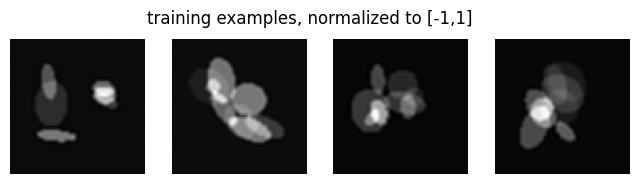

In [5]:
def show_images_grid(xs, title="", n=8):
    if not SHOW_PLOTS and not SAVE_FIGURES:
        return
    xs = xs.detach().cpu()
    n = min(n, xs.shape[0])
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2))
    if n == 1:
        axes = [axes]
    for i in range(n):
        axes[i].imshow(xs[i, 0], cmap="gray", vmin=-1, vmax=1)
        axes[i].axis("off")
    fig.suptitle(title)
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / "training_examples.png", dpi=150, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)

batch = next(iter(train_loader))
show_images_grid(batch, "training examples, normalized to [-1,1]", n=min(8, batch.shape[0]))


## 4. CNN score model and denoising score matching

We train a small U-Net score model on clean single-coil MRI images. The forward noising process is

\[
x_t=(1-t)x_0+\sqrt{t(2-t)}\,\xi,
\qquad \xi\sim N(0,I),
\]

and the denoising score target is

\[
s_\theta(x_t,t)\approx -\xi/\sqrt{t(2-t)}.
\]

In [6]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = int(dim)

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        # t: (B,)
        half = self.dim // 2
        device = t.device
        freqs = torch.exp(torch.linspace(math.log(1.0), math.log(1000.0), half, device=device))
        args = t[:, None] * freqs[None, :]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        if emb.shape[-1] < self.dim:
            emb = F.pad(emb, (0, self.dim - emb.shape[-1]))
        return emb


class TimeBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, emb_dim: int):
        super().__init__()
        groups = 8 if out_ch % 8 == 0 else 1
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(groups, out_ch)
        self.emb_proj = nn.Linear(emb_dim, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(groups, out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = F.silu(h)
        h = h + self.emb_proj(emb)[:, :, None, None]
        h = self.conv2(h)
        h = self.norm2(h)
        h = F.silu(h)
        return h + self.skip(x)


class SmallUNetScore(nn.Module):
    def __init__(self, in_ch=1, base_ch=32, emb_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(emb_dim),
            nn.Linear(emb_dim, emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim),
        )
        self.enc1 = TimeBlock(in_ch, base_ch, emb_dim)
        self.enc2 = TimeBlock(base_ch, base_ch * 2, emb_dim)
        self.enc3 = TimeBlock(base_ch * 2, base_ch * 4, emb_dim)
        self.pool = nn.AvgPool2d(2)
        self.up2 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 2, stride=2)
        self.dec2 = TimeBlock(base_ch * 4, base_ch * 2, emb_dim)
        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch, 2, stride=2)
        self.dec1 = TimeBlock(base_ch * 2, base_ch, emb_dim)
        self.out = nn.Conv2d(base_ch, in_ch, 3, padding=1)

    def forward(self, x, t):
        # t should be in [0,1], shape (B,)
        emb = self.time_mlp(t)
        e1 = self.enc1(x, emb)
        e2 = self.enc2(self.pool(e1), emb)
        e3 = self.enc3(self.pool(e2), emb)
        u2 = self.up2(e3)
        if u2.shape[-2:] != e2.shape[-2:]:
            u2 = F.interpolate(u2, size=e2.shape[-2:], mode="bilinear", align_corners=False)
        d2 = self.dec2(torch.cat([u2, e2], dim=1), emb)
        u1 = self.up1(d2)
        if u1.shape[-2:] != e1.shape[-2:]:
            u1 = F.interpolate(u1, size=e1.shape[-2:], mode="bilinear", align_corners=False)
        d1 = self.dec1(torch.cat([u1, e1], dim=1), emb)
        return self.out(d1)


def dsm_loss(model: nn.Module, x0: torch.Tensor) -> torch.Tensor:
    B = x0.shape[0]
    t = torch.rand(B, device=x0.device) * (DSM_T_MAX - DSM_T_MIN) + DSM_T_MIN
    sigma = torch.sqrt(torch.clamp(t * (2.0 - t), min=1e-8)).view(B, 1, 1, 1)
    mean = (1.0 - t).view(B, 1, 1, 1) * x0
    eps = torch.randn_like(x0)
    xt = mean + sigma * eps
    target = -eps / sigma
    pred = model(xt, t)
    sq = (pred - target) ** 2
    if DSM_WEIGHT_BY_SIGMA2:
        sq = sq * sigma ** 2
    return sq.mean()


score_model = SmallUNetScore(in_ch=1, base_ch=BASE_CHANNELS, emb_dim=TIME_EMB_DIM).to(DEVICE)
print("score model parameters:", sum(p.numel() for p in score_model.parameters()) / 1e6, "M")

score model parameters: 0.562625 M


## 5. Train or load the score prior

For a first test, 3k steps is enough to check that the pipeline runs. For a usable MRI prior, increase `NUM_TRAIN_STEPS` and `MAX_FASTMRI_FILES`.

In [7]:
def infinite_loader(loader):
    while True:
        for batch in loader:
            yield batch


# score_model is created in the model-definition cell. Create it here only if cells were run out of order.
created_score_model_here = False
try:
    score_model
except NameError:
    score_model = SmallUNetScore(in_ch=1, base_ch=BASE_CHANNELS, emb_dim=TIME_EMB_DIM).to(DEVICE)
    created_score_model_here = True
if created_score_model_here:
    print("score model parameters:", sum(p.numel() for p in score_model.parameters()) / 1e6, "M")

# Always define these diagnostics, including checkpoint-only runs.
score_training_losses = []
score_training_steps = []
score_training_loss_source = "unavailable"
checkpoint_loaded = False
need_train = True

if LOAD_CHECKPOINT_IF_EXISTS and CHECKPOINT_PATH.exists():
    print(f"Loading checkpoint: {CHECKPOINT_PATH}")
    try:
        try:
            ckpt = torch.load(str(CHECKPOINT_PATH), map_location=DEVICE, weights_only=False)
        except TypeError:
            ckpt = torch.load(str(CHECKPOINT_PATH), map_location=DEVICE)

        score_model.load_state_dict(ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt)
        checkpoint_loaded = True
        print("Using pretrained prior checkpoint:", CHECKPOINT_PATH)
        need_train = False
        print("Checkpoint loaded successfully.")

        if isinstance(ckpt, dict):
            history = ckpt.get("loss_history", ckpt.get("training_losses", None))
            if history is not None:
                if torch.is_tensor(history):
                    history = history.detach().cpu().numpy()
                score_training_losses = np.asarray(history, dtype=np.float64).reshape(-1).tolist()
                score_training_steps = list(range(1, len(score_training_losses) + 1))
                score_training_loss_source = "loaded checkpoint"
                print(f"Loaded {len(score_training_losses)} training-loss values from checkpoint.")
            else:
                print("Checkpoint contains no training-loss history; the fixed-time DSM profile below will still be evaluated.")
    except Exception as e:
        print("Could not load checkpoint; will train from scratch.")
        print("Checkpoint load error:", repr(e))

if need_train:
    if NUM_TRAIN_STEPS <= 0:
        _msg = (
            "No pretrained prior checkpoint was loaded, and NUM_TRAIN_STEPS <= 0. "
            f"Expected checkpoint at CHECKPOINT_PATH={CHECKPOINT_PATH}."
        )
        if REQUIRE_PRETRAINED_PRIOR:
            raise FileNotFoundError(
                _msg
                + " Set CHECKPOINT_PATH/SAVED_CHECKPOINT_PATH/PRIOR_CHECKPOINT_PATH to the trained prior, "
                + "or set REQUIRE_PRETRAINED_PRIOR=0 only for a smoke test."
            )
        print(_msg)
        print("REQUIRE_PRETRAINED_PRIOR=0, so leaving score model untrained for a smoke test only.")
    else:
        print("Training score model...")
        score_model.train()
        opt = torch.optim.AdamW(score_model.parameters(), lr=LR, weight_decay=1e-4)
        data_iter = infinite_loader(train_loader)
        pbar = tqdm(range(1, NUM_TRAIN_STEPS + 1))
        for step in pbar:
            x0 = next(data_iter).to(DEVICE, non_blocking=PIN_MEMORY)
            loss = dsm_loss(score_model, x0)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(score_model.parameters(), 1.0)
            opt.step()

            score_training_losses.append(float(loss.detach().cpu()))
            score_training_steps.append(int(step))
            if step % 50 == 0:
                pbar.set_description(f"loss={np.mean(score_training_losses[-50:]):.4f}")
            if step % 500 == 0:
                clear_device_cache()

        score_training_loss_source = "trained in this run"
        if SAVE_CHECKPOINT:
            CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
            torch.save(
                {
                    "model": score_model.state_dict(),
                    "config": {
                        "IMG_SIZE": IMG_SIZE,
                        "BASE_CHANNELS": BASE_CHANNELS,
                        "TIME_EMB_DIM": TIME_EMB_DIM,
                        "DSM_T_MIN": DSM_T_MIN,
                        "DSM_T_MAX": DSM_T_MAX,
                        "DSM_WEIGHT_BY_SIGMA2": DSM_WEIGHT_BY_SIGMA2,
                    },
                    # Tensor form remains compatible with recent torch.load defaults.
                    "loss_history": torch.as_tensor(score_training_losses, dtype=torch.float32),
                },
                str(CHECKPOINT_PATH),
            )
            print(f"Saved checkpoint: {CHECKPOINT_PATH}")

score_training_losses = np.asarray(score_training_losses, dtype=np.float64)
score_training_steps = np.asarray(score_training_steps, dtype=np.int64)
score_model.eval()
clear_device_cache()
print("training-loss source:", score_training_loss_source)


Loading checkpoint: /p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_outputs/score_prior_singlecoil_mri_64_trained.pt
Using pretrained prior checkpoint: /p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_outputs/score_prior_singlecoil_mri_64_trained.pt
Checkpoint loaded successfully.
Loaded 50000 training-loss values from checkpoint.
training-loss source: loaded checkpoint


## 5A. Score-prior training-loss diagnostics

The first panel displays the optimizer loss recorded during score training. The second panel evaluates the same denoising score-matching objective at fixed forward-noising times on held-out validation/synthetic samples. If an older checkpoint has no stored loss history, only the fixed-time profile is shown.

Training dataset class: SyntheticMRIDataset
Validation dataset class: SyntheticMRIDataset
Recorded optimizer losses: 50000
Fixed-time DSM loss mean/min/max: 0.01402609529759502 0.00011719198664650321 0.12815648317337036


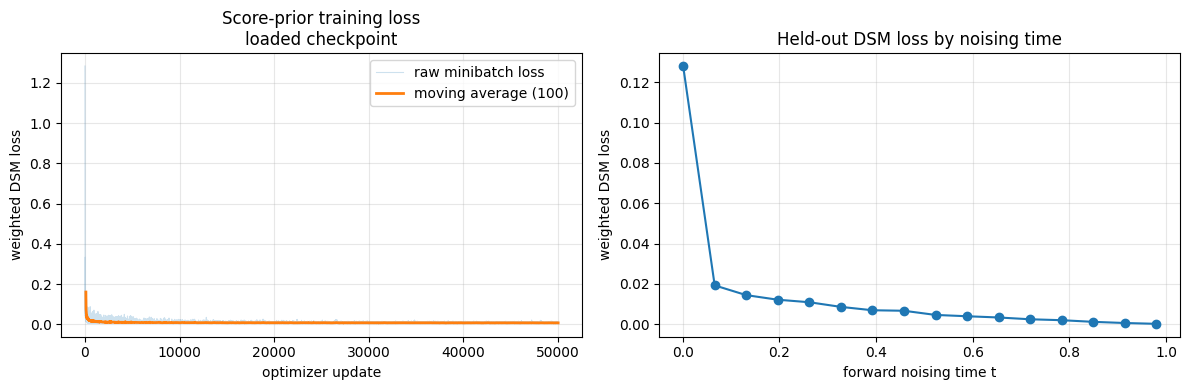

In [8]:
# ============================================================
# Score-prior training diagnostics
# ============================================================

def moving_average_1d(values, window):
    values = np.asarray(values, dtype=np.float64)
    window = max(1, min(int(window), len(values))) if len(values) else 1
    if len(values) == 0 or window == 1:
        return values.copy()
    kernel = np.ones(window, dtype=np.float64) / float(window)
    return np.convolve(values, kernel, mode="valid")


@torch.no_grad()
def dsm_loss_fixed_time_per_sample(model, x0, t_value, generator):
    """Per-sample weighted DSM loss at a fixed forward-noising time."""
    B = x0.shape[0]
    t = torch.full((B,), float(t_value), device=x0.device, dtype=x0.dtype)
    sigma = torch.sqrt(torch.clamp(t * (2.0 - t), min=1e-8)).view(B, 1, 1, 1)
    mean = (1.0 - t).view(B, 1, 1, 1) * x0
    eps = torch.randn(x0.shape, device=x0.device, dtype=x0.dtype, generator=generator)
    xt = mean + sigma * eps
    target = -eps / sigma
    pred = model(xt, t)
    sq = (pred - target) ** 2
    if DSM_WEIGHT_BY_SIGMA2:
        sq = sq * sigma ** 2
    return sq.flatten(1).mean(dim=1)


score_validation_time_grid = np.asarray([], dtype=np.float64)
score_validation_time_loss = np.asarray([], dtype=np.float64)

if TRAIN_LOSS_TIME_BINS > 0 and TRAIN_LOSS_EVAL_BATCHES > 0:
    score_model.eval()
    val_loss_loader = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
    score_validation_time_grid = np.linspace(DSM_T_MIN, DSM_T_MAX, TRAIN_LOSS_TIME_BINS)
    time_losses = []

    for t_idx, t_value in enumerate(score_validation_time_grid):
        vals = []
        generator = torch.Generator(device=DEVICE)
        generator.manual_seed(SEED + 70000 + t_idx)
        for batch_idx, batch in enumerate(val_loss_loader):
            if batch_idx >= TRAIN_LOSS_EVAL_BATCHES:
                break
            x0 = batch.to(DEVICE, non_blocking=PIN_MEMORY)
            vals.append(dsm_loss_fixed_time_per_sample(score_model, x0, t_value, generator).detach().cpu())
        time_losses.append(float(torch.cat(vals).mean()) if vals else float("nan"))

    score_validation_time_loss = np.asarray(time_losses, dtype=np.float64)

print("Training dataset class:", type(train_ds).__name__)
print("Validation dataset class:", type(val_ds).__name__)
print("Recorded optimizer losses:", int(score_training_losses.size))
if score_validation_time_loss.size:
    print("Fixed-time DSM loss mean/min/max:",
          float(np.nanmean(score_validation_time_loss)),
          float(np.nanmin(score_validation_time_loss)),
          float(np.nanmax(score_validation_time_loss)))

if PLOT_SCORE_TRAINING_LOSS and (score_training_losses.size or score_validation_time_loss.size):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    if score_training_losses.size:
        axes[0].plot(score_training_steps, score_training_losses, alpha=0.22, linewidth=0.8, label="raw minibatch loss")
        smooth = moving_average_1d(score_training_losses, TRAIN_LOSS_SMOOTH_WINDOW)
        smooth_steps = score_training_steps[len(score_training_steps) - len(smooth):]
        axes[0].plot(smooth_steps, smooth, linewidth=2.0, label=f"moving average ({min(TRAIN_LOSS_SMOOTH_WINDOW, len(score_training_losses))})")
        axes[0].set_title(f"Score-prior training loss\n{score_training_loss_source}")
        axes[0].set_xlabel("optimizer update")
        axes[0].set_ylabel("weighted DSM loss")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()
    else:
        axes[0].text(0.5, 0.5, "No stored training-loss history\nin the loaded checkpoint", ha="center", va="center")
        axes[0].set_axis_off()

    if score_validation_time_loss.size:
        axes[1].plot(score_validation_time_grid, score_validation_time_loss, marker="o")
        axes[1].set_title("Held-out DSM loss by noising time")
        axes[1].set_xlabel("forward noising time t")
        axes[1].set_ylabel("weighted DSM loss")
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].set_axis_off()

    plt.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / "score_prior_training_loss.png", dpi=160, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)

np.savez_compressed(
    OUTPUT_DIR / "score_prior_training_diagnostics.npz",
    training_steps=score_training_steps,
    training_losses=score_training_losses,
    validation_time_grid=score_validation_time_grid,
    validation_time_loss=score_validation_time_loss,
    training_loss_source=np.asarray([score_training_loss_source], dtype=object),
    dataset_class=np.asarray([type(train_ds).__name__], dtype=object),
)


## 6. Minimal prior-sampling helpers used by DPS (no SMC)

In [9]:

# ============================================================
# Minimal reverse-SDE helpers for DPS and optional prior baseline
# ============================================================
# This notebook deliberately avoids the multiscale SMC path simulator and tail-statistics cache.
# The functions below are only the small helpers needed for independent reverse-SDE/DPS sampling.


def make_generator(seed: int, device=DEVICE):
    gen = torch.Generator(device=device)
    gen.manual_seed(int(seed))
    return gen


@torch.no_grad()
def randn_seeded(shape, seed: int, device=DEVICE, dtype=torch.float32):
    return torch.randn(shape, generator=make_generator(seed, device), device=device, dtype=dtype)


@torch.no_grad()
def score_apply_torch(tau_forward: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    """Apply learned unconditional score. tau_forward is the forward noising time in [0,1]."""
    if not torch.is_tensor(tau_forward):
        tau_forward = torch.full((x.shape[0],), float(tau_forward), device=x.device, dtype=x.dtype)
    elif tau_forward.ndim == 0:
        tau_forward = torch.full((x.shape[0],), float(tau_forward.item()), device=x.device, dtype=x.dtype)
    return score_model(x, torch.clamp(tau_forward.to(x.device, x.dtype), min=DSM_T_MIN, max=DSM_T_MAX))


@torch.no_grad()
def prior_reverse_step_torch(model, x: torch.Tensor, t, dt: float, noise: torch.Tensor) -> torch.Tensor:
    """One unconditional reverse-SDE proposal step used for optional prior diagnostics."""
    t_scalar = torch.as_tensor(t, device=x.device, dtype=x.dtype)
    t_safe = torch.clamp(t_scalar, min=1e-6)
    tau = torch.clamp(1.0 - t_safe, min=DSM_T_MIN, max=DSM_T_MAX)
    tau_batch = torch.full((x.shape[0],), float(tau.detach().cpu()), device=x.device, dtype=x.dtype)
    score = model(x, tau_batch)
    drift = (x + 2.0 * score) / t_safe
    diffusion = torch.sqrt(2.0 / t_safe)
    return x + float(dt) * drift + math.sqrt(float(dt)) * diffusion * noise


@torch.no_grad()
def sample_prior_reverse_sde(
    model: nn.Module,
    num_samples: int,
    n_steps: int = None,
    seed: int = None,
    chunk_size: int = None,
) -> torch.Tensor:
    """Optional unconditional prior baseline.  Disabled by default with RUN_PRIOR_BASELINE=0."""
    model.eval()
    num_samples = int(num_samples)
    n_steps = int(n_steps if n_steps is not None else DPS_N_STEPS)
    seed = int(SEED + 123000 if seed is None else seed)
    chunk_size = int(chunk_size or SAMPLE_CHUNK_SIZE)
    outs = []
    for start in range(0, num_samples, chunk_size):
        bs = min(chunk_size, num_samples - start)
        x = randn_seeded((bs, 1, IMG_SIZE, IMG_SIZE), seed=seed + start, device=DEVICE)
        gen = make_generator(seed + 1 + start, DEVICE)
        ts = torch.linspace(float(T0), float(T1), n_steps + 1, device=DEVICE, dtype=x.dtype)
        dt = float(T1 - T0) / float(n_steps)
        for k in range(n_steps):
            noise = torch.randn(x.shape, device=DEVICE, dtype=x.dtype, generator=gen)
            x = prior_reverse_step_torch(model, x, ts[k], dt, noise)
            if SAMPLE_CLAMP is not None:
                x = torch.clamp(x, -float(SAMPLE_CLAMP), float(SAMPLE_CLAMP))
        outs.append(x.detach().cpu())
        clear_device_cache()
    return torch.cat(outs, dim=0).to(DEVICE)


prior_terminal = None
prior_mean = None
if globals().get("RUN_PRIOR_BASELINE", False):
    t_prior = time.time()
    prior_terminal = sample_prior_reverse_sde(score_model, num_samples=min(int(N_BASELINE), int(DPS_NUM_SAMPLES)))
    prior_mean = prior_terminal.mean(dim=0, keepdim=True)
    sync_device()
    print("Prior baseline sampled in %.1f sec" % (time.time() - t_prior))
    print("prior samples:", tuple(prior_terminal.shape))
else:
    print("RUN_PRIOR_BASELINE=False; skipping optional prior samples.")


RUN_PRIOR_BASELINE=False; skipping optional prior samples.


## 7. Observation model

The default in this file is `OBS_MODE="phase_retrieval"` with a Gaussian likelihood. The nonlinear forward map observes a possibly masked two-dimensional Fourier magnitude. Because magnitude is already real, the observation dimension equals the number of retained Fourier-magnitude entries; it is **not doubled** by real/imaginary packing.

Available observation modes remain:

- `phase_retrieval`: nonlinear 2D Fourier magnitude;
- `mri_fft`: masked complex Fourier samples packed as real/imaginary values;
- `random_inpainting`: selected image pixels.

In [10]:
# DELTA_OBS is configured in Section 1.
# The held-out target x_true and y_obs are created after the MRI observation operator is defined.

OBS_MODE: mri_fft (FFT/k-space)
Mask type: lowpass_square
low-pass square size: 4 x 4
sampled k-space points: 16 / 4096 effective accel: 256.0
packed observation dimension: 32


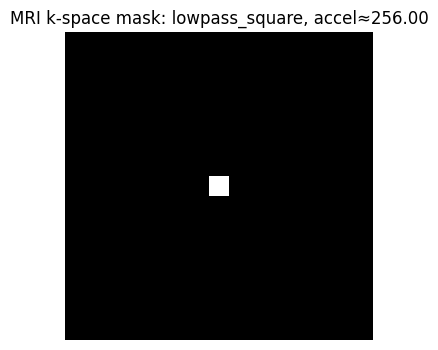

In [11]:
# ============================================================
# Observation model: spatial projection, 2D phase retrieval, FFT/MRI, or random inpainting
# ============================================================

MRI_OBS_MODES = {"mri_fft", "fft", "singlecoil_mri", "singlecoil_fft"}
RANDOM_INPAINT_OBS_MODES = {"random_inpainting", "random_inpaint", "inpaint_random", "pixel_inpaint"}
SPATIAL_PROJECTION_OBS_MODES = {"spatial_projection", "identity_projection", "masked_identity", "identity_mask", "spatial_mask", "pixel_projection"}
PHASE_RETRIEVAL_OBS_MODES = {
    "phase_retrieval", "phase_retrieval_2d", "fourier_magnitude", "fft_magnitude"
}
CT_OBS_MODES = {
    "ct_poisson", "ct_parallel_beam", "lodopab_ct", "ct_lowdose_poisson",
    "ct_gaussian", "ct_radon_gaussian", "ct_scan", "ct_limited_angle", "ct_limited_angle_gaussian"
}
OBS_MODE = OBS_MODE.strip().lower()
LIKELIHOOD_TYPE = LIKELIHOOD_TYPE.strip().lower()


def make_cartesian_mask_2d(H: int, W: int, accel: int = 4, center_fraction: float = 0.08,
                           seed: int = 0, device=DEVICE) -> torch.Tensor:
    rng = np.random.default_rng(int(seed))
    mask_cols = np.zeros(W, dtype=bool)
    num_low = max(1, int(round(W * center_fraction)))
    start = W // 2 - num_low // 2
    stop = start + num_low
    mask_cols[start:stop] = True
    target_cols = max(num_low, int(round(W / accel)))
    remaining = np.flatnonzero(~mask_cols)
    extra = target_cols - int(mask_cols.sum())
    if extra > 0:
        chosen = rng.choice(remaining, size=extra, replace=False)
        mask_cols[chosen] = True
    mask = np.zeros((H, W), dtype=bool)
    mask[:, mask_cols] = True
    return torch.as_tensor(mask, dtype=torch.bool, device=device)


def make_vd_poisson_mask_2d(H: int, W: int, accel: int = 8, center_fraction: float = 0.08,
                            seed: int = 0, device=DEVICE) -> torch.Tensor:
    """Lightweight variable-density point mask for k-space experiments."""
    rng = np.random.default_rng(int(seed))
    yy, xx = np.mgrid[-1:1:complex(H), -1:1:complex(W)]
    rr = np.sqrt(xx**2 + yy**2)
    prob = np.exp(-(rr / 0.45) ** 2)
    prob = prob / prob.mean() / accel
    prob = np.clip(prob, 0.0, 1.0)
    mask = rng.random((H, W)) < prob
    low_h = max(1, int(round(H * center_fraction)))
    low_w = max(1, int(round(W * center_fraction)))
    hs = H // 2 - low_h // 2
    ws = W // 2 - low_w // 2
    mask[hs:hs + low_h, ws:ws + low_w] = True
    target = max(1, int(round(H * W / accel)))
    current = int(mask.sum())
    flat = mask.reshape(-1)
    if current < target:
        candidates = np.flatnonzero(~flat)
        add = rng.choice(candidates, size=min(target - current, len(candidates)), replace=False)
        flat[add] = True
    elif current > target:
        protected = np.zeros((H, W), dtype=bool)
        protected[hs:hs + low_h, ws:ws + low_w] = True
        candidates = np.flatnonzero(flat & ~protected.reshape(-1))
        drop = rng.choice(candidates, size=min(current - target, len(candidates)), replace=False)
        flat[drop] = False
    return torch.as_tensor(flat.reshape(H, W), dtype=torch.bool, device=device)

def make_block_mask_2d(H: int, W: int, block_size: int = 4, num_blocks: int = 4,
                       gap_size: Optional[int] = None, device=DEVICE) -> torch.Tensor:
    """Centered block k-space mask. True means observable.

    Blocks lie on a regular 2D lattice. Each block is block_size x block_size,
    and the gap between neighboring lattice blocks is gap_size. By default
    gap_size equals block_size, so 4x4 blocks have 4-pixel gaps. The selected
    blocks are filled from the Fourier center outward.
    """
    block_size = int(block_size)
    num_blocks = int(num_blocks)
    gap_size = block_size if gap_size is None else int(gap_size)
    if block_size <= 0:
        raise ValueError(f"block_size must be positive, got {block_size}")
    if num_blocks <= 0:
        raise ValueError(f"num_blocks must be positive, got {num_blocks}")
    if gap_size < 0:
        raise ValueError(f"gap_size must be nonnegative, got {gap_size}")
    if block_size > H or block_size > W:
        raise ValueError(f"block_size={block_size} does not fit mask size {H}x{W}")

    pitch = block_size + gap_size
    center_h = H // 2 - block_size // 2
    center_w = W // 2 - block_size // 2
    span = max(H, W) // max(pitch, 1) + 2

    candidates = []
    image_center_h = (H - 1) / 2.0
    image_center_w = (W - 1) / 2.0
    for r in range(-span, span + 1):
        for c in range(-span, span + 1):
            hs = center_h + r * pitch
            ws = center_w + c * pitch
            if hs < 0 or ws < 0 or hs + block_size > H or ws + block_size > W:
                continue
            bh = hs + (block_size - 1) / 2.0
            bw = ws + (block_size - 1) / 2.0
            dist2 = (bh - image_center_h) ** 2 + (bw - image_center_w) ** 2
            candidates.append((dist2, abs(r) + abs(c), r, c, hs, ws))

    if num_blocks > len(candidates):
        raise ValueError(
            f"Requested {num_blocks} blocks, but only {len(candidates)} fit in a {H}x{W} mask. "
            "Reduce BLOCK_MASK_NUM_BLOCKS, BLOCK_MASK_BLOCK_SIZE, or BLOCK_MASK_GAP."
        )

    candidates.sort()
    mask = np.zeros((H, W), dtype=bool)
    for _, _, _, _, hs, ws in candidates[:num_blocks]:
        mask[hs:hs + block_size, ws:ws + block_size] = True
    return torch.as_tensor(mask, dtype=torch.bool, device=device)


def make_lowpass_square_mask_2d(H: int, W: int, square_size: int = 16, device=DEVICE) -> torch.Tensor:
    """Centered low-pass square k-space mask. True means observable.

    The notebook uses fft2c_img, which returns fftshifted / centered k-space.
    Therefore the DC coefficient, i.e. Fourier coordinate (ky,kx)=(0,0), is at
    array index (H//2, W//2).  This mask observes only a square centered there.

    Examples for IMG_SIZE=64:
        square_size=4  -> 16 observed complex k-space coefficients
        square_size=8  -> 64 observed complex k-space coefficients
        square_size=16 -> 256 observed complex k-space coefficients

    For OBS_MODE=mri_fft, OBS_DIM is doubled because real and imaginary parts
    are packed into one real observation vector.
    """
    H = int(H)
    W = int(W)
    square_size = int(square_size)
    if H <= 0 or W <= 0:
        raise ValueError(f"H and W must be positive, got H={H}, W={W}")
    if square_size <= 0:
        raise ValueError(f"LOWPASS_SQUARE_SIZE must be positive, got {square_size}")
    if square_size > H or square_size > W:
        raise ValueError(
            f"LOWPASS_SQUARE_SIZE={square_size} does not fit inside mask size {H}x{W}."
        )

    mask = np.zeros((H, W), dtype=bool)
    hs = H // 2 - square_size // 2
    ws = W // 2 - square_size // 2
    mask[hs:hs + square_size, ws:ws + square_size] = True
    return torch.as_tensor(mask, dtype=torch.bool, device=device)


def make_random_inpainting_mask_2d(H: int, W: int, keep_fraction: float = 0.2,
                                   seed: int = 0, device=DEVICE) -> torch.Tensor:
    """Fixed random pixel inpainting mask. True means observed pixel."""
    keep_fraction = float(keep_fraction)
    if not (0.0 < keep_fraction <= 1.0):
        raise ValueError(f"INPAINT_KEEP_FRACTION must be in (0,1], got {keep_fraction}")
    rng = np.random.default_rng(int(seed))
    d = int(H * W)
    m = max(1, int(round(keep_fraction * d)))
    idx = np.sort(rng.choice(d, size=m, replace=False))
    mask = np.zeros(d, dtype=bool)
    mask[idx] = True
    return torch.as_tensor(mask.reshape(H, W), dtype=torch.bool, device=device)



def make_center_square_mask_2d(H: int, W: int, keep_fraction: float = 0.2,
                               device=DEVICE) -> torch.Tensor:
    """Centered spatial square mask. True means the pixel is observed."""
    keep_fraction = float(keep_fraction)
    if not (0.0 < keep_fraction <= 1.0):
        raise ValueError(f"keep_fraction must be in (0,1], got {keep_fraction}")
    target = max(1, int(round(keep_fraction * H * W)))
    side = max(1, int(round(math.sqrt(target))))
    side_h = min(H, side)
    side_w = min(W, max(1, int(math.ceil(target / max(side_h, 1)))))
    hs = H // 2 - side_h // 2
    ws = W // 2 - side_w // 2
    mask = np.zeros((H, W), dtype=bool)
    mask[hs:hs + side_h, ws:ws + side_w] = True
    return torch.as_tensor(mask, dtype=torch.bool, device=device)


def make_spatial_projection_mask_2d(H: int, W: int, mask_type: str = "random",
                                    keep_fraction: float = 0.2, seed: int = 0,
                                    block_size: int = 4, num_blocks: int = 4,
                                    gap_size: Optional[int] = None, device=DEVICE) -> torch.Tensor:
    """Purely spatial mask for the identity projection h(x)=P_Omega x.

    True means the corresponding image pixel is observed.  Unlike the MRI and
    phase-retrieval masks above, this mask lives in image coordinates, not in
    Fourier/k-space coordinates.
    """
    mt = str(mask_type).strip().lower()
    if mt in {"random", "uniform_random", "pixel_random"}:
        return make_random_inpainting_mask_2d(
            H, W, keep_fraction=keep_fraction, seed=seed, device=device
        )
    if mt in {"center", "center_square", "central_square"}:
        return make_center_square_mask_2d(
            H, W, keep_fraction=keep_fraction, device=device
        )
    if mt in {"block", "blocks", "block_grid"}:
        return make_block_mask_2d(
            H, W, block_size=block_size, num_blocks=num_blocks,
            gap_size=gap_size, device=device
        )
    if mt in {"full", "all", "identity"}:
        return torch.ones((H, W), dtype=torch.bool, device=device)
    raise ValueError(
        f"Unknown SPATIAL_MASK_TYPE={mask_type}; use random, center_square, block, or full."
    )


def make_vd_fraction_mask_2d(H: int, W: int, keep_fraction: float = 0.8,
                             center_fraction: float = 0.12, seed: int = 0,
                             device=DEVICE) -> torch.Tensor:
    """Variable-density point mask with an exact target keep fraction.

    Used for the CT ray-angle grid.  The grid is treated as a 2D acquisition
    coordinate array; the Gaussian density concentrates samples near the center
    and scatters the rest over outer coordinates, analogous to the vd_poisson
    Fourier masks used above.
    """
    keep_fraction = float(keep_fraction)
    if not (0.0 < keep_fraction <= 1.0):
        raise ValueError(f"keep_fraction must be in (0,1], got {keep_fraction}")
    rng = np.random.default_rng(int(seed))
    yy, xx = np.mgrid[-1:1:complex(H), -1:1:complex(W)]
    rr = np.sqrt(xx ** 2 + yy ** 2)
    weights = np.exp(-(rr / 0.50) ** 2).reshape(-1)
    weights = weights / np.maximum(weights.sum(), 1e-12)

    target = max(1, int(round(keep_fraction * H * W)))
    mask = np.zeros(H * W, dtype=bool)

    # Always keep a small center block as the low-frequency-like core.
    low_h = max(1, int(round(H * center_fraction)))
    low_w = max(1, int(round(W * center_fraction)))
    hs = H // 2 - low_h // 2
    ws = W // 2 - low_w // 2
    protected = np.zeros((H, W), dtype=bool)
    protected[hs:hs + low_h, ws:ws + low_w] = True
    mask[protected.reshape(-1)] = True

    current = int(mask.sum())
    if current < target:
        candidates = np.flatnonzero(~mask)
        p = weights[candidates]
        p = p / np.maximum(p.sum(), 1e-12)
        chosen = rng.choice(candidates, size=min(target - current, len(candidates)), replace=False, p=p)
        mask[chosen] = True
    elif current > target:
        candidates = np.flatnonzero(mask & ~protected.reshape(-1))
        drop = rng.choice(candidates, size=min(current - target, len(candidates)), replace=False)
        mask[drop] = False

    return torch.as_tensor(mask.reshape(H, W), dtype=torch.bool, device=device)


def positive_base_torch(z: torch.Tensor) -> torch.Tensor:
    if POISSON_RATE_LINK == "softplus":
        return F.softplus(z + POISSON_RATE_OFFSET)
    if POISSON_RATE_LINK == "exp":
        return torch.exp(z + POISSON_RATE_OFFSET)
    raise ValueError(f"Unknown POISSON_RATE_LINK={POISSON_RATE_LINK}")


def poisson_rate_from_z_torch(z: torch.Tensor, eps: float = POISSON_EPS) -> torch.Tensor:
    return POISSON_RATE_SCALE * positive_base_torch(z) + eps


def inverse_poisson_rate_to_z_torch(y_count: torch.Tensor) -> torch.Tensor:
    """Approximate inverse of lambda=alpha*g(z+offset)+eps, for display only."""
    base = torch.clamp(
        (y_count.to(torch.float32) - POISSON_EPS) / max(float(POISSON_RATE_SCALE), 1e-12),
        min=1e-8,
    )
    if POISSON_RATE_LINK == "softplus":
        inv = torch.where(base > 20.0, base, torch.log(torch.expm1(base) + 1e-12))
        return inv - POISSON_RATE_OFFSET
    if POISSON_RATE_LINK == "exp":
        return torch.log(base) - POISSON_RATE_OFFSET
    raise ValueError(f"Unknown POISSON_RATE_LINK={POISSON_RATE_LINK}")


def phase_retrieval_map_torch(x: torch.Tensor) -> torch.Tensor:
    """Smooth 2D Fourier amplitude/intensity map, shape (B,H,W)."""
    k = fft2c_img(x)
    power = k.real.square() + k.imag.square()
    if PHASE_RETRIEVAL_MEASUREMENT == "amplitude":
        return torch.sqrt(power + float(PHASE_RETRIEVAL_EPS) ** 2)
    if PHASE_RETRIEVAL_MEASUREMENT == "intensity":
        return power
    raise ValueError(
        f"Unknown PHASE_RETRIEVAL_MEASUREMENT={PHASE_RETRIEVAL_MEASUREMENT}; "
        "use 'amplitude' or 'intensity'."
    )



def make_ct_limited_angle_mask(num_angles: int, num_detectors: int,
                               coverage_degrees: float = 90.0,
                               start_degrees: float = 0.0,
                               max_degrees: float = 180.0,
                               device=DEVICE) -> torch.Tensor:
    """Contiguous limited-angle CT mask.

    Keeps all detector bins for angles in a contiguous angular sector and masks
    all detector bins outside the sector.  This is the DOLCE-style CT geometry:

        Omega = Theta_obs x {1,...,N_detectors}.

    coverage_degrees=60,90,120 correspond to the usual limited-angle settings.
    """
    num_angles = int(num_angles)
    num_detectors = int(num_detectors)
    max_degrees = float(max_degrees)
    coverage_degrees = float(coverage_degrees)
    start_degrees = float(start_degrees)
    if max_degrees <= 0:
        raise ValueError("max_degrees must be positive.")
    coverage_fraction = max(0.0, min(1.0, coverage_degrees / max_degrees))
    n_keep = max(1, min(num_angles, int(round(coverage_fraction * num_angles))))
    start_fraction = (start_degrees / max_degrees) % 1.0
    start = int(round(start_fraction * num_angles)) % num_angles
    angle_mask = torch.zeros(num_angles, dtype=torch.bool, device=device)
    if n_keep >= num_angles:
        angle_mask[:] = True
    else:
        idx = (torch.arange(n_keep, device=device) + start) % num_angles
        angle_mask[idx] = True
    return angle_mask[:, None].expand(num_angles, num_detectors).contiguous()


def make_ct_sparse_view_mask(num_angles: int, num_detectors: int,
                             view_fraction: float = 0.25,
                             offset: int = 0,
                             device=DEVICE) -> torch.Tensor:
    """Sparse-view CT mask: keep all detector bins for a subset of angles."""
    num_angles = int(num_angles)
    num_detectors = int(num_detectors)
    view_fraction = float(view_fraction)
    if not (0.0 < view_fraction <= 1.0):
        raise ValueError(f"view_fraction must be in (0,1], got {view_fraction}")
    if view_fraction >= 1.0:
        return torch.ones((num_angles, num_detectors), dtype=torch.bool, device=device)
    step = max(1, int(round(1.0 / view_fraction)))
    angle_mask = torch.zeros(num_angles, dtype=torch.bool, device=device)
    angle_mask[int(offset) % step::step] = True
    return angle_mask[:, None].expand(num_angles, num_detectors).contiguous()


# -----------------------------
# LoDoPaB-style CT observation utilities
# -----------------------------
def ct_image_to_attenuation_torch(x: torch.Tensor) -> torch.Tensor:
    """Map synthetic image values to nonnegative attenuation coefficients.

    The prior images are normalized near [-1,1], while CT transmission needs
    nonnegative attenuation.  The default softplus link is smooth and positive.
    """
    if x.ndim == 3:
        x = x[:, None]
    mode = str(CT_ATTENUATION_LINK).strip().lower()
    if mode == "softplus":
        return float(CT_ATTENUATION_SCALE) * F.softplus(float(CT_ATTENUATION_GAIN) * (x + float(CT_ATTENUATION_OFFSET)))
    if mode == "sigmoid":
        return float(CT_ATTENUATION_SCALE) * torch.sigmoid(float(CT_ATTENUATION_GAIN) * (x + float(CT_ATTENUATION_OFFSET)))
    if mode in {"positive_shift", "shift_clamp"}:
        return float(CT_ATTENUATION_SCALE) * torch.clamp(x + float(CT_ATTENUATION_OFFSET), min=0.0)
    raise ValueError(f"Unknown CT_ATTENUATION_LINK={CT_ATTENUATION_LINK}")


def ct_transmission_rate_from_line_integrals_torch(line_integrals: torch.Tensor) -> torch.Tensor:
    """Poisson mean N0 exp(-A x) + background for selected CT rays."""
    return float(CT_N0_PHOTONS) * torch.exp(-torch.clamp(line_integrals, min=-30.0, max=30.0)) + float(CT_BACKGROUND_COUNTS)


def ct_line_integrals_from_counts_torch(counts: torch.Tensor) -> torch.Tensor:
    """Invert counts approximately for display/backprojection: z=-log((y-b)/N0)."""
    y = counts.to(torch.float32)
    y = torch.clamp(y - float(CT_BACKGROUND_COUNTS), min=1e-6)
    z = -torch.log(torch.clamp(y / max(float(CT_N0_PHOTONS), 1e-12), min=1e-12))
    return torch.nan_to_num(z, nan=0.0, posinf=0.0, neginf=0.0)


def ct_angles_torch(device=DEVICE, dtype=torch.float32) -> torch.Tensor:
    max_angle = math.radians(float(CT_ANGLE_MAX_DEGREES))
    # endpoint=False analogue for torch.linspace
    return torch.linspace(0.0, max_angle, int(CT_NUM_ANGLES) + 1, device=device, dtype=dtype)[:-1]


def ct_parallel_beam_sinogram_torch(x: torch.Tensor,
                                    angles: torch.Tensor = None,
                                    n_detectors: int = None,
                                    angle_chunk: int = None) -> torch.Tensor:
    """Differentiable parallel-beam Radon-like projector.

    Returns line integrals with shape (B, n_angles, n_detectors).  It rotates
    the image and sums over one spatial axis.  This is a lightweight
    matrix-free approximation suitable for synthetic 64x64 experiments.
    """
    if x.ndim == 2:
        x = x.reshape(x.shape[0], 1, IMG_SIZE, IMG_SIZE)
    if x.ndim == 3:
        x = x[:, None]
    x = x.to(torch.float32)
    B = int(x.shape[0])
    H = int(x.shape[-2])
    W = int(x.shape[-1])
    if n_detectors is None:
        n_detectors = int(CT_NUM_DETECTORS)
    if angle_chunk is None:
        angle_chunk = int(CT_ANGLE_CHUNK)
    if angles is None:
        angles = ct_angles_torch(device=x.device, dtype=x.dtype)
    else:
        angles = angles.to(device=x.device, dtype=x.dtype)

    atten = ct_image_to_attenuation_torch(x)
    outs = []
    for start in range(0, int(angles.numel()), int(angle_chunk)):
        th = angles[start:start + int(angle_chunk)]
        A = int(th.numel())
        c = torch.cos(th)
        s = torch.sin(th)
        mats = torch.zeros((A, 2, 3), device=x.device, dtype=x.dtype)
        mats[:, 0, 0] = c
        mats[:, 0, 1] = -s
        mats[:, 1, 0] = s
        mats[:, 1, 1] = c
        mats = mats[None].expand(B, A, 2, 3).reshape(B * A, 2, 3)

        imgs = atten[:, None].expand(B, A, 1, H, W).reshape(B * A, 1, H, W)
        grid = F.affine_grid(mats, size=imgs.shape, align_corners=False)
        rot = F.grid_sample(imgs, grid, mode="bilinear", padding_mode="zeros", align_corners=False)

        # Sum over rotated vertical axis, leaving detector coordinate along width.
        proj = rot.sum(dim=2).squeeze(1) * float(CT_PIXEL_SIZE)  # (B*A, W)
        if int(n_detectors) != W:
            proj = F.interpolate(proj[:, None, :], size=int(n_detectors), mode="linear", align_corners=False).squeeze(1)
        outs.append(proj.reshape(B, A, int(n_detectors)))

    return torch.cat(outs, dim=1)


@torch.no_grad()
def ct_masked_sinogram_map_from_vector(y_vec: torch.Tensor, values_are_counts: bool = True) -> torch.Tensor:
    """Scatter selected CT measurements to the full angle-detector grid."""
    y_vec = y_vec.reshape(-1).to(torch.float32)
    if values_are_counts:
        vals = torch.log1p(torch.clamp(y_vec, min=0.0))
    else:
        vals = y_vec
    full = torch.zeros((int(CT_NUM_ANGLES), int(CT_NUM_DETECTORS)), dtype=torch.float32, device=y_vec.device)
    full[CT_MASK] = vals
    return full


@torch.no_grad()
def ct_backproject_sinogram_torch(sino_full: torch.Tensor) -> torch.Tensor:
    """Simple unfiltered backprojection for display/RLS initialization.

    Input shape: (B, n_angles, n_detectors) or (n_angles, n_detectors).
    Output shape: (B,1,IMG_SIZE,IMG_SIZE), robust-normalized to [-1,1].
    """
    if sino_full.ndim == 2:
        sino_full = sino_full[None]
    sino_full = sino_full.to(torch.float32)
    B, A, D = sino_full.shape
    H = W = int(IMG_SIZE)
    angles = ct_angles_torch(device=sino_full.device, dtype=sino_full.dtype)
    yy, xx = torch.meshgrid(
        torch.linspace(-1.0, 1.0, H, device=sino_full.device, dtype=sino_full.dtype),
        torch.linspace(-1.0, 1.0, W, device=sino_full.device, dtype=sino_full.dtype),
        indexing="ij",
    )

    out = torch.zeros((B, H, W), dtype=sino_full.dtype, device=sino_full.device)
    chunk = int(CT_ANGLE_CHUNK)
    for start in range(0, A, chunk):
        th = angles[start:start + chunk]
        Ac = int(th.numel())
        c = torch.cos(th)[:, None, None]
        s = torch.sin(th)[:, None, None]
        # detector coordinate normalized to [-1,1]
        det_coord = xx[None] * c + yy[None] * s
        grid = torch.stack([
            det_coord,
            torch.zeros_like(det_coord),
        ], dim=-1)  # (Ac,H,W,2)
        grid = grid[None].expand(B, Ac, H, W, 2).reshape(B * Ac, H, W, 2)
        inp = sino_full[:, start:start + Ac, :].reshape(B * Ac, 1, 1, D)
        vals = F.grid_sample(inp, grid, mode="bilinear", padding_mode="zeros", align_corners=False)
        vals = vals.reshape(B, Ac, H, W)
        out = out + vals.sum(dim=1)

    out = out * (math.pi / max(float(A), 1.0))
    # Robust per-batch normalization for display/condition initialization.
    flat = out.flatten(1)
    lo = torch.quantile(flat, 0.01, dim=1).view(B, 1, 1)
    hi = torch.quantile(flat, 0.995, dim=1).view(B, 1, 1)
    out = torch.clamp((out - lo) / torch.clamp(hi - lo, min=1e-6), 0.0, 1.0)
    out = 2.0 * out - 1.0
    return out[:, None]


@torch.no_grad()
def ct_backprojection_from_counts(y_count: torch.Tensor) -> torch.Tensor:
    """Display baseline: invert Poisson counts to line integrals and backproject."""
    z = ct_line_integrals_from_counts_torch(y_count)
    full = torch.zeros((int(CT_NUM_ANGLES), int(CT_NUM_DETECTORS)), dtype=torch.float32, device=y_count.device)
    full[CT_MASK] = z.reshape(-1)
    return ct_backproject_sinogram_torch(full)


@torch.no_grad()
def ct_backprojection_from_line_integrals(z_obs: torch.Tensor) -> torch.Tensor:
    """Display/RLS seed for Gaussian CT: scatter line integrals and backproject."""
    full = torch.zeros((int(CT_NUM_ANGLES), int(CT_NUM_DETECTORS)), dtype=torch.float32, device=z_obs.device)
    full[CT_MASK] = z_obs.reshape(-1).to(torch.float32)
    return ct_backproject_sinogram_torch(full)


@torch.no_grad()
def ct_backprojection_from_measurement(y_vec: torch.Tensor) -> torch.Tensor:
    """CT display seed for the active likelihood."""
    if LIKELIHOOD_TYPE == "gaussian":
        return ct_backprojection_from_line_integrals(y_vec)
    return ct_backprojection_from_counts(y_vec)


# Build the active observation mask/operator.
if OBS_MODE in PHASE_RETRIEVAL_OBS_MODES:
    if LIKELIHOOD_TYPE != "gaussian":
        raise ValueError(
            "This phase-retrieval notebook uses a Gaussian magnitude likelihood. "
            "Set LIKELIHOOD_TYPE=gaussian."
        )
    if PHASE_RETRIEVAL_MASK_TYPE == "full":
        PHASE_RETRIEVAL_MASK = torch.ones((IMG_SIZE, IMG_SIZE), dtype=torch.bool, device=DEVICE)
    elif PHASE_RETRIEVAL_MASK_TYPE == "cartesian":
        PHASE_RETRIEVAL_MASK = make_cartesian_mask_2d(
            IMG_SIZE, IMG_SIZE,
            accel=PHASE_RETRIEVAL_ACCEL,
            center_fraction=PHASE_RETRIEVAL_CENTER_FRACTION,
            seed=PHASE_RETRIEVAL_MASK_SEED,
            device=DEVICE,
        )
    elif PHASE_RETRIEVAL_MASK_TYPE in {"vd_poisson", "variable_density"}:
        PHASE_RETRIEVAL_MASK = make_vd_poisson_mask_2d(
            IMG_SIZE, IMG_SIZE,
            accel=PHASE_RETRIEVAL_ACCEL,
            center_fraction=PHASE_RETRIEVAL_CENTER_FRACTION,
            seed=PHASE_RETRIEVAL_MASK_SEED,
            device=DEVICE,
        )
    elif PHASE_RETRIEVAL_MASK_TYPE in {"block", "blocks", "block_grid"}:
        PHASE_RETRIEVAL_MASK = make_block_mask_2d(
            IMG_SIZE, IMG_SIZE,
            block_size=BLOCK_MASK_BLOCK_SIZE,
            num_blocks=BLOCK_MASK_NUM_BLOCKS,
            gap_size=BLOCK_MASK_GAP,
            device=DEVICE,
        )
    else:
        raise ValueError(
            f"Unknown PHASE_RETRIEVAL_MASK_TYPE={PHASE_RETRIEVAL_MASK_TYPE}; "
            "use full, cartesian, vd_poisson, or block."
        )

    OBS_MASK = PHASE_RETRIEVAL_MASK
    MRI_MASK = OBS_MASK  # compatibility with saving code
    OBS_INDICES = None
    OBS_DIM = int(OBS_MASK.sum().item())
    MASK_TYPE = f"phase_retrieval_{PHASE_RETRIEVAL_MASK_TYPE}"
    print("OBS_MODE:", OBS_MODE, "(nonlinear 2D Fourier magnitude)")
    print("phase-retrieval measurement:", PHASE_RETRIEVAL_MEASUREMENT)
    print("phase-retrieval mask type:", PHASE_RETRIEVAL_MASK_TYPE)
    print("observed Fourier magnitudes:", OBS_DIM, "/", IMG_SIZE * IMG_SIZE)
    if PHASE_RETRIEVAL_MASK_TYPE in {"block", "blocks", "block_mask", "block_grid"}:
        print("block mask settings: block_size/num_blocks/gap:", BLOCK_MASK_BLOCK_SIZE, BLOCK_MASK_NUM_BLOCKS, BLOCK_MASK_GAP)
    print("effective magnitude sampling factor:", IMG_SIZE * IMG_SIZE / float(OBS_DIM))
    print("Note: magnitude measurements are real, so OBS_DIM is not doubled.")

elif OBS_MODE in MRI_OBS_MODES:
    if MASK_TYPE == "cartesian":
        MRI_MASK = make_cartesian_mask_2d(
            IMG_SIZE, IMG_SIZE, accel=ACCEL, center_fraction=CENTER_FRACTION,
            seed=MRI_MASK_SEED, device=DEVICE,
        )
    elif MASK_TYPE in {"vd_poisson", "variable_density"}:
        MRI_MASK = make_vd_poisson_mask_2d(
            IMG_SIZE, IMG_SIZE, accel=ACCEL, center_fraction=CENTER_FRACTION,
            seed=MRI_MASK_SEED, device=DEVICE,
        )
    elif MASK_TYPE in {"block", "blocks", "block_mask", "block_grid"}:
        MRI_MASK = make_block_mask_2d(
            IMG_SIZE, IMG_SIZE,
            block_size=BLOCK_MASK_BLOCK_SIZE,
            num_blocks=BLOCK_MASK_NUM_BLOCKS,
            gap_size=BLOCK_MASK_GAP,
            device=DEVICE,
        )
    elif MASK_TYPE in {"lowpass_square", "lowpass", "low_pass", "center_lowpass", "center_square_lowpass"}:
        MRI_MASK = make_lowpass_square_mask_2d(
            IMG_SIZE, IMG_SIZE,
            square_size=LOWPASS_SQUARE_SIZE,
            device=DEVICE,
        )
        MASK_TYPE = "lowpass_square"
    else:
        raise ValueError(f"Unknown MASK_TYPE={MASK_TYPE}; use cartesian, vd_poisson, block, or lowpass_square.")
    OBS_MASK = MRI_MASK
    OBS_INDICES = None
    OBS_DIM = int(MRI_MASK.sum().item()) * 2
    print("OBS_MODE:", OBS_MODE, "(FFT/k-space)")
    print("Mask type:", MASK_TYPE)
    if MASK_TYPE in {"block", "blocks", "block_mask", "block_grid"}:
        print("block mask settings: block_size/num_blocks/gap:", BLOCK_MASK_BLOCK_SIZE, BLOCK_MASK_NUM_BLOCKS, BLOCK_MASK_GAP)
    if MASK_TYPE == "lowpass_square":
        print("low-pass square size:", LOWPASS_SQUARE_SIZE, "x", LOWPASS_SQUARE_SIZE)
    print("sampled k-space points:", int(MRI_MASK.sum().item()), "/", IMG_SIZE * IMG_SIZE,
          "effective accel:", IMG_SIZE * IMG_SIZE / float(MRI_MASK.sum().item()))
    print("packed observation dimension:", OBS_DIM)


elif OBS_MODE in SPATIAL_PROJECTION_OBS_MODES:
    if LIKELIHOOD_TYPE != "gaussian":
        raise ValueError(
            "OBS_MODE=spatial_projection is the linear identity-projection model "
            "y = P_Omega x + Gaussian noise. Set LIKELIHOOD_TYPE=gaussian."
        )
    OBS_MASK = make_spatial_projection_mask_2d(
        IMG_SIZE, IMG_SIZE,
        mask_type=SPATIAL_MASK_TYPE,
        keep_fraction=SPATIAL_KEEP_FRACTION,
        seed=SPATIAL_MASK_SEED,
        block_size=SPATIAL_BLOCK_SIZE,
        num_blocks=SPATIAL_NUM_BLOCKS,
        gap_size=SPATIAL_BLOCK_GAP,
        device=DEVICE,
    )
    MRI_MASK = OBS_MASK  # compatibility with existing saving/plotting code
    OBS_INDICES = torch.nonzero(OBS_MASK.reshape(-1), as_tuple=False).flatten().to(device=DEVICE)
    OBS_DIM = int(OBS_INDICES.numel())
    MASK_TYPE = f"spatial_projection_{SPATIAL_MASK_TYPE}"
    print("OBS_MODE:", OBS_MODE, "(identity operator with spatial projection mask)")
    print("Forward operator: h(x) = P_Omega x, with Omega in image/spatial coordinates")
    print("spatial mask type:", SPATIAL_MASK_TYPE)
    print("observed pixels:", OBS_DIM, "/", IMG_SIZE * IMG_SIZE,
          "observed fraction:", OBS_DIM / float(IMG_SIZE * IMG_SIZE))
    print("SPATIAL_KEEP_FRACTION:", SPATIAL_KEEP_FRACTION, "SPATIAL_MASK_SEED:", SPATIAL_MASK_SEED)
    if SPATIAL_MASK_TYPE in {"block", "blocks", "block_grid"}:
        print("spatial block settings: block_size/num_blocks/gap:",
              SPATIAL_BLOCK_SIZE, SPATIAL_NUM_BLOCKS, SPATIAL_BLOCK_GAP)

elif OBS_MODE in RANDOM_INPAINT_OBS_MODES:
    OBS_MASK = make_random_inpainting_mask_2d(
        IMG_SIZE, IMG_SIZE,
        keep_fraction=INPAINT_KEEP_FRACTION,
        seed=INPAINT_MASK_SEED,
        device=DEVICE,
    )
    MRI_MASK = OBS_MASK
    OBS_INDICES = torch.nonzero(OBS_MASK.reshape(-1), as_tuple=False).flatten().to(device=DEVICE)
    OBS_DIM = int(OBS_INDICES.numel())
    MASK_TYPE = "random_inpainting"
    print("OBS_MODE:", OBS_MODE, "(random pixel inpainting)")
    print("observed pixels:", OBS_DIM, "/", IMG_SIZE * IMG_SIZE,
          "observed fraction:", OBS_DIM / float(IMG_SIZE * IMG_SIZE))
    print("INPAINT_MASK_SEED:", INPAINT_MASK_SEED)


elif OBS_MODE in CT_OBS_MODES:
    if LIKELIHOOD_TYPE not in {"gaussian", "poisson_direct", "poisson_gaussian"}:
        raise ValueError(
            "CT mode supports either a Gaussian sinogram likelihood "
            "(DOLCE-style limited-angle CT) or a Poisson transmission likelihood "
            "(LoDoPaB-style low-dose CT)."
        )

    if CT_MASK_TYPE in {"full", "none", "all"}:
        CT_MASK = torch.ones((int(CT_NUM_ANGLES), int(CT_NUM_DETECTORS)), dtype=torch.bool, device=DEVICE)
    elif CT_MASK_TYPE in {"limited_angle", "angular_coverage", "limited", "limited-angle"}:
        CT_MASK = make_ct_limited_angle_mask(
            int(CT_NUM_ANGLES),
            int(CT_NUM_DETECTORS),
            coverage_degrees=float(CT_ANGULAR_COVERAGE_DEGREES),
            start_degrees=float(CT_ANGULAR_START_DEGREES),
            max_degrees=float(CT_ANGLE_MAX_DEGREES),
            device=DEVICE,
        )
    elif CT_MASK_TYPE in {"sparse_view", "sparse_angles", "view_subsample"}:
        CT_MASK = make_ct_sparse_view_mask(
            int(CT_NUM_ANGLES),
            int(CT_NUM_DETECTORS),
            view_fraction=float(CT_SPARSE_VIEW_FRACTION),
            offset=int(CT_SPARSE_VIEW_OFFSET),
            device=DEVICE,
        )
    elif CT_MASK_TYPE in {"vd_poisson", "variable_density", "low_frequency", "lowfreq"}:
        CT_MASK = make_vd_fraction_mask_2d(
            int(CT_NUM_ANGLES),
            int(CT_NUM_DETECTORS),
            keep_fraction=float(CT_MASK_FRACTION),
            center_fraction=float(CT_MASK_CENTER_FRACTION),
            seed=int(CT_MASK_SEED),
            device=DEVICE,
        )
    elif CT_MASK_TYPE in {"random", "uniform_random"}:
        CT_MASK = make_random_inpainting_mask_2d(
            int(CT_NUM_ANGLES),
            int(CT_NUM_DETECTORS),
            keep_fraction=float(CT_MASK_FRACTION),
            seed=int(CT_MASK_SEED),
            device=DEVICE,
        )
    else:
        raise ValueError(
            f"Unknown CT_MASK_TYPE={CT_MASK_TYPE}; use full, limited_angle, sparse_view, vd_poisson, or random."
        )

    OBS_MASK = CT_MASK
    MRI_MASK = torch.zeros((IMG_SIZE, IMG_SIZE), dtype=torch.bool, device=DEVICE)  # compatibility only
    OBS_INDICES = torch.nonzero(OBS_MASK.reshape(-1), as_tuple=False).flatten().to(device=DEVICE)
    OBS_DIM = int(OBS_MASK.sum().item())
    MASK_TYPE = f"ct_{CT_MASK_TYPE}"

    if LIKELIHOOD_TYPE == "gaussian":
        print("OBS_MODE:", OBS_MODE, "(DOLCE-style limited-angle CT Gaussian/Radon likelihood)")
        print("CT Gaussian model: y = A_Ω a(x*) + N(0, DELTA_OBS^2 I)")
    else:
        print("OBS_MODE:", OBS_MODE, "(LoDoPaB-style parallel-beam CT Poisson transmission)")
        print("CT Poisson model: y_i ~ Poisson(N0 exp[-(A_Ω a(x))_i] + b)")

    print("CT image size:", IMG_SIZE, "x", IMG_SIZE)
    print("CT ray-angle grid:", int(CT_NUM_ANGLES), "angles x", int(CT_NUM_DETECTORS), "detectors")
    print("CT mask type:", CT_MASK_TYPE, "observed rays:", OBS_DIM, "/", int(CT_NUM_ANGLES) * int(CT_NUM_DETECTORS),
          "fraction:", OBS_DIM / float(int(CT_NUM_ANGLES) * int(CT_NUM_DETECTORS)))
    if CT_MASK_TYPE in {"limited_angle", "angular_coverage", "limited", "limited-angle"}:
        print("CT angular coverage degrees:", CT_ANGULAR_COVERAGE_DEGREES,
              "start degrees:", CT_ANGULAR_START_DEGREES)
        print("CT limited-angle observed fraction = coverage/max angle:",
              float(CT_ANGULAR_COVERAGE_DEGREES) / float(CT_ANGLE_MAX_DEGREES))
        print("Note: CT_MASK_FRACTION is ignored for limited_angle; it is used only for vd_poisson/random ray masks.")
    if CT_MASK_TYPE in {"sparse_view", "sparse_angles", "view_subsample"}:
        print("CT sparse-view fraction:", CT_SPARSE_VIEW_FRACTION,
              "offset:", CT_SPARSE_VIEW_OFFSET)
    print("CT N0 photons:", CT_N0_PHOTONS, "background counts:", CT_BACKGROUND_COUNTS)
    print("CT attenuation link:", CT_ATTENUATION_LINK, "scale:", CT_ATTENUATION_SCALE, "offset:", CT_ATTENUATION_OFFSET)

else:
    allowed = sorted(MRI_OBS_MODES | SPATIAL_PROJECTION_OBS_MODES | RANDOM_INPAINT_OBS_MODES | PHASE_RETRIEVAL_OBS_MODES | CT_OBS_MODES)
    raise ValueError(f"Unknown OBS_MODE={OBS_MODE}. Use one of {allowed}.")


if SHOW_PLOTS or SAVE_FIGURES:
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(OBS_MASK.detach().cpu().numpy(), cmap="gray")
    if OBS_MODE in PHASE_RETRIEVAL_OBS_MODES:
        ax.set_title(f"Phase-retrieval magnitude mask: {PHASE_RETRIEVAL_MASK_TYPE}")
        fname = "phase_retrieval_mask.png"
    elif OBS_MODE in MRI_OBS_MODES:
        ax.set_title(f"MRI k-space mask: {MASK_TYPE}, accel≈{IMG_SIZE*IMG_SIZE/MRI_MASK.sum().item():.2f}")
        fname = "mri_kspace_mask.png"
    elif OBS_MODE in SPATIAL_PROJECTION_OBS_MODES:
        ax.set_title(f"Spatial projection mask: {SPATIAL_MASK_TYPE}, keep={OBS_DIM/(IMG_SIZE*IMG_SIZE):.2f}")
        fname = "spatial_projection_mask.png"
    elif OBS_MODE in RANDOM_INPAINT_OBS_MODES:
        ax.set_title(f"Random inpainting mask, keep={OBS_DIM/(IMG_SIZE*IMG_SIZE):.2f}")
        fname = "random_inpainting_mask.png"
    elif OBS_MODE in CT_OBS_MODES:
        ax.set_title(f"CT ray-angle mask: {CT_MASK_TYPE}, keep={OBS_DIM/(CT_NUM_ANGLES*CT_NUM_DETECTORS):.2f}")
        fname = "ct_ray_angle_mask.png"
    else:
        ax.set_title("Observation mask")
        fname = "observation_mask.png"
    ax.axis("off")
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / fname, dpi=150, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)


def apply_mri_observation_torch(x: torch.Tensor) -> torch.Tensor:
    """Generic matrix-free observation h(x), retained under the legacy function name."""
    if x.ndim == 2:
        x = x.reshape(x.shape[0], 1, IMG_SIZE, IMG_SIZE)

    if OBS_MODE in PHASE_RETRIEVAL_OBS_MODES:
        magnitude_map = phase_retrieval_map_torch(x)
        return magnitude_map[:, PHASE_RETRIEVAL_MASK].float()

    if OBS_MODE in MRI_OBS_MODES:
        k = fft2c_img(x)
        k_obs = k[:, MRI_MASK]
        return torch.cat([k_obs.real, k_obs.imag], dim=1).float()

    if OBS_MODE in SPATIAL_PROJECTION_OBS_MODES:
        flat = x.reshape(x.shape[0], -1)
        return flat[:, OBS_INDICES].float()

    if OBS_MODE in RANDOM_INPAINT_OBS_MODES:
        flat = x.reshape(x.shape[0], -1)
        return flat[:, OBS_INDICES].float()

    if OBS_MODE in CT_OBS_MODES:
        sino = ct_parallel_beam_sinogram_torch(x)
        return sino[:, CT_MASK].float()

    raise ValueError(f"Unknown OBS_MODE={OBS_MODE}")


def packed_to_masked_kspace(y_pack: torch.Tensor, mask: torch.Tensor = None) -> torch.Tensor:
    """Convert packed real/imag MRI observation to a full masked complex k-space array."""
    if OBS_MODE not in MRI_OBS_MODES:
        raise ValueError("packed_to_masked_kspace is only defined for OBS_MODE='mri_fft'.")
    if mask is None:
        mask = MRI_MASK
    if y_pack.ndim != 1:
        y_pack = y_pack.flatten()
    y_for_display = (
        inverse_poisson_rate_to_z_torch(y_pack)
        if LIKELIHOOD_TYPE in {"poisson_direct", "poisson_gaussian"}
        else y_pack
    )
    M = int(mask.sum().item())
    real = y_for_display[:M]
    imag = y_for_display[M:]
    k = torch.zeros(mask.shape, dtype=torch.complex64, device=y_pack.device)
    k[mask] = real.to(torch.float32) + 1j * imag.to(torch.float32)
    return k


def phase_retrieval_to_masked_map(y_mag: torch.Tensor, mask: torch.Tensor = None) -> torch.Tensor:
    """Scatter a phase-retrieval observation vector into a full 2D magnitude map."""
    if mask is None:
        mask = PHASE_RETRIEVAL_MASK
    full = torch.zeros(mask.shape, dtype=torch.float32, device=y_mag.device)
    full[mask] = y_mag.reshape(-1).to(torch.float32)
    return full


def phase_retrieval_zero_phase_backprojection(y_mag: torch.Tensor) -> torch.Tensor:
    """Display-only inverse FFT using the observed amplitude and zero phase.

    This is not a phase-retrieval solution; it is a deterministic visualization baseline.
    """
    observed_map = phase_retrieval_to_masked_map(y_mag)
    if PHASE_RETRIEVAL_MEASUREMENT == "intensity":
        amplitude = torch.sqrt(torch.clamp(observed_map, min=0.0))
    else:
        amplitude = torch.clamp(observed_map, min=0.0)
    k_zero_phase = amplitude.to(torch.complex64)
    x_back = ifft2c_img(k_zero_phase).real
    return x_back[None, None]


def zero_filled_reconstruction(y_pack: torch.Tensor) -> torch.Tensor:
    """Adjoint-style/display baseline for the active observation."""
    if OBS_MODE in PHASE_RETRIEVAL_OBS_MODES:
        return phase_retrieval_zero_phase_backprojection(y_pack)

    if OBS_MODE in MRI_OBS_MODES:
        k = packed_to_masked_kspace(y_pack)
        x = ifft2c_img(k).real
        return x[None, None]

    if OBS_MODE in SPATIAL_PROJECTION_OBS_MODES:
        x = torch.zeros((1, 1, IMG_SIZE, IMG_SIZE), dtype=torch.float32, device=y_pack.device)
        flat = x.reshape(-1)
        flat[OBS_INDICES] = y_pack.to(torch.float32).reshape(-1)
        return x

    if OBS_MODE in RANDOM_INPAINT_OBS_MODES:
        values = (
            inverse_poisson_rate_to_z_torch(y_pack)
            if LIKELIHOOD_TYPE in {"poisson_direct", "poisson_gaussian"}
            else y_pack
        )
        x = torch.zeros((1, 1, IMG_SIZE, IMG_SIZE), dtype=torch.float32, device=y_pack.device)
        flat = x.reshape(-1)
        flat[OBS_INDICES] = values.to(torch.float32).reshape(-1)
        return x

    if OBS_MODE in CT_OBS_MODES:
        return ct_backprojection_from_measurement(y_pack)

    raise ValueError(f"Unknown OBS_MODE={OBS_MODE}")


@torch.no_grad()
def lowpass_ifft_reconstruction_from_kspace(k_centered: torch.Tensor, square_size: int) -> torch.Tensor:
    """Return real image IFFT of a centered low-pass square in centered k-space.

    Input:
        k_centered: complex tensor shaped (B,H,W) or (H,W), in fftshifted/centered k-space.
        square_size: size of centered low-pass square, e.g. 4, 8, or 16.

    Output:
        real tensor shaped (B,1,H,W).
    """
    if k_centered.ndim == 2:
        k_centered = k_centered[None]
    H, W = k_centered.shape[-2:]
    mask = make_lowpass_square_mask_2d(H, W, square_size=square_size, device=k_centered.device)
    k_low = torch.zeros_like(k_centered)
    k_low[:, mask] = k_centered[:, mask]
    x_low = ifft2c_img(k_low).real[:, None]
    return x_low


@torch.no_grad()
def lowpass_ifft_reconstruction_from_image(x: torch.Tensor, square_size: int) -> torch.Tensor:
    """FFT image, keep centered low-pass square, then inverse FFT."""
    k = fft2c_img(x)
    return lowpass_ifft_reconstruction_from_kspace(k, square_size=square_size)


@torch.no_grad()
def lowpass_ifft_reconstruction_from_observation(y_pack: torch.Tensor, square_size: int = None) -> torch.Tensor:
    """Low-pass IFFT from the current packed MRI observation.

    If the active MRI mask does not contain all coefficients in the requested
    low-pass square, missing coefficients are zero-filled.  For
    MASK_TYPE='lowpass_square' and LOWPASS_SQUARE_SIZE >= square_size, this is
    the usual low-resolution reconstruction from the observed k-space.
    """
    if OBS_MODE not in MRI_OBS_MODES:
        raise ValueError("lowpass_ifft_reconstruction_from_observation is only for OBS_MODE='mri_fft'.")
    if square_size is None:
        square_size = int(globals().get("LOWPASS_SQUARE_SIZE", IMG_SIZE))
    k = packed_to_masked_kspace(y_pack)
    return lowpass_ifft_reconstruction_from_kspace(k, square_size=square_size)


@torch.no_grad()
def make_lowpass_ifft_family_from_image(x: torch.Tensor, square_sizes=None):
    """Convenience wrapper: {size: IFFT(low-pass-size FFT(x))}."""
    if square_sizes is None:
        square_sizes = globals().get("LOWPASS_SQUARE_SIZES", [4, 8, 16])
    return {int(s): lowpass_ifft_reconstruction_from_image(x, int(s)) for s in square_sizes}


def observation_mean_torch(x: torch.Tensor) -> torch.Tensor:
    """Conditional observation mean under the active likelihood."""
    z = apply_mri_observation_torch(x)
    if OBS_MODE in CT_OBS_MODES:
        if LIKELIHOOD_TYPE in {"poisson_direct", "poisson_gaussian"}:
            return ct_transmission_rate_from_line_integrals_torch(z)
        return z
    if LIKELIHOOD_TYPE in {"poisson_direct", "poisson_gaussian"}:
        return poisson_rate_from_z_torch(z)
    return z


## 8. Choose a held-out target and generate the fixed observation


OBS_MODE: mri_fft
LIKELIHOOD_TYPE: gaussian
x_true range: -1.0 0.9999992847442627
y_clean shape: (32,)
y_obs shape: (32,)
OBS_DIM: 32


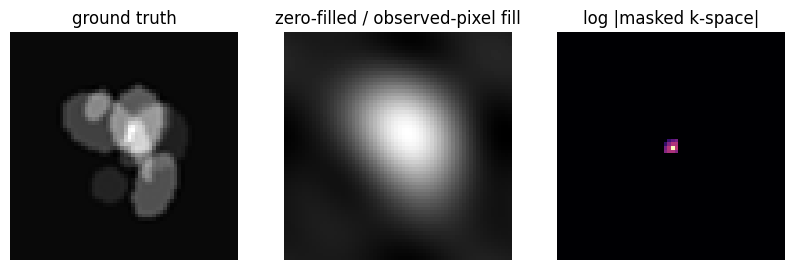

In [12]:
# Choose a target slice from validation data.
x_true = val_ds[min(3, len(val_ds) - 1)][None].to(DEVICE)  # (1,1,H,W), normalized near [-1,1]

with torch.no_grad():
    y_clean = apply_mri_observation_torch(x_true)[0]

    if LIKELIHOOD_TYPE == "gaussian":
        y_obs = y_clean.clone()
        if ADD_OBS_NOISE:
            y_obs = y_obs + DELTA_OBS * torch.randn_like(y_obs)

    elif LIKELIHOOD_TYPE in {"poisson_direct", "poisson_gaussian"}:
        # For CT, y_clean is the selected line integral A_Ω a(x), while the
        # Poisson mean is N0 exp(-y_clean)+background.  For other Poisson modes,
        # observation_mean_torch applies the configured positive count-rate link.
        if OBS_MODE in CT_OBS_MODES:
            lambda_target = ct_transmission_rate_from_line_integrals_torch(y_clean)
        else:
            lambda_target = poisson_rate_from_z_torch(y_clean)
        if POISSON_SAMPLE_COUNTS:
            y_obs = torch.poisson(lambda_target).to(torch.float32)
        else:
            y_obs = torch.round(lambda_target).to(torch.float32)

    else:
        raise ValueError(f"Unknown LIKELIHOOD_TYPE={LIKELIHOOD_TYPE}")

    # For phase retrieval this is a zero-phase backprojection, not a true inverse.
    x_zf = zero_filled_reconstruction(y_obs)

print("OBS_MODE:", OBS_MODE)
print("LIKELIHOOD_TYPE:", LIKELIHOOD_TYPE)
print("x_true range:", float(x_true.min()), float(x_true.max()))
print("y_clean shape:", tuple(y_clean.shape))
print("y_obs shape:", tuple(y_obs.shape))
print("OBS_DIM:", OBS_DIM)
if OBS_MODE in PHASE_RETRIEVAL_OBS_MODES:
    print("phase-retrieval measurement:", PHASE_RETRIEVAL_MEASUREMENT)
    print("phase-retrieval mask type:", PHASE_RETRIEVAL_MASK_TYPE)
    sign_symmetry_error = torch.max(torch.abs(
        apply_mri_observation_torch(x_true) - apply_mri_observation_torch(-x_true)
    ))
    print("max |H(x_true)-H(-x_true)|:", float(sign_symmetry_error))
if OBS_MODE in CT_OBS_MODES:
    print("CT ray-angle grid:", int(CT_NUM_ANGLES), "x", int(CT_NUM_DETECTORS))
    print("CT mask type:", CT_MASK_TYPE, "observed rays:", OBS_DIM,
          "fraction:", OBS_DIM / float(int(CT_NUM_ANGLES) * int(CT_NUM_DETECTORS)))
    print("CT N0/background:", CT_N0_PHOTONS, CT_BACKGROUND_COUNTS)
    if CT_MASK_TYPE in {"limited_angle", "angular_coverage", "limited", "limited-angle"}:
        print("CT angular coverage degrees:", CT_ANGULAR_COVERAGE_DEGREES,
              "start degrees:", CT_ANGULAR_START_DEGREES)
        print("CT limited-angle observed fraction = coverage/max angle:",
              float(CT_ANGULAR_COVERAGE_DEGREES) / float(CT_ANGLE_MAX_DEGREES))
        print("Note: CT_MASK_FRACTION is ignored for limited_angle; it is used only for vd_poisson/random ray masks.")
    print("CT line-integral mean/min/max:", float(y_clean.mean()), float(y_clean.min()), float(y_clean.max()))
if LIKELIHOOD_TYPE in {"poisson_direct", "poisson_gaussian"}:
    print("lambda_target mean/min/max:", float(lambda_target.mean()), float(lambda_target.min()), float(lambda_target.max()))
    print("y_obs count mean/min/max:", float(y_obs.mean()), float(y_obs.min()), float(y_obs.max()))

if SHOW_PLOTS or SAVE_FIGURES:
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    axes[0].imshow(x_true[0, 0].detach().cpu(), cmap="gray", vmin=-1, vmax=1)
    axes[0].set_title("ground truth")
    axes[1].imshow(x_zf[0, 0].detach().cpu(), cmap="gray")
    axes[1].set_title(
        "zero-phase backprojection"
        if OBS_MODE in PHASE_RETRIEVAL_OBS_MODES
        else ("CT backprojection seed" if OBS_MODE in CT_OBS_MODES else "zero-filled / observed-pixel fill")
    )

    if OBS_MODE in PHASE_RETRIEVAL_OBS_MODES:
        mag_map = phase_retrieval_to_masked_map(y_obs)
        axes[2].imshow(torch.log1p(torch.clamp(mag_map, min=0.0)).detach().cpu(), cmap="magma")
        axes[2].set_title("log observed Fourier magnitude")
    elif OBS_MODE in MRI_OBS_MODES:
        axes[2].imshow(torch.log1p(torch.abs(packed_to_masked_kspace(y_obs))).detach().cpu(), cmap="magma")
        axes[2].set_title("log |masked k-space|")
    elif OBS_MODE in CT_OBS_MODES:
        ct_values_are_counts = LIKELIHOOD_TYPE in {"poisson_direct", "poisson_gaussian"}
        ct_map = ct_masked_sinogram_map_from_vector(y_obs, values_are_counts=ct_values_are_counts)
        axes[2].imshow(ct_map.detach().cpu(), cmap="magma", aspect="auto")
        axes[2].set_title("log observed CT counts" if ct_values_are_counts else "observed CT line integrals")
    else:
        obs_display = zero_filled_reconstruction(y_obs)
        axes[2].imshow(obs_display[0, 0].detach().cpu(), cmap="magma")
        axes[2].set_title("observed pixels display")

    for ax in axes:
        ax.axis("off")
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / "target_and_observation.png", dpi=150, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)


saved low-pass IFFT preview: singlecoil_mri_tuolumne_outputs/mri_lowpass_ifft_previews_4x4_8x8_16x16.png


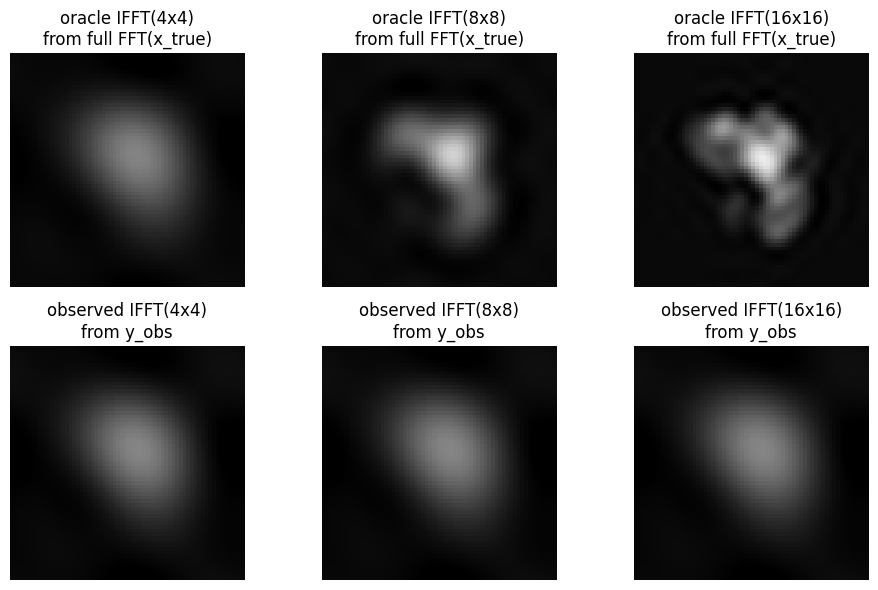

Low-pass IFFT preview sizes: [4, 8, 16]
Active MRI mask is lowpass_square with LOWPASS_SQUARE_SIZE: 4


In [13]:
# ============================================================
# Low-pass IFFT previews for MRI FFT masks
# ============================================================
# Display-only: this does not change the likelihood or baseline samplers.
# For OBS_MODE=mri_fft, it shows low-resolution images formed by keeping only
# centered 4x4, 8x8, and 16x16 k-space squares and then applying inverse FFT.

if OBS_MODE in MRI_OBS_MODES:
    preview_sizes = [int(s) for s in LOWPASS_SQUARE_SIZES]

    with torch.no_grad():
        oracle_lowpass = [lowpass_ifft_reconstruction_from_image(x_true, s) for s in preview_sizes]
        observed_lowpass = [lowpass_ifft_reconstruction_from_observation(y_obs, s) for s in preview_sizes]

    if SHOW_PLOTS or SAVE_FIGURES:
        fig, axes = plt.subplots(2, len(preview_sizes), figsize=(3.2 * len(preview_sizes), 6.0), squeeze=False)

        for j, s in enumerate(preview_sizes):
            axes[0, j].imshow(oracle_lowpass[j][0, 0].detach().cpu().numpy(), cmap="gray", vmin=-1, vmax=1)
            axes[0, j].set_title(f"oracle IFFT({s}x{s})\nfrom full FFT(x_true)")
            axes[0, j].axis("off")

            axes[1, j].imshow(observed_lowpass[j][0, 0].detach().cpu().numpy(), cmap="gray", vmin=-1, vmax=1)
            axes[1, j].set_title(f"observed IFFT({s}x{s})\nfrom y_obs")
            axes[1, j].axis("off")

        plt.tight_layout()
        if SAVE_FIGURES:
            fig.savefig(OUTPUT_DIR / "mri_lowpass_ifft_previews_4x4_8x8_16x16.png", dpi=180, bbox_inches="tight")
            print("saved low-pass IFFT preview:", OUTPUT_DIR / "mri_lowpass_ifft_previews_4x4_8x8_16x16.png")
        if SHOW_PLOTS:
            plt.show()
        else:
            plt.close(fig)

    print("Low-pass IFFT preview sizes:", preview_sizes)
    if MASK_TYPE == "lowpass_square":
        print("Active MRI mask is lowpass_square with LOWPASS_SQUARE_SIZE:", LOWPASS_SQUARE_SIZE)
else:
    print("Low-pass IFFT preview skipped because OBS_MODE is not MRI FFT.")


## 9. Observation reward and gradient

For phase retrieval, the Gaussian reward is
\[
r(x)=-\frac{1}{2\delta^2}\|H_\varepsilon(x)-y\|_2^2,
\qquad
H_\varepsilon(x)=\sqrt{|\mathcal F_{2D}x|^2+\varepsilon_{\rm PR}^2}.
\]
PyTorch automatic differentiation propagates through the FFT and smooth magnitude. The same reward gradient is used both by the first-order multiscale likelihood decomposition and by the exact-log-likelihood DPS baseline.

In [14]:
def reward_mri(x: torch.Tensor) -> torch.Tensor:
    """Current log-likelihood/reward r(x)=log p(y_obs | x).

    Name kept as reward_mri for compatibility. It now supports both:
      - Gaussian: y | x ~ N(h(x), DELTA_OBS^2 I)
      - Poisson direct: y_j | x ~ Poisson(lambda_j(x))
      - Poisson-Gaussian: weighted quadratic approximation to Poisson
    """
    hx = apply_mri_observation_torch(x)

    if LIKELIHOOD_TYPE == "gaussian":
        res = hx - y_obs[None, :]
        quad_per_coord = (res ** 2) / (DELTA_OBS ** 2 + 1e-8)
        quad = quad_per_coord.mean(dim=1) if NORMALIZE_LIKELIHOOD_BY_OBS_DIM else quad_per_coord.sum(dim=1)
        return LIKELIHOOD_STRENGTH * (-0.5 * quad)

    if LIKELIHOOD_TYPE == "poisson_direct":
        # Use the active conditional mean.  For CT, hx is the selected line
        # integral A_Ω a(x), so lambda=N0*exp(-hx)+background.  For the other
        # Poisson modes, hx is the direct observation coordinate and the
        # softplus count-rate link is used.
        lam = (
            ct_transmission_rate_from_line_integrals_torch(hx)
            if OBS_MODE in CT_OBS_MODES
            else poisson_rate_from_z_torch(hx)
        )
        logp_per_coord = y_obs[None, :] * torch.log(lam + 1e-8) - lam
        logp = logp_per_coord.mean(dim=1) if NORMALIZE_LIKELIHOOD_BY_OBS_DIM else logp_per_coord.sum(dim=1)
        return LIKELIHOOD_STRENGTH * logp

    if LIKELIHOOD_TYPE == "poisson_gaussian":
        lam = (
            ct_transmission_rate_from_line_integrals_torch(hx)
            if OBS_MODE in CT_OBS_MODES
            else poisson_rate_from_z_torch(hx)
        )
        var = y_obs[None, :] + POISSON_EPS
        quad_per_coord = (y_obs[None, :] - lam) ** 2 / var
        quad = quad_per_coord.mean(dim=1) if NORMALIZE_LIKELIHOOD_BY_OBS_DIM else quad_per_coord.sum(dim=1)
        return LIKELIHOOD_STRENGTH * (-0.5 * quad)

    raise ValueError(f"Unknown LIKELIHOOD_TYPE={LIKELIHOOD_TYPE}")


@torch.no_grad()
def reward_mri_value_chunked(x: torch.Tensor, chunk_size: int = REWARD_EVAL_CHUNK_SIZE) -> torch.Tensor:
    vals = []
    for xs in x.split(chunk_size, dim=0):
        vals.append(reward_mri(xs))
    return torch.cat(vals, dim=0)


def reward_and_grad_mri(x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    x_req = x.detach().clone().requires_grad_(True)
    r = reward_mri(x_req)
    g = torch.autograd.grad(r.sum(), x_req, create_graph=False, retain_graph=False)[0]
    return r.detach(), g.detach()


# Sanity check reward and gradient.
rt, gt = reward_and_grad_mri(x_true)
print("reward at ground truth:", float(rt.item()), "grad norm:", float(gt.flatten().norm()))
print("active OBS_MODE:", OBS_MODE)
print("active LIKELIHOOD_TYPE:", LIKELIHOOD_TYPE)
print("OBS_DIM:", OBS_DIM, "NORMALIZE_LIKELIHOOD_BY_OBS_DIM:", NORMALIZE_LIKELIHOOD_BY_OBS_DIM)


# Phase-retrieval-specific autodiff sanity check.
if OBS_MODE in PHASE_RETRIEVAL_OBS_MODES or OBS_MODE in CT_OBS_MODES:
    direction = torch.randn_like(x_true)
    direction = direction / (torch.linalg.vector_norm(direction) + 1e-12)
    eps_fd = 1e-3
    with torch.no_grad():
        fd = (reward_mri(x_true + eps_fd * direction) - reward_mri(x_true - eps_fd * direction)) / (2.0 * eps_fd)
    ad = torch.sum(gt * direction)
    rel = torch.abs(fd.reshape(()) - ad) / (torch.abs(fd.reshape(())) + torch.abs(ad) + 1e-8)
    print(f"{OBS_MODE} finite-difference directional derivative:", float(fd.item()))
    print(f"{OBS_MODE} autodiff directional derivative:", float(ad.item()))
    print(f"{OBS_MODE} directional-gradient relative error:", float(rel.item()))


reward at ground truth: -19.874998092651367 grad norm: 22.930458068847656
active OBS_MODE: mri_fft
active LIKELIHOOD_TYPE: gaussian
OBS_DIM: 32 NORMALIZE_LIKELIHOOD_BY_OBS_DIM: False


ACTIVE MASK SUMMARY
active_mask_name: OBS_MASK
OBS_MODE: mri_fft
MASK_TYPE: lowpass_square
PHASE_RETRIEVAL_MASK_TYPE: block
mask shape: (64, 64)
observed Fourier/k-space points: 16 / 4096
observed fraction: 0.00390625
effective acceleration: 256.0
OBS_DIM: 32
Note: for OBS_MODE='mri_fft', OBS_DIM = 2 * observed k-space points because real and imaginary parts are packed.
BLOCK_MASK_BLOCK_SIZE: 4
BLOCK_MASK_NUM_BLOCKS: 4
BLOCK_MASK_GAP: 4

FULL MASK ARRAY: 1 = observed, 0 = masked
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

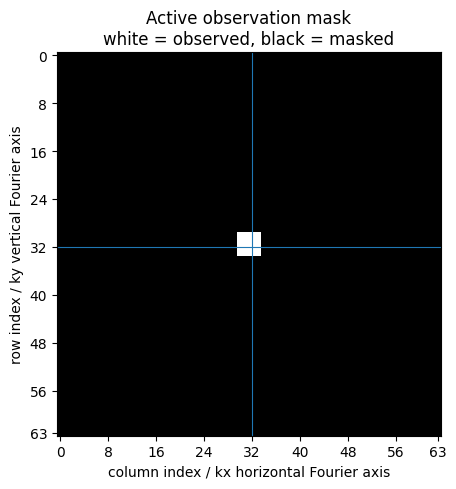

In [15]:
# ============================================================
# Print / visualize the active observation mask
# ============================================================
# White / 1 / True  = observed
# Black / 0 / False = masked out

PRINT_FULL_MASK_ARRAY = env_bool("PRINT_FULL_MASK_ARRAY", True) if "env_bool" in globals() else True
PRINT_ASCII_MASK = env_bool("PRINT_ASCII_MASK", True) if "env_bool" in globals() else True
PRINT_MASK_COORDS = env_bool("PRINT_MASK_COORDS", True) if "env_bool" in globals() else True
MAX_COORDS_TO_PRINT = env_int("MAX_COORDS_TO_PRINT", 80) if "env_int" in globals() else 80

def _mask_to_numpy(mask):
    if isinstance(mask, torch.Tensor):
        mask_np = mask.detach().cpu().numpy()
    else:
        mask_np = np.asarray(mask)
    mask_np = np.squeeze(mask_np)
    if mask_np.ndim != 2:
        raise ValueError(f"Expected a 2D mask, got shape {mask_np.shape}")
    return mask_np.astype(bool)

# Pick the active mask.
# In your notebook, OBS_MASK is set equal to the active MRI / phase-retrieval / inpainting mask.
if "OBS_MASK" in globals() and OBS_MASK is not None:
    active_mask_name = "OBS_MASK"
    active_mask = OBS_MASK
elif "MRI_MASK" in globals() and MRI_MASK is not None:
    active_mask_name = "MRI_MASK"
    active_mask = MRI_MASK
elif "PHASE_RETRIEVAL_MASK" in globals() and PHASE_RETRIEVAL_MASK is not None:
    active_mask_name = "PHASE_RETRIEVAL_MASK"
    active_mask = PHASE_RETRIEVAL_MASK
else:
    raise NameError("Could not find OBS_MASK, MRI_MASK, or PHASE_RETRIEVAL_MASK. Run the mask-construction cell first.")

mask_np = _mask_to_numpy(active_mask)
H, W = mask_np.shape
num_observed = int(mask_np.sum())
num_total = int(mask_np.size)
observed_fraction = num_observed / float(num_total)

print("=" * 70)
print("ACTIVE MASK SUMMARY")
print("=" * 70)
print("active_mask_name:", active_mask_name)
print("OBS_MODE:", globals().get("OBS_MODE", None))
print("MASK_TYPE:", globals().get("MASK_TYPE", None))
print("PHASE_RETRIEVAL_MASK_TYPE:", globals().get("PHASE_RETRIEVAL_MASK_TYPE", None))
print("mask shape:", mask_np.shape)
print("observed Fourier/k-space points:", num_observed, "/", num_total)
print("observed fraction:", observed_fraction)
print("effective acceleration:", num_total / max(num_observed, 1))

if "OBS_DIM" in globals():
    print("OBS_DIM:", OBS_DIM)
    if globals().get("OBS_MODE", None) == "mri_fft":
        print("Note: for OBS_MODE='mri_fft', OBS_DIM = 2 * observed k-space points because real and imaginary parts are packed.")
    elif str(globals().get("OBS_MODE", "")).lower() in {"phase_retrieval", "fft_phase_retrieval", "fourier_magnitude"}:
        print("Note: for phase retrieval, OBS_DIM = observed Fourier magnitudes, so it is not doubled.")

if str(globals().get("MASK_TYPE", "")).lower() in {"block", "blocks", "block_mask", "block_grid"} or \
   str(globals().get("PHASE_RETRIEVAL_MASK_TYPE", "")).lower() in {"block", "blocks", "block_mask", "block_grid"}:
    print("BLOCK_MASK_BLOCK_SIZE:", globals().get("BLOCK_MASK_BLOCK_SIZE", None))
    print("BLOCK_MASK_NUM_BLOCKS:", globals().get("BLOCK_MASK_NUM_BLOCKS", None))
    print("BLOCK_MASK_GAP:", globals().get("BLOCK_MASK_GAP", None))

print()

# Print the full 0/1 mask array.
if PRINT_FULL_MASK_ARRAY:
    print("=" * 70)
    print("FULL MASK ARRAY: 1 = observed, 0 = masked")
    print("=" * 70)
    np.set_printoptions(threshold=np.inf, linewidth=200)
    print(mask_np.astype(np.int8))
    print()

# Print an ASCII version that is often easier to visually inspect in logs.
if PRINT_ASCII_MASK:
    print("=" * 70)
    print("ASCII MASK: # = observed, . = masked")
    print("=" * 70)
    for row in mask_np:
        print("".join("#" if v else "." for v in row))
    print()

# Print observed coordinate list.
# Coordinates are shown both as image indices (row, col) and centered Fourier indices (ky, kx).
# In centered k-space:
#   row axis    = ky, vertical Fourier axis
#   column axis = kx, horizontal Fourier axis
coords_rc = np.argwhere(mask_np)
coords_kykx = coords_rc - np.array([H // 2, W // 2])[None, :]

if PRINT_MASK_COORDS:
    print("=" * 70)
    print(f"OBSERVED COORDINATES: showing first {min(MAX_COORDS_TO_PRINT, len(coords_rc))} of {len(coords_rc)}")
    print("Format: row, col, centered_row_or_ky, centered_col_or_kx")
    print("=" * 70)
    for (r, c), (ky, kx) in zip(coords_rc[:MAX_COORDS_TO_PRINT], coords_kykx[:MAX_COORDS_TO_PRINT]):
        print(f"row={int(r):3d}, col={int(c):3d}, ky={int(ky):4d}, kx={int(kx):4d}")
    if len(coords_rc) > MAX_COORDS_TO_PRINT:
        print(f"... skipped {len(coords_rc) - MAX_COORDS_TO_PRINT} more observed coordinates")
    print()

# Detect connected observed rectangles. For the block mask, these should be your 4x4 blocks.
def _connected_components_rectangles(binary_mask):
    visited = np.zeros_like(binary_mask, dtype=bool)
    rectangles = []
    H_, W_ = binary_mask.shape

    for r0, c0 in np.argwhere(binary_mask):
        if visited[r0, c0]:
            continue

        stack = [(int(r0), int(c0))]
        visited[r0, c0] = True
        pixels = []

        while stack:
            r, c = stack.pop()
            pixels.append((r, c))
            for rr, cc in ((r - 1, c), (r + 1, c), (r, c - 1), (r, c + 1)):
                if 0 <= rr < H_ and 0 <= cc < W_ and binary_mask[rr, cc] and not visited[rr, cc]:
                    visited[rr, cc] = True
                    stack.append((rr, cc))

        rows = [p[0] for p in pixels]
        cols = [p[1] for p in pixels]
        rectangles.append({
            "row_start": int(min(rows)),
            "row_stop_exclusive": int(max(rows) + 1),
            "col_start": int(min(cols)),
            "col_stop_exclusive": int(max(cols) + 1),
            "height": int(max(rows) - min(rows) + 1),
            "width": int(max(cols) - min(cols) + 1),
            "num_pixels": int(len(pixels)),
        })

    rectangles.sort(key=lambda d: ((d["row_start"] + d["row_stop_exclusive"]) / 2,
                                   (d["col_start"] + d["col_stop_exclusive"]) / 2))
    return rectangles

rectangles = _connected_components_rectangles(mask_np)
print("=" * 70)
print("CONNECTED OBSERVED REGIONS")
print("=" * 70)
print("number of connected observed regions:", len(rectangles))
for i, rect in enumerate(rectangles[:50]):
    print(
        f"region {i:02d}: "
        f"rows [{rect['row_start']}, {rect['row_stop_exclusive']}), "
        f"cols [{rect['col_start']}, {rect['col_stop_exclusive']}), "
        f"size {rect['height']}x{rect['width']}, "
        f"pixels={rect['num_pixels']}"
    )
if len(rectangles) > 50:
    print(f"... skipped {len(rectangles) - 50} more connected regions")
print()

# Save numeric mask and coordinates.
mask_csv_path = OUTPUT_DIR / "active_observation_mask_0_1.csv"
coords_csv_path = OUTPUT_DIR / "active_observation_mask_observed_coords.csv"
np.savetxt(mask_csv_path, mask_np.astype(np.int8), fmt="%d", delimiter=",")
np.savetxt(
    coords_csv_path,
    np.column_stack([coords_rc, coords_kykx]).astype(int),
    fmt="%d",
    delimiter=",",
    header="row,col,ky_centered,kx_centered",
    comments="",
)
print("Saved 0/1 mask CSV to:", mask_csv_path)
print("Saved observed coordinate CSV to:", coords_csv_path)

# Plot with Fourier-axis labels.
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(mask_np.astype(float), cmap="gray", interpolation="nearest", origin="upper")
ax.set_title(("Spatial projection mask" if OBS_MODE in globals().get("SPATIAL_PROJECTION_OBS_MODES", set()) else "Active observation mask") + "\nwhite = observed, black = masked")
ax.set_xlabel("column index" + (" / kx horizontal Fourier axis" if OBS_MODE not in globals().get("SPATIAL_PROJECTION_OBS_MODES", set()) else " / spatial x-axis"))
ax.set_ylabel("row index" + (" / ky vertical Fourier axis" if OBS_MODE not in globals().get("SPATIAL_PROJECTION_OBS_MODES", set()) else " / spatial y-axis"))

# Mark center lines for centered Fourier grid.
ax.axhline(H // 2, linewidth=0.8)
ax.axvline(W // 2, linewidth=0.8)

# Use a few ticks so the axes are readable.
tick_step = max(1, H // 8)
ax.set_xticks(list(range(0, W, tick_step)) + ([W - 1] if (W - 1) % tick_step != 0 else []))
ax.set_yticks(list(range(0, H, tick_step)) + ([H - 1] if (H - 1) % tick_step != 0 else []))

fig.tight_layout()

mask_png_path = OUTPUT_DIR / "active_observation_mask.png"
if SAVE_FIGURES:
    fig.savefig(mask_png_path, dpi=200, bbox_inches="tight")
    print("Saved mask PNG to:", mask_png_path)

if SHOW_PLOTS:
    plt.show()
else:
    plt.close(fig)

## 12A. Diffusion Posterior Sampling (DPS) baseline

DPS uses the same unconditional score model but guides each reverse-SDE trajectory through a Tweedie estimate of the clean image. In phase-retrieval mode, the exact-log-likelihood objective differentiates the Gaussian Fourier-magnitude residual through the nonlinear observation map. This is an independent-trajectory baseline: it has no branch/kill step and no ESS.

DPS (exact_loglik, scale=0.5): 100%|██████████| 240/240 [00:36<00:00,  6.56it/s]


DPS time 36.6 sec
DPS samples: (256, 1, 64, 64)
DPS finite: True


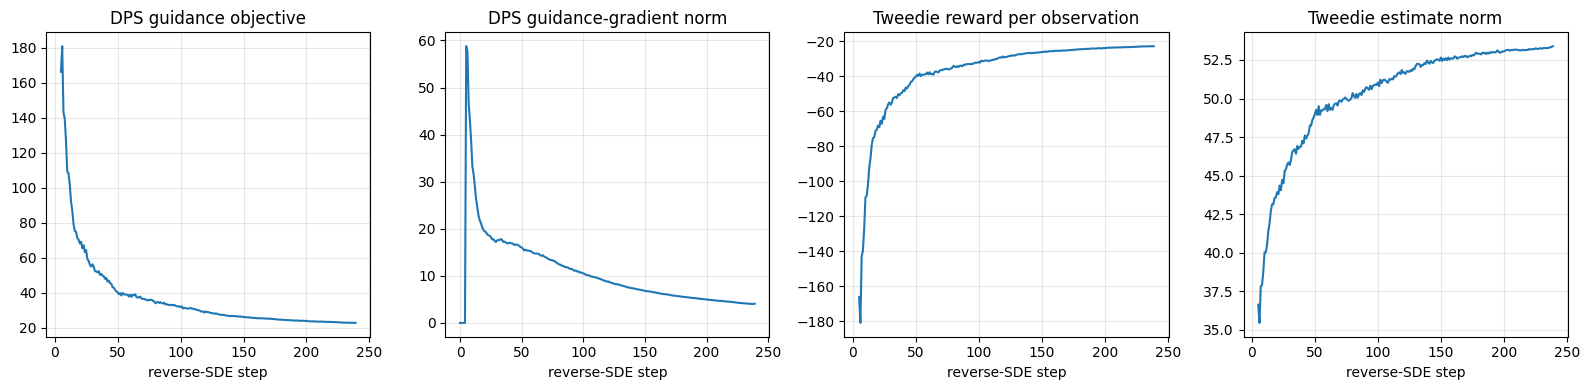

In [16]:
# ============================================================
# PyTorch/ROCm DPS baseline for image observations
# ============================================================
from contextlib import contextmanager


@contextmanager
def temporarily_freeze_parameters(module):
    """Disable parameter gradients while retaining gradients with respect to the image state."""
    flags = [p.requires_grad for p in module.parameters()]
    try:
        for p in module.parameters():
            p.requires_grad_(False)
        yield
    finally:
        for p, flag in zip(module.parameters(), flags):
            p.requires_grad_(flag)


def dps_time_batch(t, x):
    t_scalar = torch.as_tensor(t, device=x.device, dtype=x.dtype)
    tau = torch.clamp(1.0 - t_scalar, min=DSM_T_MIN, max=DSM_T_MAX)
    return torch.full((x.shape[0],), float(tau.detach().cpu()), device=x.device, dtype=x.dtype)


def dps_tweedie_x0_torch(model, t, x):
    """Tweedie clean-image estimate for x_tau=(1-tau)x0+sqrt(tau(2-tau)) eps.

    Reverse time is t=1-tau, hence alpha=t and sigma^2=1-t^2.
    """
    t_scalar = torch.as_tensor(t, device=x.device, dtype=x.dtype)
    t_safe = torch.clamp(t_scalar, min=float(T0), max=float(T1))
    tau_batch = dps_time_batch(t_safe, x)
    score = model(x, tau_batch)
    sigma2 = torch.clamp(1.0 - t_safe ** 2, min=float(DPS_EPS))
    x0_hat = (x + sigma2 * score) / torch.clamp(t_safe, min=float(DPS_EPS))
    if DPS_X0_CLIP is not None:
        x0_hat = torch.clamp(x0_hat, -float(DPS_X0_CLIP), float(DPS_X0_CLIP))
    return x0_hat, score


def dps_loss_per_sample_torch(x0_hat):
    """DPS conditioning objective for one clean-image estimate per trajectory."""
    if DPS_OBJECTIVE == "exact_loglik":
        loss = -reward_mri(x0_hat)
        if DPS_NORMALIZE_GUIDANCE_BY_OBS_DIM and not NORMALIZE_LIKELIHOOD_BY_OBS_DIM:
            loss = loss / float(OBS_DIM)
        return loss

    if DPS_OBJECTIVE == "repo_l2":
        pred_mean = observation_mean_torch(x0_hat)
        residual = pred_mean - y_obs[None, :]
        # Root-mean-square residual gives a dimension-stable analogue of the released DPS norm.
        return torch.sqrt(torch.mean(residual ** 2, dim=1) + float(DPS_EPS))

    raise ValueError(f"Unknown DPS_OBJECTIVE={DPS_OBJECTIVE}; use exact_loglik or repo_l2")


def clip_dps_gradient_torch(grad):
    raw_norms = torch.linalg.vector_norm(grad.flatten(1), dim=1)
    if DPS_GRAD_CLIP_NORM is None:
        return grad, raw_norms
    scale = torch.clamp(float(DPS_GRAD_CLIP_NORM) / (raw_norms + float(DPS_EPS)), max=1.0)
    return grad * scale.view(-1, 1, 1, 1), raw_norms


def dps_guidance_chunk_torch(model, t, x_chunk):
    """Compute DPS guidance for one sample chunk.

    Compatibility/speed note:
    For exact_loglik, the old notebook recomputed reward_mri(x0_hat) after
    already using -reward_mri(x0_hat) as the loss.  For CT Radon this doubled
    the expensive projector/autograd cost.  Here exact_reward is recovered
    algebraically from loss_per_sample, and the score used for Tweedie is
    returned so the prior proposal can reuse it instead of doing a second
    unconditional U-Net forward pass.
    """
    x_req = x_chunk.detach().clone().requires_grad_(True)
    with torch.enable_grad():
        x0_hat, score = dps_tweedie_x0_torch(model, t, x_req)
        loss_per_sample = dps_loss_per_sample_torch(x0_hat)
        grad = torch.autograd.grad(loss_per_sample.sum(), x_req, create_graph=False, retain_graph=False)[0]

    grad = torch.nan_to_num(grad.detach(), nan=0.0, posinf=0.0, neginf=0.0)
    grad, raw_grad_norms = clip_dps_gradient_torch(grad)
    with torch.no_grad():
        if DPS_OBJECTIVE == "exact_loglik":
            if DPS_NORMALIZE_GUIDANCE_BY_OBS_DIM and not NORMALIZE_LIKELIHOOD_BY_OBS_DIM:
                exact_reward = -loss_per_sample.detach() * float(OBS_DIM)
            else:
                exact_reward = -loss_per_sample.detach()
        else:
            # Avoid an extra full CT forward pass for tracing in repo_l2 mode.
            exact_reward = torch.full_like(loss_per_sample.detach(), float("nan"))
        x0_norm = torch.linalg.vector_norm(x0_hat.detach().flatten(1), dim=1)
    return {
        "grad": grad,
        "score": score.detach(),
        "loss_per_sample": loss_per_sample.detach(),
        "raw_grad_norms": raw_grad_norms.detach(),
        "exact_reward": exact_reward.detach(),
        "x0_norm": x0_norm.detach(),
    }


@torch.no_grad()
def dps_prior_proposal_from_score_torch(x, t, dt, noise, score):
    """Prior proposal using an already-computed score tensor."""
    t_scalar = torch.as_tensor(t, device=x.device, dtype=x.dtype)
    t_safe = torch.clamp(t_scalar, min=1e-6)
    drift = (x + 2.0 * score) / t_safe
    diffusion = torch.sqrt(2.0 / t_safe)
    return x + float(dt) * drift + math.sqrt(float(dt)) * diffusion * noise


@torch.no_grad()
def dps_prior_proposal_chunk_torch(model, x, t, dt, noise):
    t_scalar = torch.as_tensor(t, device=x.device, dtype=x.dtype)
    t_safe = torch.clamp(t_scalar, min=1e-6)
    tau_batch = dps_time_batch(t_safe, x)
    score = model(x, tau_batch)
    drift = (x + 2.0 * score) / t_safe
    diffusion = torch.sqrt(2.0 / t_safe)
    return x + float(dt) * drift + math.sqrt(float(dt)) * diffusion * noise


def run_dps_baseline_torch(
    model,
    seed=DPS_SEED,
    num_samples=DPS_NUM_SAMPLES,
    n_steps=DPS_N_STEPS,
    guidance_scale=DPS_GUIDANCE_SCALE,
    t0=T0,
    t1=T1,
    chunk_size=DPS_CHUNK_SIZE,
):
    """Run independent DPS reverse-SDE trajectories in memory-safe chunks."""
    model.eval()
    num_samples = int(num_samples)
    n_steps = int(n_steps)
    chunk_size = num_samples if chunk_size is None else max(1, int(chunk_size))

    x = randn_seeded((num_samples, 1, IMG_SIZE, IMG_SIZE), seed=seed, device=DEVICE)
    ts = torch.linspace(float(t0), float(t1), n_steps + 1, device=DEVICE, dtype=x.dtype)
    dt = float(t1 - t0) / float(n_steps)
    noise_gen = make_generator(seed + 1, DEVICE)

    loss_trace = []
    grad_norm_trace = []
    mean_reward_trace = []
    mean_reward_per_obs_trace = []
    x0_norm_trace = []

    with temporarily_freeze_parameters(model):
        progress = tqdm(range(n_steps), desc=f"DPS ({DPS_OBJECTIVE}, scale={guidance_scale:g})")
        for k in progress:
            t = ts[k]
            active = float(t.detach().cpu()) >= float(DPS_GUIDANCE_START_T) and float(guidance_scale) > 0.0

            next_chunks = []
            weighted_loss = 0.0
            weighted_grad_norm = 0.0
            weighted_reward = 0.0
            weighted_x0_norm = 0.0
            total_count = 0

            for start in range(0, num_samples, chunk_size):
                end = min(start + chunk_size, num_samples)
                xc = x[start:end]
                noise = torch.randn(xc.shape, device=DEVICE, dtype=xc.dtype, generator=noise_gen)

                if active:
                    stats = dps_guidance_chunk_torch(model, t, xc)
                    # Reuse the score already computed inside dps_guidance_chunk_torch.
                    proposal = dps_prior_proposal_from_score_torch(xc, t, dt, noise, stats["score"])
                    step_scale = float(guidance_scale) * (dt if DPS_SCALE_WITH_DT else 1.0)
                    xn = proposal - step_scale * stats["grad"]
                    count = end - start
                    weighted_loss += float(stats["loss_per_sample"].sum().detach().cpu())
                    weighted_grad_norm += float(stats["raw_grad_norms"].sum().detach().cpu())
                    weighted_reward += float(torch.nan_to_num(stats["exact_reward"], nan=0.0).sum().detach().cpu())
                    weighted_x0_norm += float(stats["x0_norm"].sum().detach().cpu())
                    total_count += count
                else:
                    proposal = dps_prior_proposal_chunk_torch(model, xc, t, dt, noise)
                    xn = proposal

                if DPS_SAMPLE_CLIP is not None:
                    xn = torch.clamp(xn, -float(DPS_SAMPLE_CLIP), float(DPS_SAMPLE_CLIP))
                next_chunks.append(xn.detach())

            x = torch.cat(next_chunks, dim=0)

            if active and total_count > 0:
                mean_loss = weighted_loss / total_count
                mean_grad = weighted_grad_norm / total_count
                mean_reward = weighted_reward / total_count
                mean_x0_norm = weighted_x0_norm / total_count
            else:
                mean_loss = float("nan")
                mean_grad = 0.0
                mean_reward = float("nan")
                mean_x0_norm = float("nan")

            loss_trace.append(mean_loss)
            grad_norm_trace.append(mean_grad)
            mean_reward_trace.append(mean_reward)
            mean_reward_per_obs_trace.append(mean_reward / float(OBS_DIM) if np.isfinite(mean_reward) else float("nan"))
            x0_norm_trace.append(mean_x0_norm)

            if (k + 1) % 50 == 0:
                clear_device_cache()

    sync_device()
    return {
        "samples": x.detach(),
        "loss_trace": np.asarray(loss_trace, dtype=np.float64),
        "grad_norm_trace": np.asarray(grad_norm_trace, dtype=np.float64),
        "mean_reward_trace": np.asarray(mean_reward_trace, dtype=np.float64),
        "mean_reward_per_obs_trace": np.asarray(mean_reward_per_obs_trace, dtype=np.float64),
        "x0_norm_trace": np.asarray(x0_norm_trace, dtype=np.float64),
        "guidance_scale": float(guidance_scale),
        "n_steps": int(n_steps),
        "seed": int(seed),
    }


if RUN_DPS:
    t_dps = time.time()
    dps_out = run_dps_baseline_torch(score_model)
    dps_samples = dps_out["samples"]
    with torch.no_grad():
        dps_mean = dps_samples.mean(dim=0, keepdim=True)
        dps_rewards = reward_mri_value_chunked(dps_samples)
        dps_map = dps_samples[int(torch.argmax(dps_rewards).item())][None]
    sync_device()
    print("DPS time %.1f sec" % (time.time() - t_dps))
    print("DPS samples:", tuple(dps_samples.shape))
    print("DPS finite:", bool(torch.isfinite(dps_samples).all()))

    if SHOW_PLOTS or SAVE_FIGURES:
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        axes[0].plot(dps_out["loss_trace"])
        axes[0].set_title("DPS guidance objective")
        axes[0].set_xlabel("reverse-SDE step")
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(dps_out["grad_norm_trace"])
        axes[1].set_title("DPS guidance-gradient norm")
        axes[1].set_xlabel("reverse-SDE step")
        axes[1].grid(True, alpha=0.3)

        axes[2].plot(dps_out["mean_reward_per_obs_trace"])
        axes[2].set_title("Tweedie reward per observation")
        axes[2].set_xlabel("reverse-SDE step")
        axes[2].grid(True, alpha=0.3)

        axes[3].plot(dps_out["x0_norm_trace"])
        axes[3].set_title("Tweedie estimate norm")
        axes[3].set_xlabel("reverse-SDE step")
        axes[3].grid(True, alpha=0.3)

        plt.tight_layout()
        if SAVE_FIGURES:
            fig.savefig(OUTPUT_DIR / "dps_guidance_diagnostics.png", dpi=160, bbox_inches="tight")
        if SHOW_PLOTS:
            plt.show()
        else:
            plt.close(fig)
else:
    dps_out = None
    dps_samples = None
    dps_mean = None
    dps_map = None
    print("RUN_DPS=False; DPS baseline skipped.")



## 12B-Outline. How the conditional DOLCE baseline is trained

The DOLCE-style baseline is **separate from SMC**. It does not use the SMC particles, tail statistics, likelihood increments, or branch/kill selection.

The conditional score model learns

\[
s_\theta(x_t,t;c)\approx \nabla_{x_t}\log p_t(x_t\mid c),
\]

where \(c=C(y)\) is a deterministic condition built from the degraded observation.

### Training data generation

For each clean training image \(x_0\):

1. Generate the observation
   \[
   y=H(x_0)+\varepsilon
   \]
   for Gaussian FFT/phase-retrieval modes, or Poisson counts for Poisson random-inpainting.
2. Build the conditioning image/tensor \(c=C(y)\).
   - Phase retrieval: zero-phase backprojection, log Fourier-magnitude map, and mask map.
   - FFT/MRI: zero-filled inverse FFT image, k-space magnitude/map, and mask map.
   - Random inpainting: observed-pixel fill and mask map.
3. Sample a diffusion time \(t\) and noise \(\xi\).
4. Form the noised clean image
   \[
   x_t=\alpha_t x_0+\sigma_t\xi.
   \]
5. Train by denoising score matching:
   \[
   \min_\theta
   \mathbb E\left[
   \left\|
   s_\theta(x_t,t;c)+\frac{\xi}{\sigma_t}
   \right\|^2
   \right].
   \]

### Sampling

At test time, fix the observed target \(y_{\rm obs}\), compute \(c=C(y_{\rm obs})\), and run a conditional reverse diffusion using \(s_\theta(x_t,t;c)\). Optionally, a DOLCE-style proximal data-consistency correction is applied after each reverse step.

Use separate `DOLCE_CHECKPOINT_PATH`s for different observation modes and mask/noise settings.



## 12B. Conditional DOLCE baseline, separate from SMC

This section trains a **task-specific conditional score model** as a DOLCE-style baseline. It is not used by the multiscale SMC sampler and does not use SMC tail statistics, particles, or branch/kill weights.

For each clean training image \(x_0\), we synthesize an observation \(y=H(x_0)+\epsilon\) using the active observation model. The default condition is now a **one-channel RLS reconstruction**
\[
c_{\mathrm{RLS}}(y)
\approx
\arg\min_u
\Big\{
\mathcal D(H(u),y)+\lambda R(u)
\Big\},
\]
where \(\mathcal D\) is the data term for the active likelihood and \(R(u)\) is an L2/TV-style regularizer. Then the conditional score model is trained as
\[
s_\theta(x_t,t;c_{\mathrm{RLS}}(y))
\approx
\nabla_{x_t}\log p_t(x_t\mid c_{\mathrm{RLS}}(y)).
\]

This replaces the older three-channel condition
\[
[\text{zero-filled/zero-phase seed},\ \text{observation map},\ \text{mask}]
\]
with a DOLCE-style reconstruction condition. Set `DOLCE_CONDITION_MODE=multichannel` to recover the previous behavior.

For phase retrieval, the RLS condition is nonlinear because \(H(u)=P_\Omega|\mathcal F u|\); the notebook computes it by differentiating through the FFT and the smooth amplitude map. This is more expensive than the three-channel condition, so it is best used with checkpointed DOLCE training.


DOLCE conditional baseline configuration
  RUN_DOLCE_BASELINE: True
  DOLCE_NUM_TRAIN_STEPS: 10000
  DOLCE_NUM_SAMPLES: 256
  DOLCE_TRAIN_BATCH_SIZE: 2
  DOLCE_N_STEPS: 240
  DOLCE_USE_PROX: True
  DOLCE_PROX_STEPS: 1
  DOLCE_CHUNK_SIZE: 16
  DOLCE_CONDITION_MODE: rls
  DOLCE_RLS_STEPS: 20
  DOLCE_RLS_LR: 0.08
  DOLCE_RLS_LAMBDA: 0.001
  DOLCE_RLS_REGULARIZER: tv_l2
  DOLCE_RLS_INIT: seed
  DOLCE_TRAIN_ONLY: False
  DOLCE_SAMPLE_ONLY: False
  UNLOAD_PRIOR_BEFORE_DOLCE: False
DOLCE condition channels: 1
DOLCE condition mode: rls
DOLCE conditional score parameters: 0.562945 M
Training DOLCE conditional score model...


DOLCE loss=0.0088: 100%|██████████| 10000/10000 [08:31<00:00, 19.56it/s]


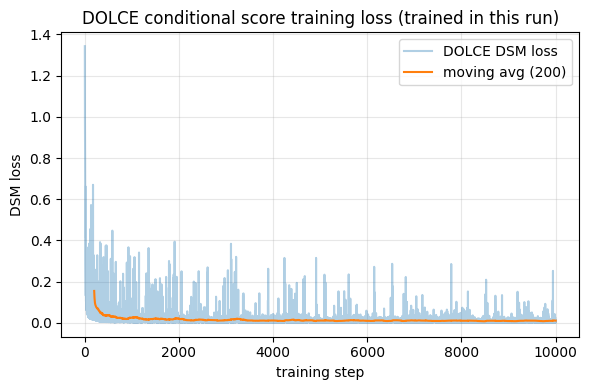

DOLCE conditional sampling time 48.5 sec
DOLCE samples: (256, 1, 64, 64)
DOLCE mean reward per obs: -2.690093755722046


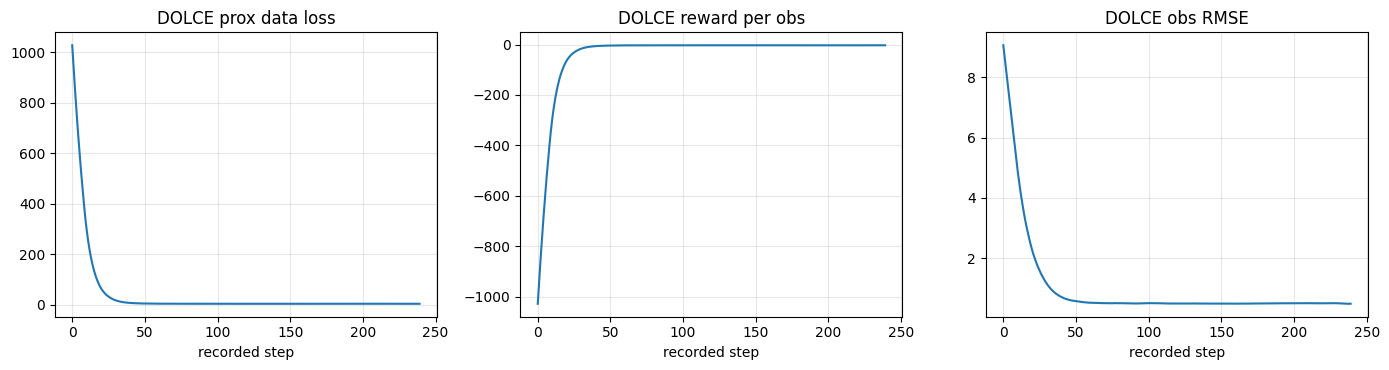

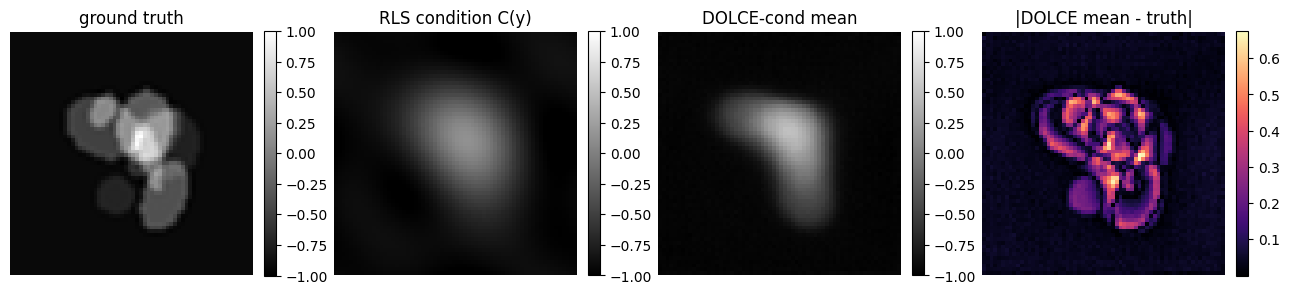

In [17]:

# ============================================================
# Conditional DOLCE baseline: train s_theta(x_t,t; c) and sample from it
# This is a standalone baseline and is not used by SMC.
# ============================================================

# -----------------------------
# DOLCE baseline configuration
# -----------------------------
RUN_DOLCE_BASELINE = env_bool("RUN_DOLCE_BASELINE", True)

# For a fully trained conditional baseline, use a comparable budget to NUM_TRAIN_STEPS.
# For smoke tests, override with DOLCE_NUM_TRAIN_STEPS=1.
DOLCE_NUM_TRAIN_STEPS = env_int("DOLCE_NUM_TRAIN_STEPS", 10000)  # conditional-score training budget; independent of prior NUM_TRAIN_STEPS
DOLCE_LR = env_float("DOLCE_LR", float(LR))
DOLCE_WEIGHT_DECAY = env_float("DOLCE_WEIGHT_DECAY", 1e-4)
DOLCE_TRAIN_BATCH_SIZE = env_int("DOLCE_TRAIN_BATCH_SIZE", min(int(BATCH_SIZE), 2))  # memory-safe CT/RLS training batch

DOLCE_NUM_SAMPLES = env_int("DOLCE_NUM_SAMPLES", int(N_PARTICLES))
DOLCE_N_STEPS = env_int("DOLCE_N_STEPS", int(DPS_N_STEPS if "DPS_N_STEPS" in globals() else N_STEPS_BASELINE))
DOLCE_SEED = env_int("DOLCE_SEED", SEED + 87000)

# Generate synthetic observations during conditional-score training.
# Usually this should match the test observation-generation noise model.
DOLCE_TRAIN_ADD_OBS_NOISE = env_bool("DOLCE_TRAIN_ADD_OBS_NOISE", bool(ADD_OBS_NOISE))
DOLCE_TRAIN_SAMPLE_POISSON = env_bool("DOLCE_TRAIN_SAMPLE_POISSON", bool(POISSON_SAMPLE_COUNTS))

# Condition preprocessing.
DOLCE_NORMALIZE_CONDITION = env_bool("DOLCE_NORMALIZE_CONDITION", True)
DOLCE_CONDITION_EPS = env_float("DOLCE_CONDITION_EPS", 1e-6)

# ------------------------------------------------------------
# DOLCE condition mode
# ------------------------------------------------------------
# The paper conditions the diffusion model on a transformed reconstruction
# derived from the measurement.  For this notebook, the default is now a
# one-channel RLS reconstruction
#
#     c_RLS(y) = argmin_u data_loss(H(u), y) + lambda * R(u),
#
# rather than the older three-channel condition
#     [zero-filled/zero-phase seed, observation map, mask].
#
# Set DOLCE_CONDITION_MODE=multichannel to recover the previous behavior.
DOLCE_CONDITION_MODE = env_str("DOLCE_CONDITION_MODE", "rls").strip().lower()
DOLCE_RLS_STEPS = env_int("DOLCE_RLS_STEPS", 20)  # set 40+ for final runs; lower default avoids CT OOM
DOLCE_RLS_LR = env_float("DOLCE_RLS_LR", 0.08)
DOLCE_RLS_LAMBDA = env_float("DOLCE_RLS_LAMBDA", 1e-3)
DOLCE_RLS_REGULARIZER = env_str("DOLCE_RLS_REGULARIZER", "tv_l2").strip().lower()  # none, l2, tv, tv_l2
DOLCE_RLS_INIT = env_str("DOLCE_RLS_INIT", "seed").strip().lower()  # seed, zeros, random
DOLCE_RLS_DATA_NORMALIZE_BY_OBS_DIM = env_bool("DOLCE_RLS_DATA_NORMALIZE_BY_OBS_DIM", True)
DOLCE_RLS_GRAD_CLIP_NORM = None if env_str("DOLCE_RLS_GRAD_CLIP_NORM", "25.0").lower() == "none" else env_float("DOLCE_RLS_GRAD_CLIP_NORM", 25.0)
DOLCE_RLS_CLAMP = None if env_str("DOLCE_RLS_CLAMP", "4.0").lower() == "none" else env_float("DOLCE_RLS_CLAMP", 4.0)
DOLCE_RLS_TV_EPS = env_float("DOLCE_RLS_TV_EPS", 1e-6)

# Optional DOLCE-style proximal data consistency after each conditional reverse-SDE proposal.
DOLCE_USE_PROX = env_bool("DOLCE_USE_PROX", True)
DOLCE_PROX_STEPS = env_int("DOLCE_PROX_STEPS", 1)
DOLCE_PROX_LR = env_float("DOLCE_PROX_LR", 0.10)
DOLCE_PROX_WEIGHT = env_float("DOLCE_PROX_WEIGHT", 1.0)
DOLCE_PROX_NORMALIZE_BY_OBS_DIM = env_bool("DOLCE_PROX_NORMALIZE_BY_OBS_DIM", True)
DOLCE_PROX_GRAD_CLIP_NORM = env_float("DOLCE_PROX_GRAD_CLIP_NORM", 25.0)
DOLCE_SAMPLE_CLAMP = env_float("DOLCE_SAMPLE_CLAMP", float(SAMPLE_CLAMP) if SAMPLE_CLAMP is not None else 8.0)

# Chunking keeps AMD/ROCm memory manageable.
DOLCE_CHUNK_SIZE = env_int("DOLCE_CHUNK_SIZE", min(16, max(1, int(DOLCE_NUM_SAMPLES))))  # small CT-safe default

# Checkpoint for the conditional model, separate from the unconditional prior checkpoint.
DOLCE_LOAD_CHECKPOINT_IF_EXISTS = env_bool("DOLCE_LOAD_CHECKPOINT_IF_EXISTS", bool(LOAD_CHECKPOINT_IF_EXISTS))
DOLCE_SAVE_CHECKPOINT = env_bool("DOLCE_SAVE_CHECKPOINT", bool(SAVE_CHECKPOINT))
# Observation-specific conditional score checkpoint.
# Unlike the unconditional prior and tail statistics, this should generally
# not be reused across different OBS_MODE/mask/noise configurations.
def _dolce_obs_cache_tag() -> str:
    parts = [
        f"obs{OBS_MODE}",
        f"like{LIKELIHOOD_TYPE}",
        f"img{IMG_SIZE}",
        f"delta{DELTA_OBS:g}",
    ]
    if OBS_MODE in PHASE_RETRIEVAL_OBS_MODES:
        parts += [
            f"prmask{PHASE_RETRIEVAL_MASK_TYPE}",
            f"praccel{PHASE_RETRIEVAL_ACCEL}",
            f"prcf{PHASE_RETRIEVAL_CENTER_FRACTION:g}",
            f"prseed{PHASE_RETRIEVAL_MASK_SEED}",
            f"prmeas{PHASE_RETRIEVAL_MEASUREMENT}",
        ]
        if PHASE_RETRIEVAL_MASK_TYPE in {"block", "blocks", "block_grid"}:
            parts += [
                f"blockbs{BLOCK_MASK_BLOCK_SIZE}",
                f"blockn{BLOCK_MASK_NUM_BLOCKS}",
                f"blockgap{BLOCK_MASK_GAP}",
            ]
    elif OBS_MODE in MRI_OBS_MODES:
        parts += [
            f"mask{MASK_TYPE}",
            f"accel{ACCEL}",
            f"cf{CENTER_FRACTION:g}",
            f"seed{MRI_MASK_SEED}",
        ]
        if MASK_TYPE in {"block", "blocks", "block_grid"}:
            parts += [
                f"blockbs{BLOCK_MASK_BLOCK_SIZE}",
                f"blockn{BLOCK_MASK_NUM_BLOCKS}",
                f"blockgap{BLOCK_MASK_GAP}",
            ]
    elif OBS_MODE in SPATIAL_PROJECTION_OBS_MODES:
        parts += [
            f"spmask{SPATIAL_MASK_TYPE}",
            f"spkeep{SPATIAL_KEEP_FRACTION:g}",
            f"spseed{SPATIAL_MASK_SEED}",
        ]
        if SPATIAL_MASK_TYPE in {"block", "blocks", "block_grid"}:
            parts += [
                f"spblockbs{SPATIAL_BLOCK_SIZE}",
                f"spblockn{SPATIAL_NUM_BLOCKS}",
                f"spblockgap{SPATIAL_BLOCK_GAP}",
            ]
    elif OBS_MODE in RANDOM_INPAINT_OBS_MODES:
        parts += [
            f"keep{INPAINT_KEEP_FRACTION:g}",
            f"seed{INPAINT_MASK_SEED}",
        ]
    elif OBS_MODE in CT_OBS_MODES:
        parts += [
            f"ctangles{CT_NUM_ANGLES}",
            f"ctdet{CT_NUM_DETECTORS}",
            f"ctmask{CT_MASK_TYPE}",
            f"ctkeep{CT_MASK_FRACTION:g}",
            f"ctcov{CT_ANGULAR_COVERAGE_DEGREES:g}",
            f"ctstart{CT_ANGULAR_START_DEGREES:g}",
            f"ctsv{CT_SPARSE_VIEW_FRACTION:g}",
            f"ctseed{CT_MASK_SEED}",
            f"ctn0{CT_N0_PHOTONS:g}",
        ]
    parts += [f"cond{DOLCE_CONDITION_MODE}"]
    if DOLCE_CONDITION_MODE in {"rls", "rls_1ch", "rls_one_channel", "regularized_least_squares"}:
        parts += [
            f"rlssteps{DOLCE_RLS_STEPS}",
            f"rlslam{DOLCE_RLS_LAMBDA:g}",
            f"rlsreg{DOLCE_RLS_REGULARIZER}",
        ]

    if str(LIKELIHOOD_TYPE).startswith("poisson"):
        parts += [
            f"plink{POISSON_RATE_LINK}",
            f"pscale{POISSON_RATE_SCALE:g}",
            f"poffset{POISSON_RATE_OFFSET:g}",
        ]
    return "_".join(parts).replace("/", "-")

DOLCE_CHECKPOINT_PATH = pathlib.Path(env_str(
    "DOLCE_CHECKPOINT_PATH",
    str(OUTPUT_DIR / f"dolce_condscore_{_dolce_obs_cache_tag()}.pt"),
)).expanduser()

print("DOLCE conditional baseline configuration")
print("  RUN_DOLCE_BASELINE:", RUN_DOLCE_BASELINE)
print("  DOLCE_NUM_TRAIN_STEPS:", DOLCE_NUM_TRAIN_STEPS)
print("  DOLCE_NUM_SAMPLES:", DOLCE_NUM_SAMPLES)
print("  DOLCE_TRAIN_BATCH_SIZE:", DOLCE_TRAIN_BATCH_SIZE)
print("  DOLCE_N_STEPS:", DOLCE_N_STEPS)
print("  DOLCE_USE_PROX:", DOLCE_USE_PROX)
print("  DOLCE_PROX_STEPS:", DOLCE_PROX_STEPS)
print("  DOLCE_CHUNK_SIZE:", DOLCE_CHUNK_SIZE)
print("  DOLCE_CONDITION_MODE:", DOLCE_CONDITION_MODE)
if DOLCE_CONDITION_MODE in {"rls", "rls_1ch", "rls_one_channel", "regularized_least_squares"}:
    print("  DOLCE_RLS_STEPS:", DOLCE_RLS_STEPS)
    print("  DOLCE_RLS_LR:", DOLCE_RLS_LR)
    print("  DOLCE_RLS_LAMBDA:", DOLCE_RLS_LAMBDA)
    print("  DOLCE_RLS_REGULARIZER:", DOLCE_RLS_REGULARIZER)
    print("  DOLCE_RLS_INIT:", DOLCE_RLS_INIT)
print("  DOLCE_TRAIN_ONLY:", DOLCE_TRAIN_ONLY)
print("  DOLCE_SAMPLE_ONLY:", DOLCE_SAMPLE_ONLY)
print("  UNLOAD_PRIOR_BEFORE_DOLCE:", UNLOAD_PRIOR_BEFORE_DOLCE)

if RUN_DOLCE_BASELINE and UNLOAD_PRIOR_BEFORE_DOLCE:
    print("Moving unconditional score_model to CPU before DOLCE training to free GPU memory.")
    try:
        score_model.to("cpu")
    except Exception as e:
        print("Could not move score_model to CPU:", repr(e))
    clear_device_cache()


# -----------------------------
# Condition construction C(y)
# -----------------------------
@torch.no_grad()
def _batch_phase_retrieval_to_masked_map(y_batch: torch.Tensor) -> torch.Tensor:
    """Scatter batched phase-retrieval observations to full Fourier-magnitude maps."""
    B = int(y_batch.shape[0])
    full = torch.zeros((B, IMG_SIZE, IMG_SIZE), dtype=torch.float32, device=y_batch.device)
    full[:, PHASE_RETRIEVAL_MASK] = y_batch.reshape(B, -1).to(torch.float32)
    return full[:, None]


@torch.no_grad()
def _batch_zero_phase_backprojection(y_batch: torch.Tensor) -> torch.Tensor:
    """Batched zero-phase inverse FFT for phase-retrieval observations."""
    B = int(y_batch.shape[0])
    observed_map = _batch_phase_retrieval_to_masked_map(y_batch)[:, 0]
    if PHASE_RETRIEVAL_MEASUREMENT == "intensity":
        amplitude = torch.sqrt(torch.clamp(observed_map, min=0.0))
    else:
        amplitude = torch.clamp(observed_map, min=0.0)
    k_zero_phase = amplitude.to(torch.complex64)
    x_back = ifft2c_img(k_zero_phase).real
    return x_back[:, None]


@torch.no_grad()
def _batch_packed_to_masked_kspace(y_batch: torch.Tensor) -> torch.Tensor:
    """Batched packed real/imag FFT observations to full masked complex k-space."""
    B = int(y_batch.shape[0])
    M = int(MRI_MASK.sum().item())
    values = (
        inverse_poisson_rate_to_z_torch(y_batch)
        if LIKELIHOOD_TYPE in {"poisson_direct", "poisson_gaussian"}
        else y_batch
    )
    real = values[:, :M]
    imag = values[:, M:2 * M]
    k = torch.zeros((B, IMG_SIZE, IMG_SIZE), dtype=torch.complex64, device=y_batch.device)
    k[:, MRI_MASK] = real.to(torch.float32) + 1j * imag.to(torch.float32)
    return k


@torch.no_grad()
def _batch_zero_filled_reconstruction(y_batch: torch.Tensor) -> torch.Tensor:
    """Batched display/seed reconstruction C(y), compatible with all observation modes."""
    if OBS_MODE in PHASE_RETRIEVAL_OBS_MODES:
        return _batch_zero_phase_backprojection(y_batch)

    if OBS_MODE in MRI_OBS_MODES:
        k = _batch_packed_to_masked_kspace(y_batch)
        x = ifft2c_img(k).real
        return x[:, None]

    if OBS_MODE in SPATIAL_PROJECTION_OBS_MODES:
        B = int(y_batch.shape[0])
        x = torch.zeros((B, 1, IMG_SIZE, IMG_SIZE), dtype=torch.float32, device=y_batch.device)
        flat = x.reshape(B, -1)
        flat[:, OBS_INDICES] = y_batch.to(torch.float32)
        return x

    if OBS_MODE in RANDOM_INPAINT_OBS_MODES:
        values = (
            inverse_poisson_rate_to_z_torch(y_batch)
            if LIKELIHOOD_TYPE in {"poisson_direct", "poisson_gaussian"}
            else y_batch
        )
        B = int(y_batch.shape[0])
        x = torch.zeros((B, 1, IMG_SIZE, IMG_SIZE), dtype=torch.float32, device=y_batch.device)
        flat = x.reshape(B, -1)
        flat[:, OBS_INDICES] = values.to(torch.float32)
        return x

    if OBS_MODE in CT_OBS_MODES:
        # Batch version of simple CT unfiltered backprojection.
        # Gaussian CT observations are line integrals; Poisson CT observations
        # are counts and must first be converted to approximate line integrals.
        if y_batch.ndim == 1:
            y_batch_local = y_batch[None]
        else:
            y_batch_local = y_batch
        imgs = []
        for yy in y_batch_local:
            imgs.append(ct_backprojection_from_measurement(yy))
        return torch.cat(imgs, dim=0)

    raise ValueError(f"Unknown OBS_MODE={OBS_MODE}")


@torch.no_grad()
def _normalize_cond_channels(cond: torch.Tensor) -> torch.Tensor:
    if not DOLCE_NORMALIZE_CONDITION:
        return cond
    mean = cond.mean(dim=(2, 3), keepdim=True)
    std = cond.std(dim=(2, 3), keepdim=True)
    return (cond - mean) / torch.clamp(std, min=float(DOLCE_CONDITION_EPS))


# -----------------------------
# RLS condition c_RLS(y)
# -----------------------------
def _dolce_observation_data_loss_per_sample(u: torch.Tensor, y_batch: torch.Tensor) -> torch.Tensor:
    """Observation data term for RLS condition construction.

    Gaussian:
        0.5 ||H(u)-y||^2 / DELTA_OBS^2

    Poisson:
        sum_j [lambda_j(u) - y_j log lambda_j(u)]
    """
    if y_batch.ndim == 1:
        y_batch = y_batch[None]
    y_batch = y_batch.to(device=u.device, dtype=torch.float32)

    if LIKELIHOOD_TYPE == "gaussian":
        hx = apply_mri_observation_torch(u)
        res = hx - y_batch
        loss = 0.5 * torch.sum(res ** 2, dim=1) / (float(DELTA_OBS) ** 2 + 1e-12)
        if DOLCE_RLS_DATA_NORMALIZE_BY_OBS_DIM:
            loss = loss / float(OBS_DIM)
        return loss

    if LIKELIHOOD_TYPE in {"poisson_direct", "poisson_gaussian"}:
        lam = observation_mean_torch(u)
        loss = torch.sum(lam - y_batch * torch.log(lam + 1e-12), dim=1)
        if DOLCE_RLS_DATA_NORMALIZE_BY_OBS_DIM:
            loss = loss / float(OBS_DIM)
        return loss

    raise ValueError(f"Unknown LIKELIHOOD_TYPE={LIKELIHOOD_TYPE}")


def _dolce_l2_regularizer_per_sample(u: torch.Tensor) -> torch.Tensor:
    return torch.mean(u ** 2, dim=(1, 2, 3))


def _dolce_tv_regularizer_per_sample(u: torch.Tensor) -> torch.Tensor:
    dx = u[:, :, 1:, :] - u[:, :, :-1, :]
    dy = u[:, :, :, 1:] - u[:, :, :, :-1]
    tv_x = torch.sqrt(dx ** 2 + float(DOLCE_RLS_TV_EPS) ** 2).mean(dim=(1, 2, 3))
    tv_y = torch.sqrt(dy ** 2 + float(DOLCE_RLS_TV_EPS) ** 2).mean(dim=(1, 2, 3))
    return tv_x + tv_y


def _dolce_rls_regularizer_per_sample(u: torch.Tensor) -> torch.Tensor:
    mode = str(DOLCE_RLS_REGULARIZER).strip().lower()
    if mode in {"none", "off", "0"}:
        return torch.zeros((u.shape[0],), device=u.device, dtype=u.dtype)
    if mode in {"l2", "ridge"}:
        return _dolce_l2_regularizer_per_sample(u)
    if mode in {"tv", "total_variation"}:
        return _dolce_tv_regularizer_per_sample(u)
    if mode in {"tv_l2", "l2_tv", "tv+l2"}:
        return _dolce_tv_regularizer_per_sample(u) + _dolce_l2_regularizer_per_sample(u)
    raise ValueError(f"Unknown DOLCE_RLS_REGULARIZER={DOLCE_RLS_REGULARIZER}")


def _dolce_make_rls_initialization(y_batch: torch.Tensor) -> torch.Tensor:
    mode = str(DOLCE_RLS_INIT).strip().lower()
    if mode in {"seed", "zf", "zero_filled", "zero_phase"}:
        return _batch_zero_filled_reconstruction(y_batch).detach()
    if mode in {"zeros", "zero"}:
        B = int(y_batch.shape[0])
        return torch.zeros((B, 1, IMG_SIZE, IMG_SIZE), dtype=torch.float32, device=y_batch.device)
    if mode in {"random", "noise"}:
        B = int(y_batch.shape[0])
        return torch.randn((B, 1, IMG_SIZE, IMG_SIZE), dtype=torch.float32, device=y_batch.device)
    raise ValueError(f"Unknown DOLCE_RLS_INIT={DOLCE_RLS_INIT}")


def _batch_rls_reconstruction(y_batch: torch.Tensor) -> torch.Tensor:
    """Compute a one-channel RLS condition image c_RLS(y).

    This solves approximately, by gradient descent,

        min_u data_loss(H(u), y) + DOLCE_RLS_LAMBDA * R(u).

    For phase retrieval, H is nonlinear Fourier magnitude, so this is a
    Wirtinger-flow-like amplitude fitting problem with an image regularizer.
    """
    if y_batch.ndim == 1:
        y_batch = y_batch[None]
    y_batch = y_batch.to(DEVICE).float().detach()

    u = _dolce_make_rls_initialization(y_batch).to(DEVICE).float().detach()

    if int(DOLCE_RLS_STEPS) <= 0:
        if DOLCE_RLS_CLAMP is not None:
            u = torch.clamp(u, -float(DOLCE_RLS_CLAMP), float(DOLCE_RLS_CLAMP))
        return u.detach()

    # This function is normally called under torch.no_grad() while building
    # conditions.  Re-enable gradients locally for the RLS optimization.
    with torch.enable_grad():
        for _ in range(int(DOLCE_RLS_STEPS)):
            u_req = u.detach().clone().requires_grad_(True)

            data_loss = _dolce_observation_data_loss_per_sample(u_req, y_batch)
            reg_loss = _dolce_rls_regularizer_per_sample(u_req)
            obj = data_loss + float(DOLCE_RLS_LAMBDA) * reg_loss

            grad = torch.autograd.grad(
                obj.sum(),
                u_req,
                create_graph=False,
                retain_graph=False,
            )[0]
            grad = torch.nan_to_num(grad.detach(), nan=0.0, posinf=0.0, neginf=0.0)

            if DOLCE_RLS_GRAD_CLIP_NORM is not None and float(DOLCE_RLS_GRAD_CLIP_NORM) > 0:
                grad_flat = grad.flatten(1)
                norms = torch.linalg.vector_norm(grad_flat, dim=1)
                scale = torch.clamp(float(DOLCE_RLS_GRAD_CLIP_NORM) / (norms + 1e-12), max=1.0)
                grad = grad * scale.view(-1, 1, 1, 1)

            u = u_req.detach() - float(DOLCE_RLS_LR) * grad

            if DOLCE_RLS_CLAMP is not None:
                u = torch.clamp(u, -float(DOLCE_RLS_CLAMP), float(DOLCE_RLS_CLAMP))

    return u.detach()


@torch.no_grad()
def build_dolce_condition_from_y(y_batch: torch.Tensor) -> torch.Tensor:
    """Build the condition tensor for the DOLCE conditional score model.

    Default / paper-style RLS mode:
        condition has one channel,
            c(y) = c_RLS(y),
        where c_RLS(y) approximately solves
            min_u data_loss(H(u), y) + lambda R(u).

    Legacy multichannel mode:
        phase retrieval:
            [zero-phase backprojection, log observed magnitude map, binary mask]
        FFT/MRI:
            [zero-filled inverse FFT, log masked k-space magnitude, binary mask]
        random inpainting:
            [observed-pixel fill, binary pixel mask]
    """
    if y_batch.ndim == 1:
        y_batch = y_batch[None]
    y_batch = y_batch.to(DEVICE).float()

    mode = str(DOLCE_CONDITION_MODE).strip().lower()

    if mode in {"rls", "rls_1ch", "rls_one_channel", "regularized_least_squares"}:
        cond = _batch_rls_reconstruction(y_batch)
        # one-channel condition: (B,1,H,W)
        return _normalize_cond_channels(cond)

    if mode not in {"multichannel", "three_channel", "3ch", "legacy"}:
        raise ValueError(
            f"Unknown DOLCE_CONDITION_MODE={DOLCE_CONDITION_MODE}. "
            "Use 'rls' or 'multichannel'."
        )

    B = int(y_batch.shape[0])
    seed_img = _batch_zero_filled_reconstruction(y_batch)

    if OBS_MODE in PHASE_RETRIEVAL_OBS_MODES:
        mag_map = _batch_phase_retrieval_to_masked_map(y_batch)
        mag_map = torch.log1p(torch.clamp(mag_map, min=0.0))
        mask_map = PHASE_RETRIEVAL_MASK.float()[None, None].expand(B, 1, IMG_SIZE, IMG_SIZE)
        cond = torch.cat([seed_img, mag_map, mask_map], dim=1)
        return _normalize_cond_channels(cond)

    if OBS_MODE in MRI_OBS_MODES:
        k_map = _batch_packed_to_masked_kspace(y_batch).abs()[:, None].log1p()
        mask_map = MRI_MASK.float()[None, None].expand(B, 1, IMG_SIZE, IMG_SIZE)
        cond = torch.cat([seed_img, k_map, mask_map], dim=1)
        return _normalize_cond_channels(cond)

    if OBS_MODE in SPATIAL_PROJECTION_OBS_MODES:
        mask_map = OBS_MASK.float()[None, None].expand(B, 1, IMG_SIZE, IMG_SIZE)
        cond = torch.cat([seed_img, mask_map], dim=1)
        return _normalize_cond_channels(cond)

    if OBS_MODE in RANDOM_INPAINT_OBS_MODES:
        mask_map = OBS_MASK.float()[None, None].expand(B, 1, IMG_SIZE, IMG_SIZE)
        cond = torch.cat([seed_img, mask_map], dim=1)
        return _normalize_cond_channels(cond)

    if OBS_MODE in CT_OBS_MODES:
        # Compress the ray-angle measurement to image-sized condition channels.
        # Channel 1: unfiltered CT backprojection seed.
        # Channel 2: backprojection of the observed sinogram/count map.
        # Channel 3: backprojection of the binary ray mask.
        ct_values_are_counts = LIKELIHOOD_TYPE in {"poisson_direct", "poisson_gaussian"}
        meas_imgs = []
        mask_imgs = []
        for yy in y_batch:
            meas_map = ct_masked_sinogram_map_from_vector(yy, values_are_counts=ct_values_are_counts)
            meas_imgs.append(ct_backproject_sinogram_torch(meas_map)[0:1])
            mask_line = torch.zeros((int(CT_NUM_ANGLES), int(CT_NUM_DETECTORS)), device=DEVICE, dtype=torch.float32)
            mask_line[CT_MASK] = 1.0
            mask_imgs.append(ct_backproject_sinogram_torch(mask_line)[0:1])
        meas_img = torch.cat(meas_imgs, dim=0)
        mask_img = torch.cat(mask_imgs, dim=0)
        cond = torch.cat([seed_img, meas_img, mask_img], dim=1)
        return _normalize_cond_channels(cond)

    raise ValueError(f"Unknown OBS_MODE={OBS_MODE}")


@torch.no_grad()
def generate_dolce_training_observation(x0: torch.Tensor) -> torch.Tensor:
    """Generate y for paired conditional-score training."""
    y_clean_batch = apply_mri_observation_torch(x0)

    if LIKELIHOOD_TYPE == "gaussian":
        if DOLCE_TRAIN_ADD_OBS_NOISE:
            return y_clean_batch + float(DELTA_OBS) * torch.randn_like(y_clean_batch)
        return y_clean_batch

    if LIKELIHOOD_TYPE in {"poisson_direct", "poisson_gaussian"}:
        # Use the active conditional mean.  In CT mode this is the
        # transmission-count mean N0 exp(-A_Ω a(x))+background.
        lam = observation_mean_torch(x0)
        if DOLCE_TRAIN_SAMPLE_POISSON:
            return torch.poisson(lam).to(torch.float32)
        return torch.round(lam).to(torch.float32)

    raise ValueError(f"Unknown LIKELIHOOD_TYPE={LIKELIHOOD_TYPE}")


# Determine condition-channel count from the fixed test observation.
with torch.no_grad():
    _cond_probe = build_dolce_condition_from_y(y_obs[None, :])
    DOLCE_COND_CHANNELS = int(_cond_probe.shape[1])

# Unnormalised condition seed for visualization.  In RLS mode this is the
# actual RLS reconstruction c_RLS(y_obs); otherwise it is the old seed image.
with torch.no_grad():
    if str(DOLCE_CONDITION_MODE).strip().lower() in {"rls", "rls_1ch", "rls_one_channel", "regularized_least_squares"}:
        dolce_condition_seed_display = _batch_rls_reconstruction(y_obs[None, :]).detach()
    else:
        dolce_condition_seed_display = _batch_zero_filled_reconstruction(y_obs[None, :]).detach()

print("DOLCE condition channels:", DOLCE_COND_CHANNELS)
print("DOLCE condition mode:", DOLCE_CONDITION_MODE)


# -----------------------------
# Conditional score model s_theta(x_t,t;c)
# -----------------------------
class ConditionalSmallUNetScore(nn.Module):
    """Small U-Net score network with image-like condition channels.

    Input channels are [x_t, condition channels].  The output has one channel,
    corresponding only to the score of x_t.
    """
    def __init__(self, x_ch=1, cond_ch=3, base_ch=32, emb_dim=128):
        super().__init__()
        in_ch = int(x_ch + cond_ch)
        out_ch = int(x_ch)
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(emb_dim),
            nn.Linear(emb_dim, emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim),
        )
        self.enc1 = TimeBlock(in_ch, base_ch, emb_dim)
        self.enc2 = TimeBlock(base_ch, base_ch * 2, emb_dim)
        self.enc3 = TimeBlock(base_ch * 2, base_ch * 4, emb_dim)
        self.pool = nn.AvgPool2d(2)
        self.up2 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 2, stride=2)
        self.dec2 = TimeBlock(base_ch * 4, base_ch * 2, emb_dim)
        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch, 2, stride=2)
        self.dec1 = TimeBlock(base_ch * 2, base_ch, emb_dim)
        self.out = nn.Conv2d(base_ch, out_ch, 3, padding=1)

    def forward(self, x, t, cond):
        if cond.shape[0] != x.shape[0]:
            raise ValueError(f"cond batch {cond.shape[0]} does not match x batch {x.shape[0]}")
        x_in = torch.cat([x, cond], dim=1)
        emb = self.time_mlp(t)
        e1 = self.enc1(x_in, emb)
        e2 = self.enc2(self.pool(e1), emb)
        e3 = self.enc3(self.pool(e2), emb)
        u2 = self.up2(e3)
        if u2.shape[-2:] != e2.shape[-2:]:
            u2 = F.interpolate(u2, size=e2.shape[-2:], mode="bilinear", align_corners=False)
        d2 = self.dec2(torch.cat([u2, e2], dim=1), emb)
        u1 = self.up1(d2)
        if u1.shape[-2:] != e1.shape[-2:]:
            u1 = F.interpolate(u1, size=e1.shape[-2:], mode="bilinear", align_corners=False)
        d1 = self.dec1(torch.cat([u1, e1], dim=1), emb)
        return self.out(d1)


def dolce_conditional_dsm_loss(model: nn.Module, x0: torch.Tensor) -> torch.Tensor:
    """Conditional DSM loss for s_theta(x_t,t;c)."""
    with torch.no_grad():
        y_batch = generate_dolce_training_observation(x0)
        cond = build_dolce_condition_from_y(y_batch)

    B = int(x0.shape[0])
    t = torch.rand(B, device=x0.device) * (DSM_T_MAX - DSM_T_MIN) + DSM_T_MIN
    sigma = torch.sqrt(torch.clamp(t * (2.0 - t), min=1e-8)).view(B, 1, 1, 1)
    mean = (1.0 - t).view(B, 1, 1, 1) * x0
    eps = torch.randn_like(x0)
    xt = mean + sigma * eps
    target = -eps / sigma
    pred = model(xt, t, cond)
    sq = (pred - target) ** 2
    if DSM_WEIGHT_BY_SIGMA2:
        sq = sq * sigma ** 2
    return sq.mean()


# Always define output variables so downstream cells are robust.
dolce_score_model = None
dolce_training_losses = []
dolce_training_steps = []
dolce_training_loss_source = "not run"
dolce_samples = None
dolce_mean = None
dolce_map = None
dolce_out = None


if RUN_DOLCE_BASELINE:
    dolce_score_model = ConditionalSmallUNetScore(
        x_ch=1,
        cond_ch=DOLCE_COND_CHANNELS,
        base_ch=BASE_CHANNELS,
        emb_dim=TIME_EMB_DIM,
    ).to(DEVICE)
    print("DOLCE conditional score parameters:",
          sum(p.numel() for p in dolce_score_model.parameters()) / 1e6, "M")

    dolce_loaded = False
    if DOLCE_LOAD_CHECKPOINT_IF_EXISTS and DOLCE_CHECKPOINT_PATH.exists():
        print("Loading DOLCE conditional checkpoint:", DOLCE_CHECKPOINT_PATH)
        try:
            try:
                ckpt = torch.load(str(DOLCE_CHECKPOINT_PATH), map_location=DEVICE, weights_only=False)
            except TypeError:
                ckpt = torch.load(str(DOLCE_CHECKPOINT_PATH), map_location=DEVICE)
            state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
            dolce_score_model.load_state_dict(state)
            dolce_loaded = True
            dolce_training_loss_source = "loaded checkpoint"
            if isinstance(ckpt, dict) and "loss_history" in ckpt:
                hist = ckpt["loss_history"]
                if torch.is_tensor(hist):
                    hist = hist.detach().cpu().numpy()
                dolce_training_losses = np.asarray(hist, dtype=np.float64).reshape(-1).tolist()
                dolce_training_steps = list(range(1, len(dolce_training_losses) + 1))
            print("DOLCE conditional checkpoint loaded.")
        except Exception as e:
            print("Could not load DOLCE checkpoint; training from scratch.")
            print("DOLCE checkpoint load error:", repr(e))

    if not dolce_loaded:
        if DOLCE_SAMPLE_ONLY:
            raise RuntimeError("DOLCE_SAMPLE_ONLY=True but no DOLCE checkpoint was loaded. Set DOLCE_LOAD_CHECKPOINT_IF_EXISTS=1 and provide DOLCE_CHECKPOINT_PATH.")
        if DOLCE_NUM_TRAIN_STEPS <= 0:
            print("DOLCE_NUM_TRAIN_STEPS <= 0, leaving DOLCE model untrained. Use only for smoke tests.")
            dolce_training_loss_source = "untrained"
        else:
            print("Training DOLCE conditional score model...")
            dolce_score_model.train()
            opt_dolce = torch.optim.AdamW(
                dolce_score_model.parameters(),
                lr=float(DOLCE_LR),
                weight_decay=float(DOLCE_WEIGHT_DECAY),
            )
            data_iter_dolce = infinite_loader(train_loader)
            pbar = tqdm(range(1, int(DOLCE_NUM_TRAIN_STEPS) + 1), desc="DOLCE train")
            for step in pbar:
                x0 = next(data_iter_dolce).to(DEVICE, non_blocking=PIN_MEMORY)
                if int(DOLCE_TRAIN_BATCH_SIZE) > 0 and x0.shape[0] > int(DOLCE_TRAIN_BATCH_SIZE):
                    x0 = x0[:int(DOLCE_TRAIN_BATCH_SIZE)]
                loss = dolce_conditional_dsm_loss(dolce_score_model, x0)
                opt_dolce.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(dolce_score_model.parameters(), 1.0)
                opt_dolce.step()

                dolce_training_losses.append(float(loss.detach().cpu()))
                dolce_training_steps.append(int(step))

                if step % 50 == 0:
                    pbar.set_description(f"DOLCE loss={np.mean(dolce_training_losses[-50:]):.4f}")
                if step % 500 == 0:
                    clear_device_cache()

            dolce_training_loss_source = "trained in this run"

            if DOLCE_SAVE_CHECKPOINT:
                DOLCE_CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
                torch.save(
                    {
                        "model": dolce_score_model.state_dict(),
                        "loss_history": torch.as_tensor(dolce_training_losses, dtype=torch.float32),
                        "config": {
                            "OBS_MODE": OBS_MODE,
                            "LIKELIHOOD_TYPE": LIKELIHOOD_TYPE,
                            "IMG_SIZE": IMG_SIZE,
                            "DOLCE_COND_CHANNELS": DOLCE_COND_CHANNELS,
                            "PHASE_RETRIEVAL_MASK_TYPE": PHASE_RETRIEVAL_MASK_TYPE,
                            "PHASE_RETRIEVAL_MEASUREMENT": PHASE_RETRIEVAL_MEASUREMENT,
                            "SPATIAL_MASK_TYPE": SPATIAL_MASK_TYPE,
                            "SPATIAL_KEEP_FRACTION": SPATIAL_KEEP_FRACTION,
                            "SPATIAL_MASK_SEED": SPATIAL_MASK_SEED,
                            "SPATIAL_BLOCK_SIZE": SPATIAL_BLOCK_SIZE,
                            "SPATIAL_NUM_BLOCKS": SPATIAL_NUM_BLOCKS,
                            "SPATIAL_BLOCK_GAP": SPATIAL_BLOCK_GAP,
                            "DELTA_OBS": DELTA_OBS,
                            "DOLCE_TRAIN_ADD_OBS_NOISE": DOLCE_TRAIN_ADD_OBS_NOISE,
                            "DOLCE_CONDITION_MODE": DOLCE_CONDITION_MODE,
                            "DOLCE_RLS_STEPS": DOLCE_RLS_STEPS,
                            "DOLCE_RLS_LR": DOLCE_RLS_LR,
                            "DOLCE_RLS_LAMBDA": DOLCE_RLS_LAMBDA,
                            "DOLCE_RLS_REGULARIZER": DOLCE_RLS_REGULARIZER,
                            "DOLCE_RLS_INIT": DOLCE_RLS_INIT,
                            "CT_NUM_ANGLES": globals().get("CT_NUM_ANGLES", None),
                            "CT_NUM_DETECTORS": globals().get("CT_NUM_DETECTORS", None),
                            "CT_MASK_TYPE": globals().get("CT_MASK_TYPE", None),
                            "CT_MASK_FRACTION": globals().get("CT_MASK_FRACTION", None),
                            "CT_N0_PHOTONS": globals().get("CT_N0_PHOTONS", None),
                        },
                    },
                    str(DOLCE_CHECKPOINT_PATH),
                )
                print("Saved DOLCE conditional checkpoint:", DOLCE_CHECKPOINT_PATH)

    if len(dolce_training_losses) > 0 and (SHOW_PLOTS or SAVE_FIGURES):
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.plot(dolce_training_steps, dolce_training_losses, alpha=0.35, label="DOLCE DSM loss")
        win = min(200, max(1, len(dolce_training_losses) // 10))
        if len(dolce_training_losses) >= win:
            kernel = np.ones(win) / float(win)
            ma = np.convolve(np.asarray(dolce_training_losses), kernel, mode="valid")
            ax.plot(dolce_training_steps[win - 1:], ma, label=f"moving avg ({win})")
        ax.set_title(f"DOLCE conditional score training loss ({dolce_training_loss_source})")
        ax.set_xlabel("training step")
        ax.set_ylabel("DSM loss")
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        if SAVE_FIGURES:
            fig.savefig(OUTPUT_DIR / "dolce_conditional_training_loss.png", dpi=150, bbox_inches="tight")
        if SHOW_PLOTS:
            plt.show()
        else:
            plt.close(fig)

else:
    print("RUN_DOLCE_BASELINE=False; skipping DOLCE conditional score training and sampling.")

if RUN_DOLCE_BASELINE and DOLCE_TRAIN_ONLY:
    print("DOLCE_TRAIN_ONLY=True: conditional DOLCE checkpoint has been loaded/trained/saved. Stopping here by design.")
    # Keep the file on disk and avoid allocating sampling particles.
    clear_device_cache()
    raise SystemExit(0)


# -----------------------------
# DOLCE conditional sampling and optional proximal data consistency
# -----------------------------
def dolce_time_batch(t, x):
    t_scalar = torch.as_tensor(t, device=x.device, dtype=x.dtype)
    tau = torch.clamp(1.0 - t_scalar, min=DSM_T_MIN, max=DSM_T_MAX)
    return torch.full((x.shape[0],), float(tau.detach().cpu()), device=x.device, dtype=x.dtype)


def dolce_score_apply_torch(model, t, x, cond):
    return model(x, dolce_time_batch(t, x), cond)


def dolce_data_loss_per_sample(x: torch.Tensor) -> torch.Tensor:
    loss = -reward_mri(x)
    if DOLCE_PROX_NORMALIZE_BY_OBS_DIM and not NORMALIZE_LIKELIHOOD_BY_OBS_DIM:
        loss = loss / float(OBS_DIM)
    return loss


def _clip_per_sample_grad(grad: torch.Tensor, max_norm):
    raw_norms = torch.linalg.vector_norm(grad.flatten(1), dim=1)
    if max_norm is None or max_norm <= 0:
        return grad, raw_norms
    scale = torch.clamp(float(max_norm) / (raw_norms + 1e-12), max=1.0)
    return grad * scale.view(-1, 1, 1, 1), raw_norms


def dolce_proximal_data_consistency(x_prior: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    """A few gradient steps toward prox_{lambda g}(x_prior) with g=-reward."""
    if (not DOLCE_USE_PROX) or DOLCE_PROX_STEPS <= 0:
        with torch.no_grad():
            data_loss = dolce_data_loss_per_sample(x_prior).detach()
        return x_prior.detach(), data_loss

    u = x_prior.detach()
    x_anchor = x_prior.detach()

    for _ in range(int(DOLCE_PROX_STEPS)):
        u_req = u.detach().clone().requires_grad_(True)
        data_loss = dolce_data_loss_per_sample(u_req)
        anchor_loss = 0.5 * torch.mean((u_req - x_anchor) ** 2, dim=(1, 2, 3))
        obj = anchor_loss + float(DOLCE_PROX_WEIGHT) * data_loss
        grad = torch.autograd.grad(obj.sum(), u_req, create_graph=False, retain_graph=False)[0]
        grad = torch.nan_to_num(grad.detach(), nan=0.0, posinf=0.0, neginf=0.0)
        grad, _ = _clip_per_sample_grad(grad, float(DOLCE_PROX_GRAD_CLIP_NORM))
        u = u_req.detach() - float(DOLCE_PROX_LR) * grad
        if DOLCE_SAMPLE_CLAMP is not None:
            u = torch.clamp(u, -float(DOLCE_SAMPLE_CLAMP), float(DOLCE_SAMPLE_CLAMP))

    with torch.no_grad():
        final_data_loss = dolce_data_loss_per_sample(u).detach()
    return u.detach(), final_data_loss


@torch.no_grad()
def dolce_prior_reverse_step(model, x, cond, t, dt, noise):
    t_scalar = torch.as_tensor(t, device=x.device, dtype=x.dtype)
    t_safe = torch.clamp(t_scalar, min=1e-6)
    score = dolce_score_apply_torch(model, t_safe, x, cond)
    drift = (x + 2.0 * score) / t_safe
    diffusion = torch.sqrt(2.0 / t_safe)
    x_next = x + float(dt) * drift + math.sqrt(float(dt)) * diffusion * noise
    if DOLCE_SAMPLE_CLAMP is not None:
        x_next = torch.clamp(x_next, -float(DOLCE_SAMPLE_CLAMP), float(DOLCE_SAMPLE_CLAMP))
    return x_next


def _run_dolce_chunk(model, y_fixed, n_samples, n_steps, seed):
    gen = make_generator(int(seed), DEVICE)
    cond_one = build_dolce_condition_from_y(y_fixed[None, :])
    cond = cond_one.expand(int(n_samples), -1, -1, -1).contiguous()
    x = torch.randn(
        (int(n_samples), 1, IMG_SIZE, IMG_SIZE),
        generator=gen,
        device=DEVICE,
        dtype=torch.float32,
    )

    ts = torch.linspace(float(T0), float(T1), int(n_steps) + 1, device=DEVICE)
    loss_trace = []
    reward_per_obs_trace = []
    obs_rmse_trace = []

    model.eval()

    for k in tqdm(range(int(n_steps)), desc="DOLCE sample chunk", leave=False):
        t = float(ts[k].detach().cpu())
        dt = float((ts[k + 1] - ts[k]).detach().cpu())
        noise = torch.randn(x.shape, generator=gen, device=DEVICE, dtype=x.dtype)

        with torch.no_grad():
            x_prior = dolce_prior_reverse_step(model, x, cond, t, dt, noise)

        x, data_loss = dolce_proximal_data_consistency(x_prior)

        if k % max(1, int(n_steps) // 200) == 0 or k == int(n_steps) - 1:
            with torch.no_grad():
                reward_now = reward_mri_value_chunked(x).mean()
                obs_now = torch.sqrt(torch.mean((observation_mean_torch(x) - y_obs[None, :]) ** 2))
                loss_trace.append(float(data_loss.mean().detach().cpu()))
                reward_per_obs_trace.append(float(reward_now.detach().cpu()) / float(OBS_DIM))
                obs_rmse_trace.append(float(obs_now.detach().cpu()))

        if k % 50 == 0:
            clear_device_cache()

    return x.detach(), {
        "data_loss_trace": np.asarray(loss_trace, dtype=np.float64),
        "reward_per_obs_trace": np.asarray(reward_per_obs_trace, dtype=np.float64),
        "obs_rmse_trace": np.asarray(obs_rmse_trace, dtype=np.float64),
    }


def run_dolce_conditional_baseline(model, y_fixed, num_samples, n_steps, seed=DOLCE_SEED, chunk_size=DOLCE_CHUNK_SIZE):
    if model is None:
        raise RuntimeError("DOLCE model is None. Train or load the conditional model first.")
    num_samples = int(num_samples)
    chunk_size = int(chunk_size) if chunk_size is not None else num_samples
    chunks = []
    traces = []
    start_time = time.time()
    for start in range(0, num_samples, chunk_size):
        bs = min(chunk_size, num_samples - start)
        x_chunk, trace = _run_dolce_chunk(model, y_fixed, bs, n_steps, seed + start)
        chunks.append(x_chunk.detach())
        traces.append(trace)
        clear_device_cache()
    samples = torch.cat(chunks, dim=0)

    # Average variable-length traces by truncating to the minimum trace length.
    trace_out = {"data_loss_trace": np.array([]), "reward_per_obs_trace": np.array([]), "obs_rmse_trace": np.array([])}
    if len(traces) > 0:
        for key in trace_out:
            min_len = min(len(t[key]) for t in traces if key in t)
            if min_len > 0:
                stacked = np.stack([t[key][:min_len] for t in traces], axis=0)
                trace_out[key] = stacked.mean(axis=0)

    trace_out["time_sec"] = np.array([time.time() - start_time], dtype=np.float64)
    trace_out["n_steps"] = np.array([int(n_steps)], dtype=np.int64)
    return {"samples": samples, **trace_out}


if RUN_DOLCE_BASELINE and dolce_score_model is not None:
    t0_dolce = time.time()
    dolce_out = run_dolce_conditional_baseline(
        dolce_score_model,
        y_obs,
        num_samples=int(DOLCE_NUM_SAMPLES),
        n_steps=int(DOLCE_N_STEPS),
        seed=int(DOLCE_SEED),
        chunk_size=int(DOLCE_CHUNK_SIZE),
    )
    sync_device()
    print("DOLCE conditional sampling time %.1f sec" % (time.time() - t0_dolce))

    dolce_samples = dolce_out["samples"]
    with torch.no_grad():
        dolce_mean = dolce_samples.mean(dim=0, keepdim=True)
        dolce_rewards = reward_mri_value_chunked(dolce_samples)
        dolce_map = dolce_samples[int(torch.argmax(dolce_rewards).detach().cpu())][None]

    print("DOLCE samples:", tuple(dolce_samples.shape))
    print("DOLCE mean reward per obs:", float(reward_mri_value_chunked(dolce_mean).mean().detach().cpu()) / float(OBS_DIM))

    if SHOW_PLOTS or SAVE_FIGURES:
        fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
        axes[0].plot(dolce_out["data_loss_trace"])
        axes[0].set_title("DOLCE prox data loss")
        axes[0].set_xlabel("recorded step")
        axes[0].grid(True, alpha=0.3)
        axes[1].plot(dolce_out["reward_per_obs_trace"])
        axes[1].set_title("DOLCE reward per obs")
        axes[1].set_xlabel("recorded step")
        axes[1].grid(True, alpha=0.3)
        axes[2].plot(dolce_out["obs_rmse_trace"])
        axes[2].set_title("DOLCE obs RMSE")
        axes[2].set_xlabel("recorded step")
        axes[2].grid(True, alpha=0.3)
        plt.tight_layout()
        if SAVE_FIGURES:
            fig.savefig(OUTPUT_DIR / "dolce_conditional_sampling_traces.png", dpi=150, bbox_inches="tight")
        if SHOW_PLOTS:
            plt.show()
        else:
            plt.close(fig)

        fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
        imgs = [
            (x_true, "ground truth", "gray"),
            (
                dolce_condition_seed_display
                if "dolce_condition_seed_display" in globals()
                else x_zf,
                "RLS condition C(y)" if str(DOLCE_CONDITION_MODE).startswith("rls") else "condition seed C(y)",
                "gray",
            ),
            (dolce_mean, "DOLCE-cond mean", "gray"),
            (torch.abs(dolce_mean - x_true), "|DOLCE mean - truth|", "magma"),
        ]
        for ax, (img, title, cmap) in zip(axes, imgs):
            arr = img[0, 0].detach().cpu().numpy()
            im = ax.imshow(arr, cmap=cmap, vmin=(-1 if cmap == "gray" else None), vmax=(1 if cmap == "gray" else None))
            ax.set_title(title)
            ax.axis("off")
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        if SAVE_FIGURES:
            fig.savefig(OUTPUT_DIR / "dolce_conditional_reconstruction.png", dpi=150, bbox_inches="tight")
        if SHOW_PLOTS:
            plt.show()
        else:
            plt.close(fig)
else:
    print("DOLCE conditional sampling skipped.")


## 13. Metrics and visualization

Because this is posterior sampling, report both point-reconstruction metrics and uncertainty diagnostics.

In [18]:

# ============================================================
# Metrics for DPS and conditional DOLCE only
# ============================================================

def rmse(x, y):
    return float(torch.sqrt(torch.mean((x - y) ** 2)).detach().cpu())


def mae(x, y):
    return float(torch.mean(torch.abs(x - y)).detach().cpu())


def psnr(x, y, data_range=2.0):
    r = rmse(x, y)
    return float(20.0 * math.log10(float(data_range) / max(r, 1e-12)))


def ssim_torch_simple(x, y, window=7, data_range=2.0):
    if x.ndim == 3:
        x = x[None]
    if y.ndim == 3:
        y = y[None]
    C1 = (0.01 * data_range) ** 2
    C2 = (0.03 * data_range) ** 2
    pad = window // 2
    mu_x = F.avg_pool2d(x, window, stride=1, padding=pad)
    mu_y = F.avg_pool2d(y, window, stride=1, padding=pad)
    sig_x = F.avg_pool2d(x * x, window, stride=1, padding=pad) - mu_x ** 2
    sig_y = F.avg_pool2d(y * y, window, stride=1, padding=pad) - mu_y ** 2
    sig_xy = F.avg_pool2d(x * y, window, stride=1, padding=pad) - mu_x * mu_y
    ssim_map = ((2 * mu_x * mu_y + C1) * (2 * sig_xy + C2)) / (
        (mu_x ** 2 + mu_y ** 2 + C1) * (sig_x + sig_y + C2)
    )
    return float(ssim_map.mean().detach().cpu())


def obs_rmse(x):
    hx_mean = observation_mean_torch(x)
    return float(torch.sqrt(torch.mean((hx_mean - y_obs[None, :]) ** 2)).detach().cpu())


def uncertainty_metrics(samples, mean_est, truth):
    std = samples.std(dim=0, keepdim=True)
    err = torch.abs(mean_est - truth)
    sf = std.flatten()
    ef = err.flatten()
    corr = torch.sum((sf - sf.mean()) * (ef - ef.mean())) / (
        torch.sqrt(torch.sum((sf - sf.mean()) ** 2)) * torch.sqrt(torch.sum((ef - ef.mean()) ** 2)) + 1e-12
    )
    q025 = torch.quantile(samples, 0.025, dim=0, keepdim=True)
    q975 = torch.quantile(samples, 0.975, dim=0, keepdim=True)
    coverage = ((truth >= q025) & (truth <= q975)).float().mean()
    width = (q975 - q025).mean()
    return {
        "std_mean": float(std.mean().detach().cpu()),
        "std_max": float(std.max().detach().cpu()),
        "uncertainty_error_corr": float(corr.detach().cpu()),
        "coverage_95": float(coverage.detach().cpu()),
        "avg_width_95": float(width.detach().cpu()),
    }


def evaluate(name: str, xhat: torch.Tensor, samples: Optional[torch.Tensor] = None):
    reward_val = float(reward_mri_value_chunked(xhat).detach().cpu().mean())
    out = {
        f"{name} RMSE": rmse(xhat, x_true),
        f"{name} MAE": mae(xhat, x_true),
        f"{name} PSNR": psnr(xhat, x_true),
        f"{name} SSIM": ssim_torch_simple(xhat, x_true),
        f"{name} obs RMSE": obs_rmse(xhat),
        f"{name} reward": reward_val,
        f"{name} reward per obs": reward_val / float(OBS_DIM),
    }
    if samples is not None:
        out.update({f"{name} {k}": v for k, v in uncertainty_metrics(samples, xhat, x_true).items()})
    return out


def print_core_reconstruction_metrics(metric_summary):
    print("\n" + "=" * 80)
    print("CORE RECONSTRUCTION METRICS: RMSE / PSNR / SSIM")
    print("=" * 80)
    rows = []
    for name in [
        baseline_metric_name,
        "prior mean",
        "DPS mean", "DPS MAP-like",
        "DOLCE-cond mean", "DOLCE-cond MAP-like",
    ]:
        key = f"{name} RMSE"
        if key in metric_summary:
            rows.append((
                name,
                metric_summary[f"{name} RMSE"],
                metric_summary[f"{name} PSNR"],
                metric_summary[f"{name} SSIM"],
            ))
    print(f"{'method':28s} {'RMSE ↓':>12s} {'PSNR ↑':>12s} {'SSIM ↑':>12s}")
    print("-" * 68)
    for name, r, p, s in rows:
        print(f"{name:28s} {r:12.6g} {p:12.6g} {s:12.6g}")


with torch.no_grad():
    if globals().get("prior_terminal", None) is not None:
        prior_mean = prior_terminal.mean(dim=0, keepdim=True)

baseline_metric_name = "zero-phase" if OBS_MODE in PHASE_RETRIEVAL_OBS_MODES else ("spatial observed-pixel fill" if OBS_MODE in SPATIAL_PROJECTION_OBS_MODES else "zero-filled")
if OBS_MODE in CT_OBS_MODES:
    baseline_metric_name = "CT backprojection seed"

metric_summary = {}
metric_summary.update(evaluate(baseline_metric_name, x_zf))

if globals().get("prior_terminal", None) is not None and globals().get("prior_mean", None) is not None:
    metric_summary.update(evaluate("prior mean", prior_mean, prior_terminal))

if globals().get("RUN_DPS", False) and globals().get("dps_samples", None) is not None:
    metric_summary.update(evaluate("DPS mean", dps_mean, dps_samples))
    metric_summary.update(evaluate("DPS MAP-like", dps_map))

if globals().get("RUN_DOLCE_BASELINE", False) and globals().get("dolce_samples", None) is not None:
    metric_summary.update(evaluate("DOLCE-cond mean", dolce_mean, dolce_samples))
    metric_summary.update(evaluate("DOLCE-cond MAP-like", dolce_map))

print_core_reconstruction_metrics(metric_summary)
print("\n" + "=" * 80)
print("FULL METRIC SUMMARY")
print("=" * 80)
for k, v in metric_summary.items():
    print(f"{k:44s}: {v:.6g}")

if globals().get("RUN_DPS", False) and globals().get("dps_samples", None) is not None:
    print("DPS sample count:", int(dps_samples.shape[0]), "DPS steps:", int(dps_out["n_steps"]))
if globals().get("RUN_DOLCE_BASELINE", False) and globals().get("dolce_samples", None) is not None:
    print("DOLCE sample count:", int(dolce_samples.shape[0]), "DOLCE steps:", int(DOLCE_N_STEPS))
    print("DOLCE training-loss source:", dolce_training_loss_source)



CORE RECONSTRUCTION METRICS: RMSE / PSNR / SSIM
method                             RMSE ↓       PSNR ↑       SSIM ↑
--------------------------------------------------------------------
zero-filled                      0.162889      21.7828     0.711069
DPS mean                         0.149702      22.5161     0.781043
DPS MAP-like                     0.201784      19.9229     0.384192
DOLCE-cond mean                  0.121585       24.323     0.835846
DOLCE-cond MAP-like              0.190024      20.4445     0.413566

FULL METRIC SUMMARY
zero-filled RMSE                            : 0.162889
zero-filled MAE                             : 0.0986878
zero-filled PSNR                            : 21.7828
zero-filled SSIM                            : 0.711069
zero-filled obs RMSE                        : 0.537881
zero-filled reward                          : -115.727
zero-filled reward per obs                  : -3.61645
DPS mean RMSE                               : 0.149702
DPS mean MAE 

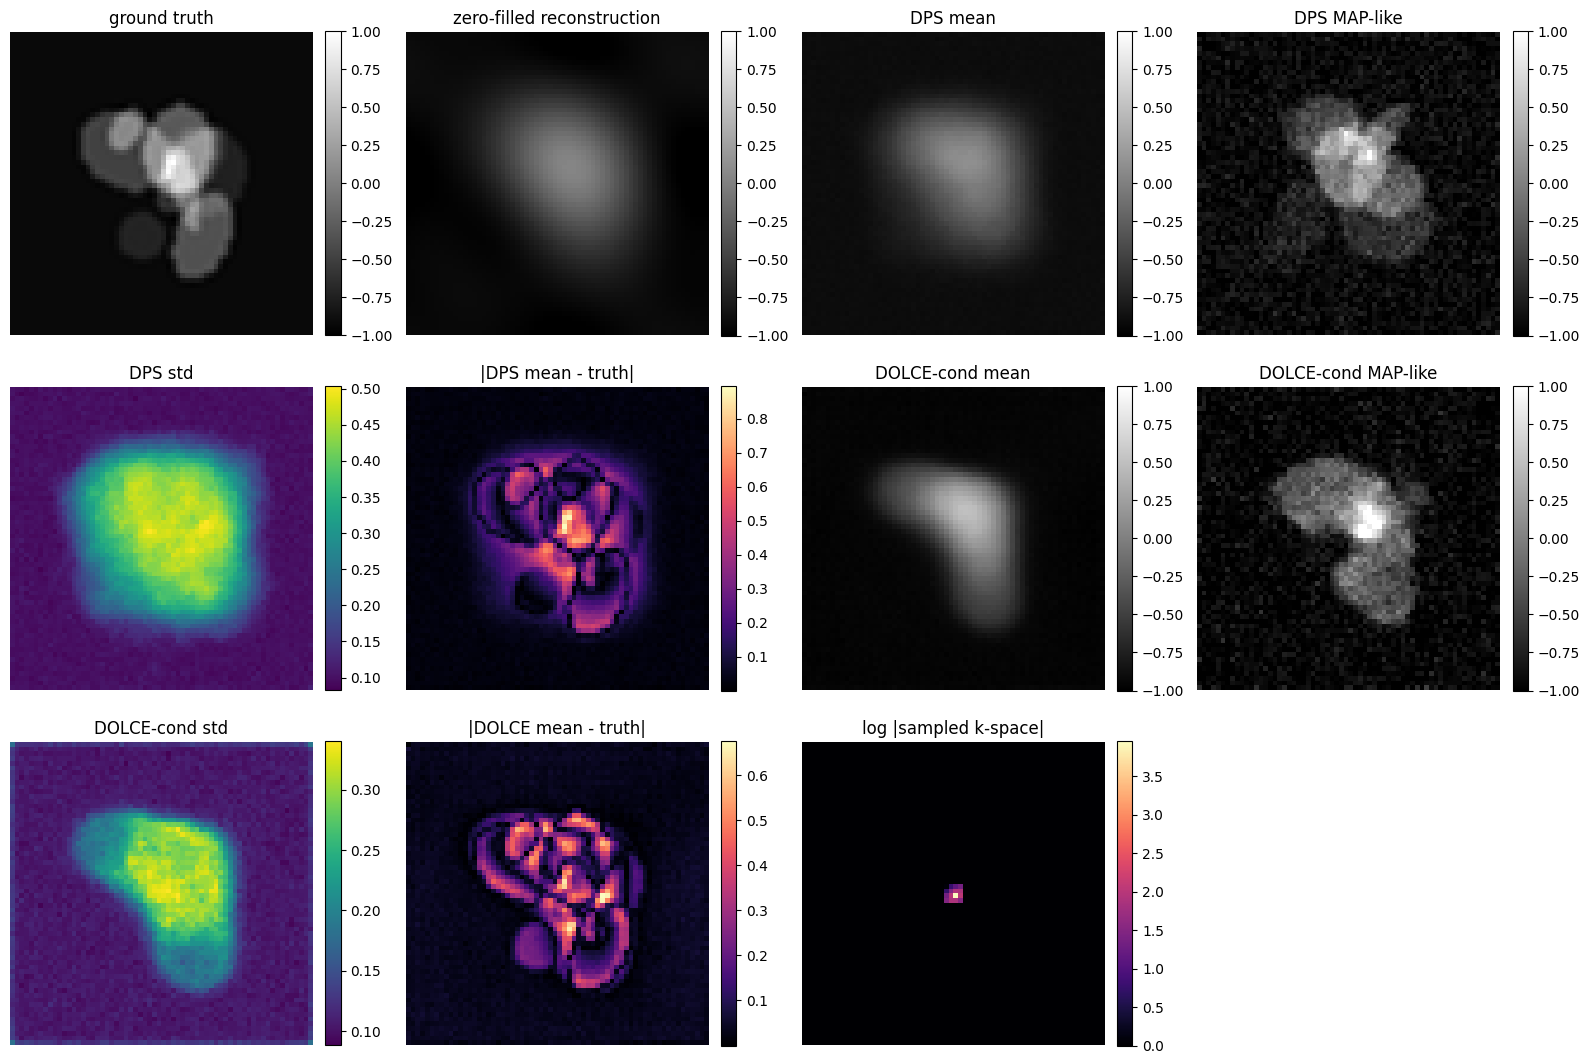

In [19]:

# ============================================================
# Visualization for DPS and DOLCE only
# ============================================================
with torch.no_grad():
    if OBS_MODE in PHASE_RETRIEVAL_OBS_MODES:
        obs_map = phase_retrieval_to_masked_map(y_obs)
        obs_display_img = torch.log1p(torch.clamp(obs_map, min=0.0))[None, None]
        obs_display_title = "log observed Fourier magnitude"
        obs_display_cmap = "magma"
        baseline_display_title = "zero-phase backprojection"
    elif OBS_MODE in MRI_OBS_MODES:
        obs_display_img = packed_to_masked_kspace(y_obs).abs()[None, None].log1p()
        obs_display_title = "log |sampled k-space|"
        obs_display_cmap = "magma"
        baseline_display_title = "zero-filled reconstruction"
    elif OBS_MODE in SPATIAL_PROJECTION_OBS_MODES:
        obs_display_img = zero_filled_reconstruction(y_obs)
        obs_display_title = "spatial projection observations"
        obs_display_cmap = "magma"
        baseline_display_title = "spatial observed-pixel fill"
    elif OBS_MODE in CT_OBS_MODES:
        ct_values_are_counts = LIKELIHOOD_TYPE in {"poisson_direct", "poisson_gaussian"}
        obs_display_img = ct_masked_sinogram_map_from_vector(y_obs, values_are_counts=ct_values_are_counts)[None, None]
        obs_display_title = "log observed CT counts" if ct_values_are_counts else "observed CT line integrals"
        obs_display_cmap = "magma"
        baseline_display_title = "CT backprojection seed"
    else:
        obs_display_img = zero_filled_reconstruction(y_obs)
        obs_display_title = "observed pixels display"
        obs_display_cmap = "magma"
        baseline_display_title = "observed-pixel fill"

if SHOW_PLOTS or SAVE_FIGURES:
    items = [(x_true, "ground truth", "gray"), (x_zf, baseline_display_title, "gray")]
    if globals().get("dps_samples", None) is not None:
        with torch.no_grad():
            dps_std = dps_samples.std(dim=0, keepdim=True)
            err_dps = torch.abs(dps_mean - x_true)
        items += [
            (dps_mean, "DPS mean", "gray"),
            (dps_map, "DPS MAP-like", "gray"),
            (dps_std, "DPS std", "viridis"),
            (err_dps, "|DPS mean - truth|", "magma"),
        ]
    if globals().get("dolce_samples", None) is not None:
        with torch.no_grad():
            dolce_std = dolce_samples.std(dim=0, keepdim=True)
            err_dolce = torch.abs(dolce_mean - x_true)
        items += [
            (dolce_mean, "DOLCE-cond mean", "gray"),
            (dolce_map, "DOLCE-cond MAP-like", "gray"),
            (dolce_std, "DOLCE-cond std", "viridis"),
            (err_dolce, "|DOLCE mean - truth|", "magma"),
        ]
    items += [(obs_display_img, obs_display_title, obs_display_cmap)]

    ncols = 4
    nrows = int(math.ceil(len(items) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.6 * nrows), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, (img, title, cmap) in zip(axes.ravel(), items):
        arr = img[0, 0].detach().cpu().numpy()
        im = ax.imshow(arr, cmap=cmap, vmin=(-1 if cmap == "gray" else None), vmax=(1 if cmap == "gray" else None))
        ax.set_title(title)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / "dps_dolce_reconstruction_summary.png", dpi=150, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)


NUM_MAP_PARTICLES: 5
MAP_DISTINCT_ATOL: 1e-07
REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_SAMPLE: True

Distinct MAP-like samples for DPS
displayed=5 | distinct_returned=5 | unique_available=256 | repeated_single_unique=False
rank  1 | particle    246 | reward=-124.062 | RMSE=0.201784 | PSNR=19.9229 | SSIM=0.384192 | obs_RMSE=0.556915 | repeat_single=False
rank  2 | particle      0 | reward=-132.488 | RMSE=0.246678 | PSNR=18.178 | SSIM=0.367974 | obs_RMSE=0.575516 | repeat_single=False
rank  3 | particle    241 | reward=-134.102 | RMSE=0.215583 | PSNR=19.3483 | SSIM=0.403219 | obs_RMSE=0.579013 | repeat_single=False
rank  4 | particle     25 | reward=-173.746 | RMSE=0.210504 | PSNR=19.5554 | SSIM=0.390194 | obs_RMSE=0.659065 | repeat_single=False
rank  5 | particle    237 | reward=-179.134 | RMSE=0.234317 | PSNR=18.6245 | SSIM=0.379193 | obs_RMSE=0.669204 | repeat_single=False

Distinct MAP-like samples for DOLCE-cond
displayed=5 | distinct_returned=5 | unique_available=256 | repeated_single_uniqu

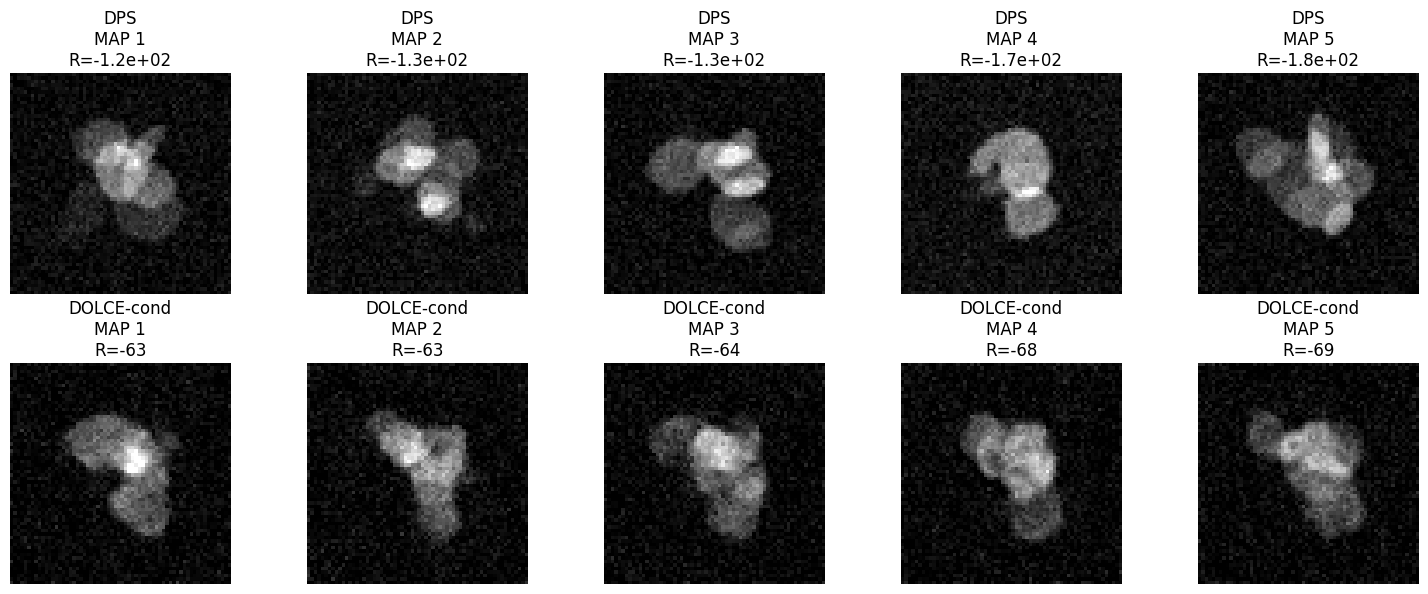

saved low-pass IFFT distinct top-k MAP grid to: singlecoil_mri_tuolumne_outputs/dps_top5_distinct_map_lowpass_ifft_4x4_8x8_16x16.png


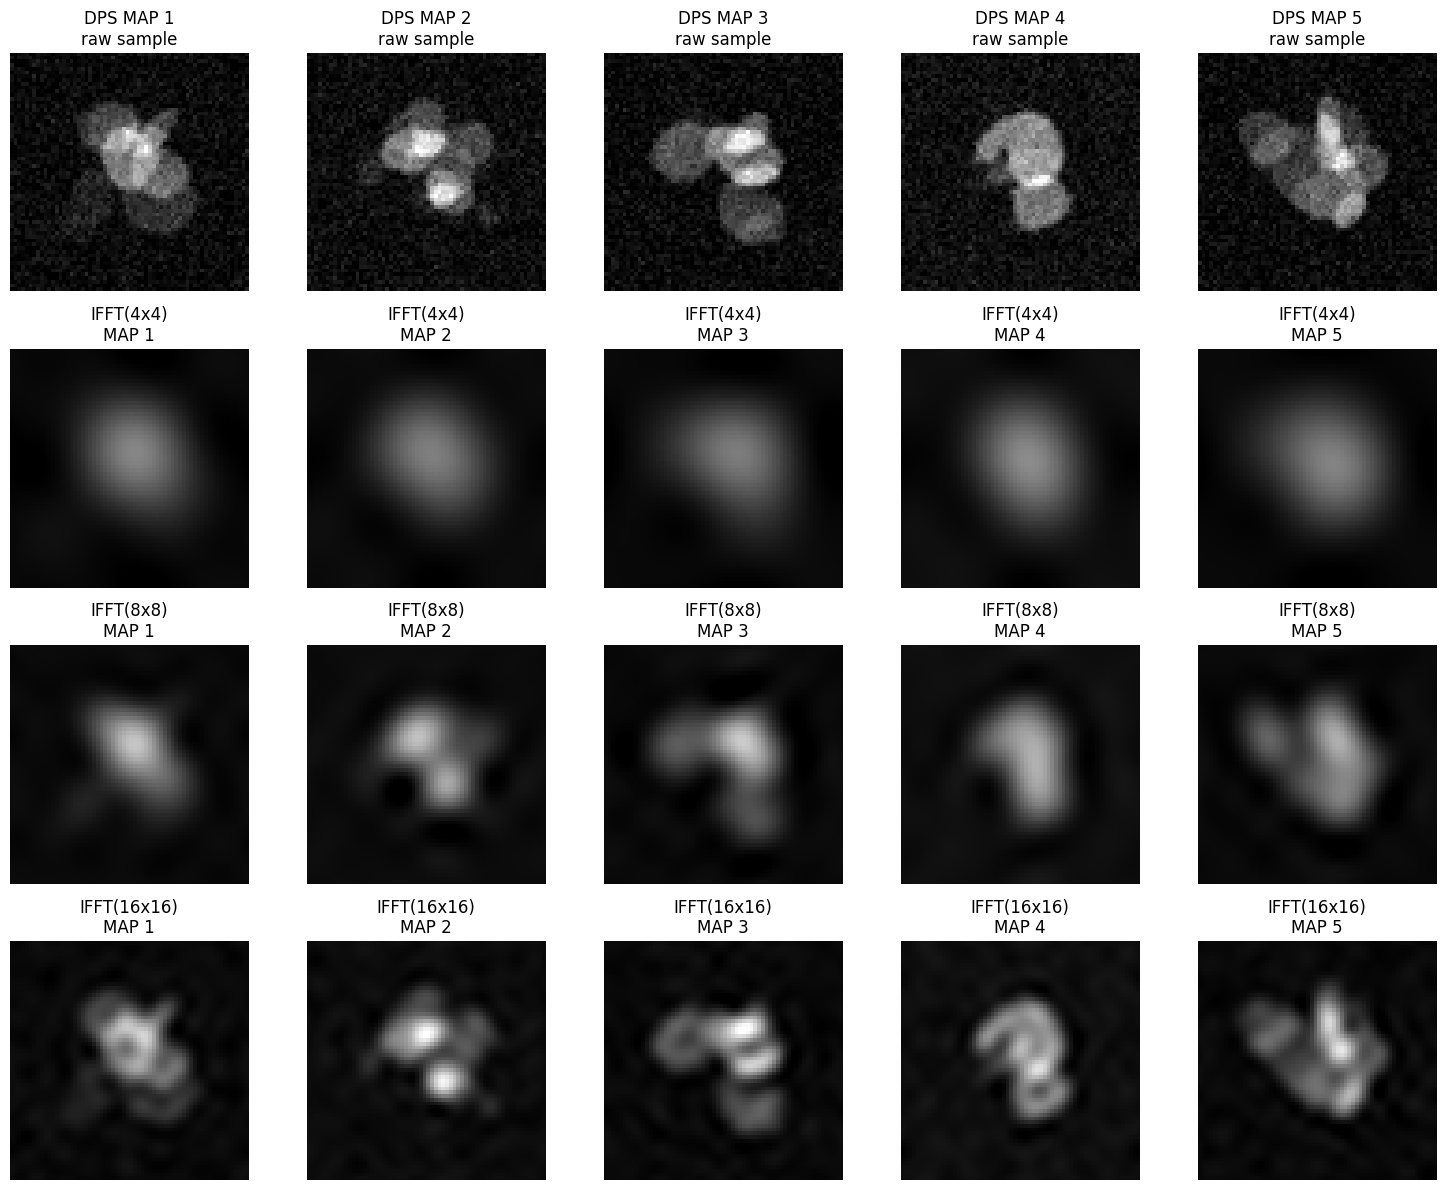

saved low-pass IFFT distinct top-k MAP grid to: singlecoil_mri_tuolumne_outputs/dolce_top5_distinct_map_lowpass_ifft_4x4_8x8_16x16.png


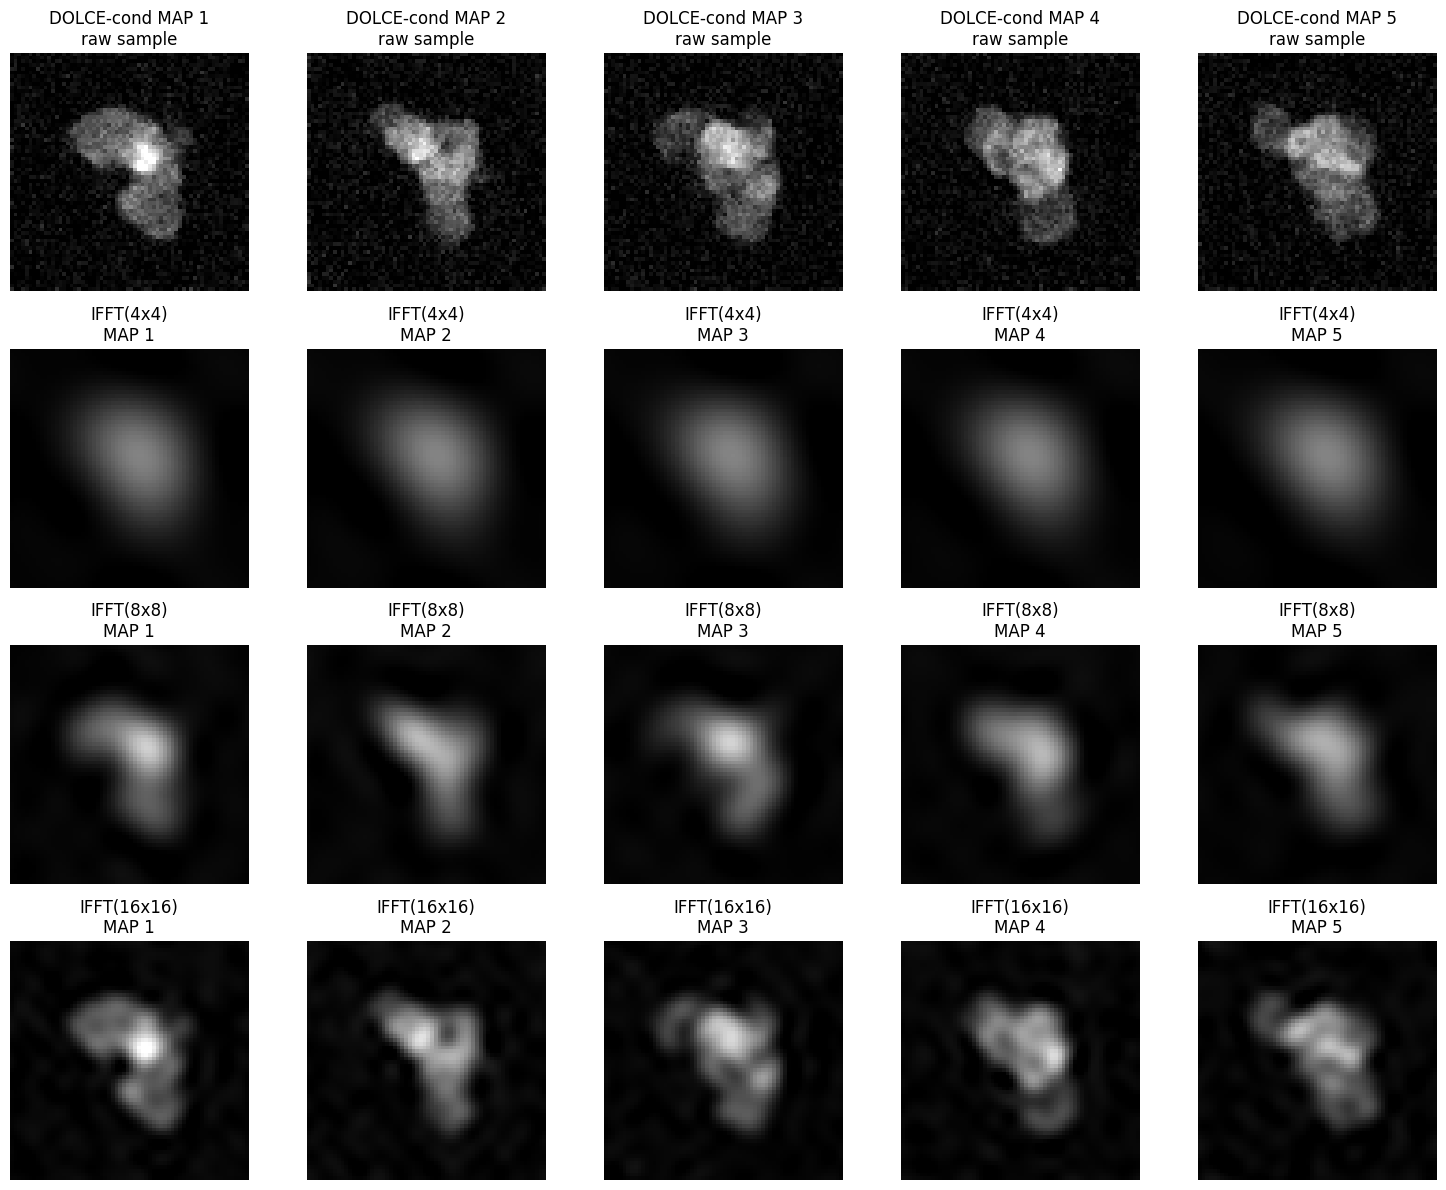

In [20]:
# ============================================================
# Distinct top-k MAP-like samples for baseline methods
# ============================================================
# This cell ranks each baseline sample cloud by the same log-likelihood reward
# used elsewhere in the notebook.  It selects distinct MAP-like samples by
# image/sample content.  It repeats the same sample up to NUM_MAP_PARTICLES
# only if the baseline sample cloud has exactly one unique sample.

import os
import numpy as np
import torch
import matplotlib.pyplot as plt

try:
    import pandas as pd
except Exception:
    pd = None

NUM_MAP_PARTICLES = env_int("NUM_MAP_PARTICLES", 5) if "env_int" in globals() else int(globals().get("NUM_MAP_PARTICLES", 5))
MAP_DISTINCT_ATOL = env_float("MAP_DISTINCT_ATOL", 1e-7) if "env_float" in globals() else float(globals().get("MAP_DISTINCT_ATOL", 1e-7))
REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_SAMPLE = (
    env_bool("REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_SAMPLE", True)
    if "env_bool" in globals()
    else bool(globals().get("REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_SAMPLE", True))
)

print("NUM_MAP_PARTICLES:", NUM_MAP_PARTICLES)
print("MAP_DISTINCT_ATOL:", MAP_DISTINCT_ATOL)
print("REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_SAMPLE:", REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_SAMPLE)


@torch.no_grad()
def _sample_content_key_baseline(x: torch.Tensor, atol: float = MAP_DISTINCT_ATOL):
    """Hash a sample tensor so identical/near-identical images are treated as duplicates."""
    arr = x.detach().cpu().reshape(-1).numpy()

    if atol is not None and float(atol) > 0:
        arr = np.round(arr / float(atol)).astype(np.int64)
    else:
        arr = arr.astype(np.float32)

    return arr.tobytes()


@torch.no_grad()
def _topk_map_particles_baseline(samples: torch.Tensor, num_map_particles: int = NUM_MAP_PARTICLES):
    """Return MAP-like particles sorted by reward, with duplicate samples removed.

    Rule:
        * If at least NUM_MAP_PARTICLES distinct samples exist, return the top NUM_MAP_PARTICLES.
        * If 2--(NUM_MAP_PARTICLES-1) distinct samples exist, return only those distinct samples.
        * If exactly one unique sample exists, repeat that sample NUM_MAP_PARTICLES times.

    For baseline methods there is no SMC ancestor array, so uniqueness is by
    sample/image content rather than ancestor id.
    """
    samples = samples.detach().to(DEVICE)
    n = int(samples.shape[0])
    if n <= 0:
        raise ValueError("Cannot choose MAP particles from an empty sample tensor.")

    rewards_raw = reward_mri_value_chunked(samples).detach()
    rewards = rewards_raw.reshape(n, -1).mean(dim=1)

    target_k = max(1, int(num_map_particles))
    order = torch.argsort(rewards, descending=True)

    seen_keys = set()
    unique_indices = []
    unique_keys = []

    # Scan all samples in descending-reward order.  This lets us distinguish
    # the single-unique-sample case from the 2--4 unique-sample case.
    for idx_t in order:
        idx = int(idx_t.detach().cpu())
        key = _sample_content_key_baseline(samples[idx], atol=MAP_DISTINCT_ATOL)
        if key in seen_keys:
            continue
        seen_keys.add(key)
        unique_indices.append(idx)
        unique_keys.append(key)

    num_unique_available = int(len(unique_indices))
    if num_unique_available <= 0:
        raise RuntimeError("No unique samples were found, although the input sample tensor was non-empty.")

    repeated_single_unique = False

    if num_unique_available == 1 and REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_SAMPLE:
        # The only case where duplicates are intentionally shown.
        chosen_indices = [int(unique_indices[0])] * target_k
        repeated_single_unique = True
    else:
        # Do not pad with duplicates when there are 2--4 unique samples.
        chosen_indices = unique_indices[:min(target_k, num_unique_available)]

    top_indices = torch.as_tensor(chosen_indices, dtype=torch.long, device=samples.device)
    top_rewards = rewards[top_indices]
    top_particles = samples[top_indices]

    meta = {
        "num_unique_available": num_unique_available,
        "num_distinct_returned": 1 if repeated_single_unique else int(len(chosen_indices)),
        "num_displayed": int(len(chosen_indices)),
        "repeated_single_unique": bool(repeated_single_unique),
        "uniqueness_mode": "sample_content",
    }

    return (
        top_particles.detach().cpu(),
        top_indices.detach().cpu(),
        top_rewards.detach().cpu(),
        meta,
    )


@torch.no_grad()
def _topk_metric_rows(
    method_name: str,
    top_particles_cpu: torch.Tensor,
    top_indices_cpu: torch.Tensor,
    top_rewards_cpu: torch.Tensor,
    top_meta: dict,
):
    rows = []
    for rank in range(int(top_particles_cpu.shape[0])):
        particle = top_particles_cpu[rank:rank + 1].to(DEVICE)
        reward_val = float(top_rewards_cpu[rank])
        obs_rmse_val = float(
            torch.sqrt(torch.mean((observation_mean_torch(particle) - y_obs[None, :]) ** 2))
            .detach()
            .cpu()
        )
        rows.append({
            "method": method_name,
            "map_rank": rank + 1,
            "particle_index": int(top_indices_cpu[rank]),
            "reward": reward_val,
            "reward_per_obs": reward_val / float(max(int(OBS_DIM), 1)),
            "RMSE": rmse(particle, x_true),
            "MAE": mae(particle, x_true),
            "PSNR": psnr(particle, x_true),
            "SSIM": ssim_torch_simple(particle, x_true),
            "obs_RMSE": obs_rmse_val,
            "num_unique_available": int(top_meta["num_unique_available"]),
            "num_distinct_returned": int(top_meta["num_distinct_returned"]),
            "num_displayed": int(top_meta["num_displayed"]),
            "repeated_single_unique": bool(top_meta["repeated_single_unique"]),
            "uniqueness_mode": str(top_meta["uniqueness_mode"]),
        })
    return rows


baseline_sample_sources = []
if globals().get("dps_samples", None) is not None:
    baseline_sample_sources.append(("DPS", "dps", dps_samples))
if globals().get("dolce_samples", None) is not None:
    baseline_sample_sources.append(("DOLCE-cond", "dolce", dolce_samples))

baseline_top_map_rows = []
baseline_top_map_payload = {}

if len(baseline_sample_sources) == 0:
    print("No DPS/DOLCE baseline sample clouds found; distinct top-k MAP display skipped.")
else:
    for method_name, prefix, samples in baseline_sample_sources:
        top_particles_cpu, top_indices_cpu, top_rewards_cpu, top_meta = _topk_map_particles_baseline(
            samples,
            num_map_particles=NUM_MAP_PARTICLES,
        )

        globals()[f"{prefix}_top_map_particles"] = top_particles_cpu
        globals()[f"{prefix}_top_map_indices"] = top_indices_cpu
        globals()[f"{prefix}_top_map_rewards"] = top_rewards_cpu
        globals()[f"{prefix}_top_map_meta"] = top_meta

        baseline_top_map_payload[prefix] = {
            "particles": top_particles_cpu,
            "indices": top_indices_cpu,
            "rewards": top_rewards_cpu,
            "meta": top_meta,
        }

        # Keep old top-1 variables synchronized for downstream metrics/saving.
        if prefix == "dps":
            dps_map = top_particles_cpu[0:1].to(DEVICE)
        elif prefix == "dolce":
            dolce_map = top_particles_cpu[0:1].to(DEVICE)

        rows = _topk_metric_rows(method_name, top_particles_cpu, top_indices_cpu, top_rewards_cpu, top_meta)
        baseline_top_map_rows.extend(rows)

        print("\n" + "=" * 80)
        print(f"Distinct MAP-like samples for {method_name}")
        print("=" * 80)
        print(
            f"displayed={top_meta['num_displayed']} | "
            f"distinct_returned={top_meta['num_distinct_returned']} | "
            f"unique_available={top_meta['num_unique_available']} | "
            f"repeated_single_unique={top_meta['repeated_single_unique']}"
        )
        for row in rows:
            print(
                f"rank {row['map_rank']:2d} | "
                f"particle {row['particle_index']:6d} | "
                f"reward={row['reward']:.6g} | "
                f"RMSE={row['RMSE']:.6g} | "
                f"PSNR={row['PSNR']:.6g} | "
                f"SSIM={row['SSIM']:.6g} | "
                f"obs_RMSE={row['obs_RMSE']:.6g} | "
                f"repeat_single={row['repeated_single_unique']}"
            )

    if pd is not None:
        baseline_top_map_df = pd.DataFrame(baseline_top_map_rows)
        try:
            from IPython.display import display
            display(baseline_top_map_df)
        except Exception:
            print(baseline_top_map_df.to_string(index=False))

        if "OUTPUT_DIR" in globals():
            os.makedirs(OUTPUT_DIR, exist_ok=True)
            csv_path = OUTPUT_DIR / f"baseline_top{NUM_MAP_PARTICLES}_distinct_map_particles.csv"
            baseline_top_map_df.to_csv(csv_path, index=False)
            print("saved distinct top-k MAP table to:", csv_path)
    else:
        baseline_top_map_df = None

    if "OUTPUT_DIR" in globals():
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        pt_path = OUTPUT_DIR / f"baseline_top{NUM_MAP_PARTICLES}_distinct_map_particles.pt"
        torch.save(
            {
                "num_map_particles": int(NUM_MAP_PARTICLES),
                "map_distinct_atol": float(MAP_DISTINCT_ATOL),
                "repeat_top_map_if_single_unique_sample": bool(REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_SAMPLE),
                "rows": baseline_top_map_rows,
                "payload": baseline_top_map_payload,
            },
            pt_path,
        )
        print("saved distinct top-k MAP tensor payload to:", pt_path)

        try:
            npz_payload = {"rows": np.array(baseline_top_map_rows, dtype=object)}
            for prefix, data in baseline_top_map_payload.items():
                npz_payload[f"{prefix}_top_map_particles"] = data["particles"].numpy()
                npz_payload[f"{prefix}_top_map_indices"] = data["indices"].numpy()
                npz_payload[f"{prefix}_top_map_rewards"] = data["rewards"].numpy()
                npz_payload[f"{prefix}_top_map_meta"] = np.array([data["meta"]], dtype=object)
            npz_path = OUTPUT_DIR / f"baseline_top{NUM_MAP_PARTICLES}_distinct_map_particles.npz"
            np.savez_compressed(npz_path, **npz_payload)
            print("saved distinct top-k MAP NumPy archive to:", npz_path)
        except Exception as e:
            print("WARNING: could not save distinct top-k MAP npz:", repr(e))

    # Raw distinct top-k MAP image grid.
    if SHOW_PLOTS or SAVE_FIGURES:
        n_methods = len(baseline_sample_sources)
        ncols = int(NUM_MAP_PARTICLES)
        fig, axes = plt.subplots(
            n_methods,
            ncols,
            figsize=(3.0 * ncols, 3.0 * n_methods),
            squeeze=False,
        )

        for row_idx, (method_name, prefix, _) in enumerate(baseline_sample_sources):
            top_particles = baseline_top_map_payload[prefix]["particles"]
            top_rewards = baseline_top_map_payload[prefix]["rewards"]
            k_method = int(top_particles.shape[0])
            for rank in range(ncols):
                ax = axes[row_idx, rank]
                if rank < k_method:
                    arr = top_particles[rank, 0].detach().cpu().numpy()
                    ax.imshow(arr, cmap="gray", vmin=-1, vmax=1)
                    ax.set_title(f"{method_name}\nMAP {rank + 1}\nR={float(top_rewards[rank]):.2g}")
                else:
                    ax.text(
                        0.5,
                        0.5,
                        "no distinct\nsample",
                        ha="center",
                        va="center",
                        transform=ax.transAxes,
                    )
                    ax.set_title(f"{method_name}\nMAP {rank + 1}")
                ax.axis("off")

        plt.tight_layout()
        if SAVE_FIGURES:
            fig_path = OUTPUT_DIR / f"baseline_top{NUM_MAP_PARTICLES}_distinct_map_particles_grid.png"
            fig.savefig(fig_path, dpi=180, bbox_inches="tight")
            print("saved distinct top-k MAP image grid to:", fig_path)
        if SHOW_PLOTS:
            plt.show()
        else:
            plt.close(fig)

    # Low-pass IFFT views of the distinct top-k MAP samples for MRI FFT experiments.
    if OBS_MODE in MRI_OBS_MODES and (SHOW_PLOTS or SAVE_FIGURES):
        preview_sizes = [int(s) for s in LOWPASS_SQUARE_SIZES]
        for method_name, prefix, _ in baseline_sample_sources:
            top_particles_cpu = baseline_top_map_payload[prefix]["particles"]
            top_particles_dev = top_particles_cpu.to(DEVICE)
            k_method = int(top_particles_cpu.shape[0])
            n_rows = 1 + len(preview_sizes)
            ncols = int(NUM_MAP_PARTICLES)
            fig, axes = plt.subplots(
                n_rows,
                ncols,
                figsize=(3.0 * ncols, 3.0 * n_rows),
                squeeze=False,
            )

            for rank in range(ncols):
                if rank < k_method:
                    axes[0, rank].imshow(
                        top_particles_cpu[rank, 0].detach().cpu().numpy(),
                        cmap="gray",
                        vmin=-1,
                        vmax=1,
                    )
                    axes[0, rank].set_title(f"{method_name} MAP {rank + 1}\nraw sample")
                else:
                    axes[0, rank].text(
                        0.5,
                        0.5,
                        "no distinct\nsample",
                        ha="center",
                        va="center",
                        transform=axes[0, rank].transAxes,
                    )
                    axes[0, rank].set_title(f"{method_name} MAP {rank + 1}")
                axes[0, rank].axis("off")

            if k_method > 0:
                for row_idx, s in enumerate(preview_sizes, start=1):
                    with torch.no_grad():
                        low_imgs = lowpass_ifft_reconstruction_from_image(top_particles_dev, s).detach().cpu()
                    for rank in range(ncols):
                        if rank < k_method:
                            axes[row_idx, rank].imshow(low_imgs[rank, 0].numpy(), cmap="gray", vmin=-1, vmax=1)
                            axes[row_idx, rank].set_title(f"IFFT({s}x{s})\nMAP {rank + 1}")
                        else:
                            axes[row_idx, rank].text(
                                0.5,
                                0.5,
                                "no distinct\nsample",
                                ha="center",
                                va="center",
                                transform=axes[row_idx, rank].transAxes,
                            )
                            axes[row_idx, rank].set_title(f"IFFT({s}x{s})\nMAP {rank + 1}")
                        axes[row_idx, rank].axis("off")

            plt.tight_layout()
            if SAVE_FIGURES:
                safe_name = prefix.replace("-", "_")
                fig_path = OUTPUT_DIR / f"{safe_name}_top{NUM_MAP_PARTICLES}_distinct_map_lowpass_ifft_4x4_8x8_16x16.png"
                fig.savefig(fig_path, dpi=180, bbox_inches="tight")
                print("saved low-pass IFFT distinct top-k MAP grid to:", fig_path)
            if SHOW_PLOTS:
                plt.show()
            else:
                plt.close(fig)


## 14. Saving results

mask observed fraction: 0.00390625
fraction of Fourier energy captured by mask: 0.9582303166389465
selected Fourier locations: 16 / 4096


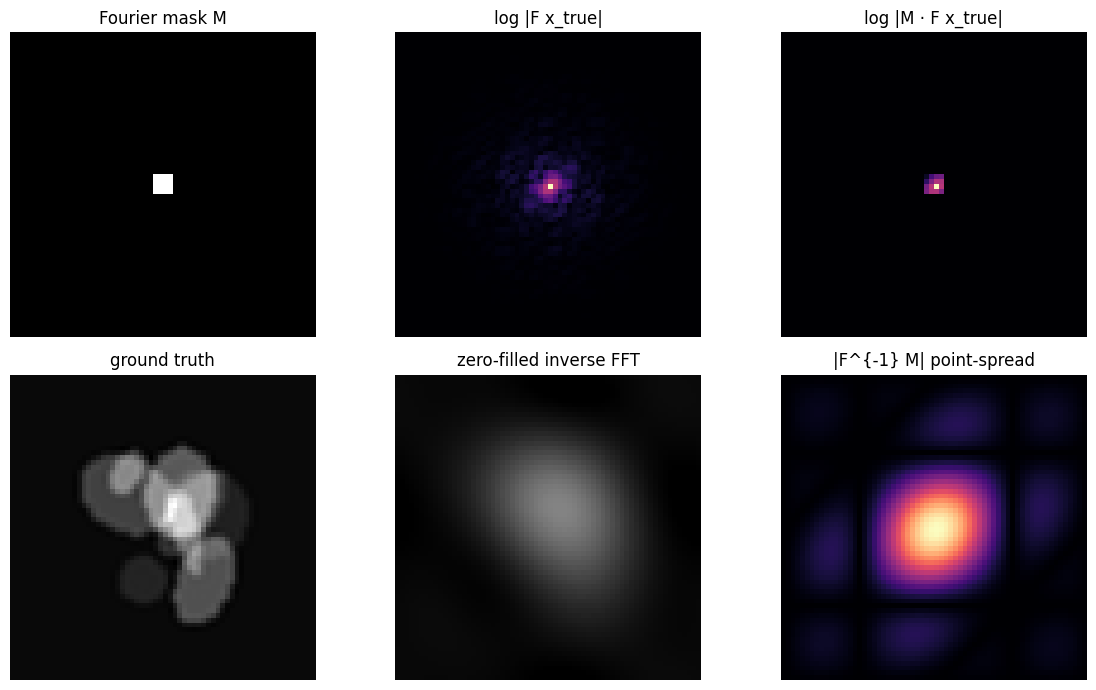

In [21]:
# ============================================================
# Diagnose why FFT zero-filled can be strong
# ============================================================

import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def ifft2c_img_debug(k: torch.Tensor) -> torch.Tensor:
    """
    Centered orthonormal inverse 2D FFT.

    Input:
        k: (B,H,W), complex, centered/fftshifted

    Output:
        x: (B,1,H,W), real
    """
    x = torch.fft.ifftshift(k, dim=(-2, -1))
    x = torch.fft.ifft2(x, norm="ortho")
    x = torch.fft.fftshift(x, dim=(-2, -1))
    return x.real[:, None]


@torch.no_grad()
def inspect_fft_mask_effect(x_true, mask):
    """
    Show:
      1. Fourier mask
      2. true k-space magnitude
      3. masked k-space magnitude
      4. ground truth image
      5. zero-filled inverse FFT image
      6. point-spread function |F^{-1}M|
    """
    mask = mask.bool()
    H, W = mask.shape

    k_true = fft2c_img(x_true)  # (B,H,W), complex centered k-space

    k_masked = torch.zeros_like(k_true)
    k_masked[:, mask] = k_true[:, mask]

    x_zf_clean = ifft2c_img_debug(k_masked)

    # Point-spread function: inverse FFT of the mask.
    mask_complex = mask.float()[None].to(k_true.device).to(torch.complex64)
    psf = ifft2c_img_debug(mask_complex)[0, 0]
    psf_abs = torch.abs(psf)

    total_energy = torch.sum(torch.abs(k_true) ** 2)
    observed_energy = torch.sum(torch.abs(k_true[:, mask]) ** 2)
    observed_fraction = float(mask.float().mean().detach().cpu())
    energy_fraction = float((observed_energy / total_energy).detach().cpu())

    print("mask observed fraction:", observed_fraction)
    print("fraction of Fourier energy captured by mask:", energy_fraction)
    print("selected Fourier locations:", int(mask.sum().item()), "/", H * W)

    fig, axes = plt.subplots(2, 3, figsize=(12, 7))

    axes[0, 0].imshow(mask.detach().cpu(), cmap="gray")
    axes[0, 0].set_title("Fourier mask M")

    axes[0, 1].imshow(torch.log1p(torch.abs(k_true[0])).detach().cpu(), cmap="magma")
    axes[0, 1].set_title("log |F x_true|")

    axes[0, 2].imshow(torch.log1p(torch.abs(k_masked[0])).detach().cpu(), cmap="magma")
    axes[0, 2].set_title("log |M · F x_true|")

    axes[1, 0].imshow(x_true[0, 0].detach().cpu(), cmap="gray", vmin=-1, vmax=1)
    axes[1, 0].set_title("ground truth")

    axes[1, 1].imshow(x_zf_clean[0, 0].detach().cpu(), cmap="gray", vmin=-1, vmax=1)
    axes[1, 1].set_title("zero-filled inverse FFT")

    axes[1, 2].imshow(psf_abs.detach().cpu(), cmap="magma")
    axes[1, 2].set_title("|F^{-1} M| point-spread")

    for ax in axes.ravel():
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return x_zf_clean, psf_abs


if OBS_MODE in MRI_OBS_MODES or OBS_MODE in PHASE_RETRIEVAL_OBS_MODES:
    x_zf_clean_debug, psf_abs_debug = inspect_fft_mask_effect(x_true, OBS_MASK)
else:
    print(f"Skipping Fourier-mask energy diagnostic for OBS_MODE={OBS_MODE}; active mask is not a Fourier/k-space mask.")


In [22]:

# ============================================================
# Save DPS/DOLCE-only results
# ============================================================
result_path = OUTPUT_DIR / f"dps_dolce_only_{OBS_MODE}_{LIKELIHOOD_TYPE}_img{IMG_SIZE}_delta{DELTA_OBS:g}.npz"

save_payload = {
    "x_true": x_true.detach().cpu().numpy(),
    "x_zf": x_zf.detach().cpu().numpy(),
    "y_clean": y_clean.detach().cpu().numpy(),
    "y_obs": y_obs.detach().cpu().numpy(),
    "mask": OBS_MASK.detach().cpu().numpy() if "OBS_MASK" in globals() and OBS_MASK is not None else np.array([]),
    "metrics": np.array([str(metric_summary)], dtype=object),
    "score_training_steps": np.asarray(score_training_steps),
    "score_training_losses": np.asarray(score_training_losses, dtype=np.float32),
    "score_validation_time_grid": np.asarray(score_validation_time_grid) if "score_validation_time_grid" in globals() else np.array([]),
    "score_validation_time_loss": np.asarray(score_validation_time_loss) if "score_validation_time_loss" in globals() else np.array([]),
}

if globals().get("prior_terminal", None) is not None:
    save_payload.update({
        "prior_samples": prior_terminal.detach().cpu().numpy(),
        "prior_mean": prior_mean.detach().cpu().numpy(),
    })

if globals().get("dps_samples", None) is not None:
    save_payload.update({
        "dps_samples": dps_samples.detach().cpu().numpy(),
        "dps_mean": dps_mean.detach().cpu().numpy(),
        "dps_map": dps_map.detach().cpu().numpy(),
        "dps_top_map_particles": globals().get("dps_top_map_particles", torch.empty(0)).detach().cpu().numpy() if torch.is_tensor(globals().get("dps_top_map_particles", None)) else np.array([]),
        "dps_top_map_indices": globals().get("dps_top_map_indices", torch.empty(0, dtype=torch.long)).detach().cpu().numpy() if torch.is_tensor(globals().get("dps_top_map_indices", None)) else np.array([]),
        "dps_top_map_rewards": globals().get("dps_top_map_rewards", torch.empty(0)).detach().cpu().numpy() if torch.is_tensor(globals().get("dps_top_map_rewards", None)) else np.array([]),
        "dps_loss_trace": dps_out["loss_trace"],
        "dps_grad_norm_trace": dps_out["grad_norm_trace"],
        "dps_mean_reward_trace": dps_out["mean_reward_trace"],
        "dps_mean_reward_per_obs_trace": dps_out["mean_reward_per_obs_trace"],
        "dps_x0_norm_trace": dps_out["x0_norm_trace"],
    })

if globals().get("dolce_samples", None) is not None:
    save_payload.update({
        "dolce_samples": dolce_samples.detach().cpu().numpy(),
        "dolce_mean": dolce_mean.detach().cpu().numpy(),
        "dolce_map": dolce_map.detach().cpu().numpy(),
        "dolce_top_map_particles": globals().get("dolce_top_map_particles", torch.empty(0)).detach().cpu().numpy() if torch.is_tensor(globals().get("dolce_top_map_particles", None)) else np.array([]),
        "dolce_top_map_indices": globals().get("dolce_top_map_indices", torch.empty(0, dtype=torch.long)).detach().cpu().numpy() if torch.is_tensor(globals().get("dolce_top_map_indices", None)) else np.array([]),
        "dolce_top_map_rewards": globals().get("dolce_top_map_rewards", torch.empty(0)).detach().cpu().numpy() if torch.is_tensor(globals().get("dolce_top_map_rewards", None)) else np.array([]),
        "dolce_training_steps": np.asarray(dolce_training_steps),
        "dolce_training_losses": np.asarray(dolce_training_losses, dtype=np.float32),
        "dolce_data_loss_trace": dolce_out["data_loss_trace"] if dolce_out is not None else np.array([]),
        "dolce_reward_per_obs_trace": dolce_out["reward_per_obs_trace"] if dolce_out is not None else np.array([]),
        "dolce_obs_rmse_trace": dolce_out["obs_rmse_trace"] if dolce_out is not None else np.array([]),
    })

save_payload["config"] = np.array([{
    "STANDALONE_BASELINES_ONLY": True,
    "IMG_SIZE": IMG_SIZE,
    "DATASET_CLASS": type(train_ds).__name__,
    "OBS_MODE": OBS_MODE,
    "LIKELIHOOD_TYPE": LIKELIHOOD_TYPE,
    "OBS_DIM": OBS_DIM,
    "MASK_TYPE": globals().get("MASK_TYPE", None),
    "PHASE_RETRIEVAL_MASK_TYPE": globals().get("PHASE_RETRIEVAL_MASK_TYPE", None),
    "BLOCK_MASK_BLOCK_SIZE": globals().get("BLOCK_MASK_BLOCK_SIZE", None),
    "BLOCK_MASK_NUM_BLOCKS": globals().get("BLOCK_MASK_NUM_BLOCKS", None),
    "BLOCK_MASK_GAP": globals().get("BLOCK_MASK_GAP", None),
    "LOWPASS_SQUARE_SIZE": globals().get("LOWPASS_SQUARE_SIZE", None),
    "LOWPASS_SQUARE_SIZES": globals().get("LOWPASS_SQUARE_SIZES", None),
    "NUM_MAP_PARTICLES": globals().get("NUM_MAP_PARTICLES", None),
    "SPATIAL_MASK_TYPE": globals().get("SPATIAL_MASK_TYPE", None),
    "SPATIAL_KEEP_FRACTION": globals().get("SPATIAL_KEEP_FRACTION", None),
    "SPATIAL_MASK_SEED": globals().get("SPATIAL_MASK_SEED", None),
    "SPATIAL_BLOCK_SIZE": globals().get("SPATIAL_BLOCK_SIZE", None),
    "SPATIAL_NUM_BLOCKS": globals().get("SPATIAL_NUM_BLOCKS", None),
    "SPATIAL_BLOCK_GAP": globals().get("SPATIAL_BLOCK_GAP", None),
    "DELTA_OBS": DELTA_OBS,
    "ADD_OBS_NOISE": ADD_OBS_NOISE,
    "NORMALIZE_LIKELIHOOD_BY_OBS_DIM": NORMALIZE_LIKELIHOOD_BY_OBS_DIM,
    "CHECKPOINT_PATH": str(CHECKPOINT_PATH),
    "TRAINING_LOSS_SOURCE": score_training_loss_source,
    "RUN_DPS": RUN_DPS,
    "DPS_NUM_SAMPLES": DPS_NUM_SAMPLES,
    "DPS_N_STEPS": DPS_N_STEPS,
    "DPS_OBJECTIVE": DPS_OBJECTIVE,
    "DPS_GUIDANCE_SCALE": DPS_GUIDANCE_SCALE,
    "DPS_CHUNK_SIZE": DPS_CHUNK_SIZE,
    "RUN_DOLCE_BASELINE": globals().get("RUN_DOLCE_BASELINE", False),
    "DOLCE_NUM_TRAIN_STEPS": globals().get("DOLCE_NUM_TRAIN_STEPS", None),
    "DOLCE_TRAIN_BATCH_SIZE": globals().get("DOLCE_TRAIN_BATCH_SIZE", None),
    "DOLCE_TRAINING_LOSS_SOURCE": globals().get("dolce_training_loss_source", None),
    "DOLCE_NUM_SAMPLES": globals().get("DOLCE_NUM_SAMPLES", None),
    "DOLCE_N_STEPS": globals().get("DOLCE_N_STEPS", None),
    "DOLCE_CONDITION_MODE": globals().get("DOLCE_CONDITION_MODE", None),
    "DOLCE_COND_CHANNELS": globals().get("DOLCE_COND_CHANNELS", None),
    "DOLCE_CHECKPOINT_PATH": str(globals().get("DOLCE_CHECKPOINT_PATH", "")),
    "CT_NUM_ANGLES": globals().get("CT_NUM_ANGLES", None),
    "CT_NUM_DETECTORS": globals().get("CT_NUM_DETECTORS", None),
    "CT_ANGLE_MAX_DEGREES": globals().get("CT_ANGLE_MAX_DEGREES", None),
    "CT_MASK_TYPE": globals().get("CT_MASK_TYPE", None),
    "CT_MASK_FRACTION": globals().get("CT_MASK_FRACTION", None),
    "CT_ANGULAR_COVERAGE_DEGREES": globals().get("CT_ANGULAR_COVERAGE_DEGREES", None),
    "CT_N0_PHOTONS": globals().get("CT_N0_PHOTONS", None),
    "DEVICE": str(DEVICE),
    "HIP_VERSION": getattr(torch.version, "hip", None),
}], dtype=object)

np.savez_compressed(result_path, **save_payload)
print("saved:", result_path.resolve())


saved: /p/lustre5/wang161/smc_swissroll_tuolumne/singlecoil_mri_tuolumne_outputs/dps_dolce_only_mri_fft_gaussian_img64_delta0.2.npz


## Notes for Tuolumne / AMD runs

This is the **baselines-only spatial-projection** notebook. It does not run SMC or load SMC tail statistics. It loads the trained unconditional prior checkpoint from the prior-training address you provided, then runs the baseline paths such as DPS and DOLCE.

Default prior checkpoint:

```bash
/p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_outputs/score_prior_singlecoil_mri_64_trained.pt
```

Useful explicit launch variables:

```bash
export OBS_MODE=spatial_projection
export LIKELIHOOD_TYPE=gaussian
export CHECKPOINT_PATH=/p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_outputs/score_prior_singlecoil_mri_64_trained.pt
export LOAD_CHECKPOINT_IF_EXISTS=1
export REQUIRE_PRETRAINED_PRIOR=1
export NUM_TRAIN_STEPS=0
export RUN_SMC=0
export RUN_DPS=1
```

For DOLCE-only staging, use the existing controls:

```bash
export DOLCE_TRAIN_ONLY=1          # train/save DOLCE conditional model only
# or
export DOLCE_SAMPLE_ONLY=1         # load DOLCE checkpoint and sample/evaluate
```

To use a spatial block mask:

```bash
export SPATIAL_MASK_TYPE=block
export SPATIAL_BLOCK_SIZE=4
export SPATIAL_NUM_BLOCKS=8
export SPATIAL_BLOCK_GAP=4
```


## Added low-pass square MRI FFT mask and distinct top-5 MAP baseline diagnostics

For the MRI FFT low-pass square mask, use for example:

```bash
export OBS_MODE=mri_fft
export LIKELIHOOD_TYPE=gaussian
export MASK_TYPE=lowpass_square
export LOWPASS_SQUARE_SIZE=4      # or 8, or 16
export LOWPASS_SQUARE_SIZES=4,8,16
export NUM_MAP_PARTICLES=5
```

The mask convention is unchanged: `True` means observed. The FFT helper uses centered k-space, so the low-pass square is centered at the DC Fourier coordinate `(ky,kx)=(0,0)`, displayed at the center of the array after `fftshift`.

The baseline MAP diagnostic now selects MAP-like samples ranked by `reward_mri_value_chunked(samples)` while enforcing sample-content distinctness:

```text
>=5 distinct samples available -> display 5 distinct MAP-like samples
2--4 distinct samples available -> display only those distinct samples, with no duplicate padding
1 unique sample available       -> repeat that one best sample five times
```

Uniqueness is controlled by:

```bash
export MAP_DISTINCT_ATOL=1e-7
export REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_SAMPLE=1
```

The notebook saves/displays:

```text
mri_lowpass_ifft_previews_4x4_8x8_16x16.png
baseline_top5_distinct_map_particles.csv
baseline_top5_distinct_map_particles.pt
baseline_top5_distinct_map_particles.npz
baseline_top5_distinct_map_particles_grid.png
dps_top5_distinct_map_lowpass_ifft_4x4_8x8_16x16.png
dolce_top5_distinct_map_lowpass_ifft_4x4_8x8_16x16.png
```

The existing rank-1 `dps_map` / `dolce_map` variables remain compatible, while `dps_top_map_particles` and `dolce_top_map_particles` store the distinct displayed samples.
